In [1]:
from pathlib import Path
from datetime import date
import numpy as np
import pandas as pd
import rasterio
from tqdm.auto import tqdm

ROOT = Path("data/makeathon-challenge")
EPOCH_RADD = date(2014, 12, 31)
EPOCH_RADD_ORD = EPOCH_RADD.toordinal()
TODAY_ORD = date.today().toordinal()

def audit_radd_tile(path):
    """Audit a single RADD tile for encoding validity and distribution anomalies."""
    with rasterio.open(path) as r:
        raw = r.read(1)
        nodata = r.nodata
        dtype = r.dtypes[0]
        shape = r.shape
    
    total_pixels = raw.size
    
    # --- Nonzero pixels = alerts ---
    nonzero = raw > 0
    n_alerts = int(nonzero.sum())
    
    if n_alerts == 0:
        return {
            "path": path.name, "tile": path.stem.replace("radd_", "").replace("_labels", ""),
            "total_pixels": total_pixels, "n_alerts": 0,
            "status": "empty", "shape": str(shape), "dtype": str(dtype),
        }
    
    # --- Decode ---
    raw_positive = raw[nonzero]
    leading = raw_positive // 10000
    days = raw_positive % 10000
    
    # --- Check 1: Invalid leading digits ---
    valid_leading = np.isin(leading, [2, 3])
    n_invalid_leading = int((~valid_leading).sum())
    unexpected_leading_values = np.unique(leading[~valid_leading]).tolist() if n_invalid_leading else []
    
    # --- Check 2: Days range ---
    # Earliest plausible: RADD launched ~2019. A value of 1500 days ≈ Feb 2019.
    # Latest plausible: today.
    max_plausible_days = TODAY_ORD - EPOCH_RADD_ORD
    n_future_dates = int((days > max_plausible_days).sum())
    n_pre_radd = int((days < 1460).sum())   # before 2019 — RADD didn't exist yet
    
    # Date distribution
    dates_ord = days + EPOCH_RADD_ORD
    date_min = date.fromordinal(int(dates_ord.min())) if n_alerts else None
    date_max = date.fromordinal(int(dates_ord.max())) if n_alerts else None
    
    # --- Check 3: Confidence distribution ---
    n_low  = int((leading == 2).sum())
    n_high = int((leading == 3).sum())
    high_frac = n_high / max(n_alerts, 1)
    
    # --- Check 4: Statistical outliers — concentrated spatial clustering ---
    # Rough: compute fraction of alerts by row vs column — uniform distribution expected
    row_alert_counts = nonzero.sum(axis=1)
    col_alert_counts = nonzero.sum(axis=0)
    # High std/mean ratio = concentrated; that's fine for real clearings but extreme = artifact
    row_cv = row_alert_counts.std() / (row_alert_counts.mean() + 1e-9)
    col_cv = col_alert_counts.std() / (col_alert_counts.mean() + 1e-9)
    
    # --- Check 5: Very high alert density ---
    alert_frac = n_alerts / total_pixels
    
    return {
        "path": path.name,
        "tile": path.stem.replace("radd_", "").replace("_labels", ""),
        "shape": str(shape),
        "dtype": str(dtype),
        "total_pixels": total_pixels,
        "n_alerts": n_alerts,
        "alert_frac": round(alert_frac, 5),
        "n_low_conf": n_low,
        "n_high_conf": n_high,
        "high_frac": round(high_frac, 3),
        "n_invalid_leading": n_invalid_leading,
        "invalid_leading_vals": unexpected_leading_values,
        "n_future_dates": n_future_dates,
        "n_pre_radd_dates": n_pre_radd,
        "date_min": str(date_min),
        "date_max": str(date_max),
        "raw_min": int(raw_positive.min()),
        "raw_max": int(raw_positive.max()),
        "row_cv": round(float(row_cv), 3),
        "col_cv": round(float(col_cv), 3),
        "status": "checked",
    }

# --- Run on all RADD files ---
radd_files = sorted((ROOT / "labels/train/radd").glob("*.tif"))
results = [audit_radd_tile(p) for p in tqdm(radd_files, desc="auditing RADD")]
radd_audit = pd.DataFrame(results)

# --- Print full table ---
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)
print("=== RADD audit per tile ===")
print(radd_audit.to_string(index=False))

# --- Summary and flags ---
print("\n=== Flags ===")

# Any invalid encoding
bad_encoding = radd_audit[radd_audit.n_invalid_leading > 0]
if len(bad_encoding):
    print(f"⚠ {len(bad_encoding)} tiles have invalid leading digits:")
    print(bad_encoding[["tile","n_invalid_leading","invalid_leading_vals"]])
else:
    print("✓ All tiles have valid encoding (leading digits are 2 or 3 only)")

# Future dates
future = radd_audit[radd_audit.n_future_dates > 0]
if len(future):
    print(f"\n⚠ {len(future)} tiles have dates in the future:")
    print(future[["tile","n_future_dates","date_max"]])
else:
    print("\n✓ No tiles have future dates")

# Pre-RADD-era dates
pre_era = radd_audit[radd_audit.n_pre_radd_dates > 0]
if len(pre_era):
    print(f"\n⚠ {len(pre_era)} tiles have dates before RADD era (2019):")
    print(pre_era[["tile","n_pre_radd_dates","date_min"]])
else:
    print("\n✓ No tiles have pre-2019 dates")

# Extreme alert densities
suspicious_density = radd_audit[radd_audit.alert_frac > 0.3]
if len(suspicious_density):
    print(f"\n⚠ {len(suspicious_density)} tiles have >30% pixels flagged — implausibly high for tropical forest:")
    print(suspicious_density[["tile","n_alerts","alert_frac","high_frac"]])

# Empty tiles
empty = radd_audit[radd_audit.n_alerts == 0]
if len(empty):
    print(f"\n⚠ {len(empty)} tiles with zero alerts:")
    print(empty[["tile"]])

# --- Overall summary ---
print("\n=== Summary ===")
print(f"Total tiles:     {len(radd_audit)}")
print(f"Total alerts:    {radd_audit.n_alerts.sum():,}")
print(f"Overall alert %: {radd_audit.n_alerts.sum() / radd_audit.total_pixels.sum():.3%}")
print(f"Alert % range:   [{radd_audit.alert_frac.min():.3%}, {radd_audit.alert_frac.max():.3%}]")
print(f"High-conf %:     {(radd_audit.n_high_conf.sum() / max(radd_audit.n_alerts.sum(), 1)):.1%}")
print(f"Date range:      {radd_audit.date_min.min()} to {radd_audit.date_max.max()}")

radd_audit.to_csv("eda_artifacts/radd_audit.csv", index=False)

auditing RADD:   0%|          | 0/16 [00:00<?, ?it/s]

=== RADD audit per tile ===
                     path      tile      shape  dtype  total_pixels  n_alerts  alert_frac  n_low_conf  n_high_conf  high_frac  n_invalid_leading invalid_leading_vals  n_future_dates  n_pre_radd_dates   date_min   date_max  raw_min  raw_max  row_cv  col_cv  status
radd_18NWG_6_6_labels.tif 18NWG_6_6 (905, 899) uint16        813595    281448     0.34593         836       280612      0.997                  0                   []               0                 0 2020-01-06 2025-04-03    22942    33746   0.303   0.357 checked
radd_18NWH_1_4_labels.tif 18NWH_1_4 (905, 899) uint16        813595     27283     0.03353         272        27011      0.990                  0                   []               0                 0 2020-01-06 2025-04-03    23278    33734   0.890   0.850 checked
radd_18NWJ_8_9_labels.tif 18NWJ_8_9 (905, 900) uint16        814500     52713     0.06472         268        52445      0.995                  0                   []               

In [2]:
from datetime import date
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

ROOT = Path("data/makeathon-challenge")
EPOCH_RADD_ORD = date(2014, 12, 31).toordinal()

# For each tile, bucket alerts by year
results = []
for p in sorted((ROOT / "labels/train/radd").glob("*.tif")):
    tile = p.stem.replace("radd_", "").replace("_labels", "")
    with rasterio.open(p) as r:
        raw = r.read(1)
    
    alerts = raw[raw > 0]
    if len(alerts) == 0:
        continue
    
    days = alerts % 10000
    year_ordinals = days + EPOCH_RADD_ORD
    # Convert ordinals to years
    years = np.array([date.fromordinal(int(o)).year for o in year_ordinals])
    
    row = {"tile": tile, "total": len(alerts)}
    for y in range(2020, 2026):
        count = int((years == y).sum())
        row[f"y{y}"]     = count
        row[f"y{y}_pct"] = round(count / len(alerts), 3)
    results.append(row)

temporal = pd.DataFrame(results)
print("=== RADD alert counts by year ===")
print(temporal[["tile", "total", "y2020", "y2021", "y2022", "y2023", "y2024", "y2025"]].to_string(index=False))

print("\n=== RADD alert fraction by year ===")
print(temporal[["tile", "y2020_pct", "y2021_pct", "y2022_pct", "y2023_pct", "y2024_pct", "y2025_pct"]].to_string(index=False))

# Per-tile, what does alert_frac look like if we filter to just 2024?
print("\n=== Alert fraction on tile, if filtered to a single year ===")
for p in sorted((ROOT / "labels/train/radd").glob("*.tif")):
    tile = p.stem.replace("radd_", "").replace("_labels", "")
    with rasterio.open(p) as r:
        raw = r.read(1)
    
    days = raw % 10000
    mask = raw > 0
    total = raw.size
    
    for year in [2023, 2024]:
        start = date(year, 1, 1).toordinal() - EPOCH_RADD_ORD
        end   = date(year + 1, 1, 1).toordinal() - EPOCH_RADD_ORD
        in_window = mask & (days >= start) & (days < end)
        frac = in_window.sum() / total
        print(f"  {tile} y{year}: {frac:.3%}")
    print()

=== RADD alert counts by year ===
     tile  total  y2020  y2021  y2022  y2023  y2024  y2025
18NWG_6_6 281448  73406  51948  69118  32611  43082  11283
18NWH_1_4  27283  10188   5893   3956   2423   3837    986
18NWJ_8_9  52713  23329  11422   7082   3524   4917   2439
18NWM_9_4  41163   9458   8128   6967   7251   7999   1360
18NXH_6_8 146528  15735  25907  31922   5090  51728  16146
18NXJ_7_6  10644   1745   2875   1481   1798   2120    625
18NYH_9_9 128063  26351  31144  33154  18940  14710   3764
19NBD_4_4  12547   5533   7014      0      0      0      0
47QMB_0_8   5919   1704    623    812    939   1034    807
47QQV_2_4   9253   3053    424    761   2130   1740   1145
48PUT_0_8  84776  34073  15116   6265   6326  16983   6013
48PWV_7_8 430235  67999  95209  93194 106989  49461  17383
48PXC_7_7 123870  20645  13469  18836  47759  15648   7513
48PYB_3_6 203589  37614  36626  35309  45954  37810  10276
48QVE_3_0 147834  15068  24280  28148  42243  26882  11213
48QWD_2_2 128683  1156

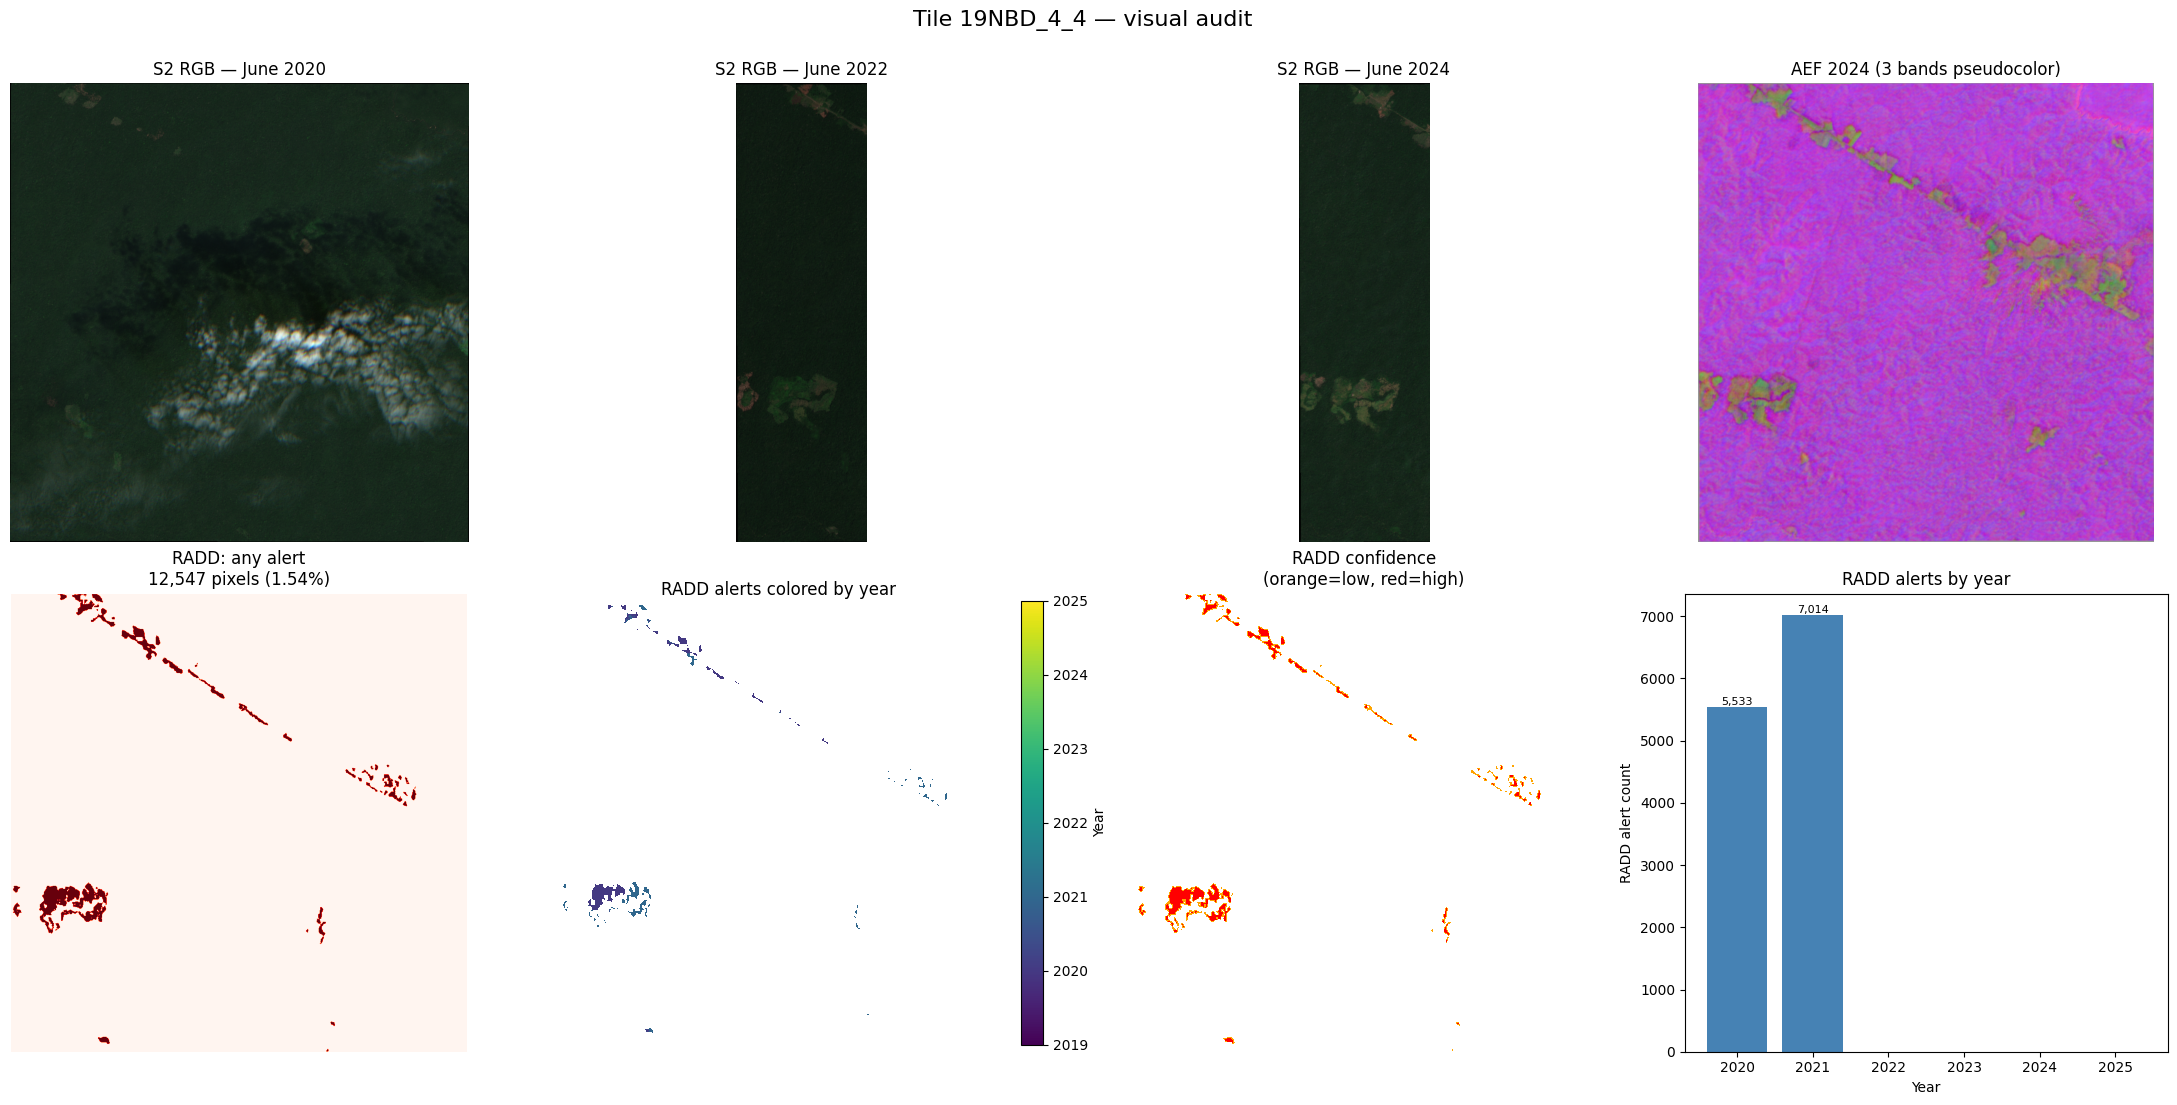


=== 19NBD_4_4 summary ===
Shape: (906, 901)
Total alerts: 12,547
Year distribution:
  2020: 5,533
  2021: 7,014
Date range: 2020-02-11 to 2021-12-02


In [4]:
from pathlib import Path
from datetime import date
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import rasterio

ROOT = Path("data/makeathon-challenge")
TILE = "19NBD_4_4"
EPOCH_RADD_ORD = date(2014, 12, 31).toordinal()

# ---- Load RADD ----
with rasterio.open(ROOT / f"labels/train/radd/radd_{TILE}_labels.tif") as r:
    radd = r.read(1)
    radd_shape = r.shape
    radd_transform = r.transform
    radd_crs = r.crs

# Decode
radd_conf = (radd // 10000).astype(np.int8)   # 0, 2, 3
radd_days = radd % 10000
radd_date_ord = np.where(radd > 0, radd_days + EPOCH_RADD_ORD, 0)

# Year of each alert
years_arr = np.zeros(radd.shape, dtype=np.int16)
mask_any = radd > 0
for year in range(2019, 2027):
    start = date(year, 1, 1).toordinal()
    end = date(year + 1, 1, 1).toordinal()
    in_year = mask_any & (radd_date_ord >= start) & (radd_date_ord < end)
    years_arr[in_year] = year

# ---- Load S2 RGB from multiple time points to see the tile visually ----
def load_s2_rgb(tile, year, month):
    """Load S2 RGB for a tile at a given year/month, return (H, W, 3) float image."""
    files = sorted((ROOT / f"sentinel-2/train/{tile}__s2_l2a").glob(
        f"*_{year}_{month:02d}.tif"))
    if not files:
        # Fall back to any file in that year
        files = sorted((ROOT / f"sentinel-2/train/{tile}__s2_l2a").glob(
            f"*_{year}_*.tif"))
    if not files:
        return None
    with rasterio.open(files[0]) as r:
        bands = r.read([4, 3, 2]).astype(np.float32) / 10000.0  # B04, B03, B02 = RGB
        rgb = np.moveaxis(bands, 0, -1)
    return np.clip(rgb * 3.0, 0, 1)

# Load S2 from 2020, 2022, 2024 to see the tile over time
rgb_2020 = load_s2_rgb(TILE, 2020, 6)
rgb_2022 = load_s2_rgb(TILE, 2022, 6)
rgb_2024 = load_s2_rgb(TILE, 2024, 6)

# ---- Load AEF for context ----
def load_aef_as_rgb(tile, year):
    p = ROOT / f"aef-embeddings/train/{tile}_{year}.tiff"
    if not p.exists():
        return None
    with rasterio.open(p) as r:
        data = r.read([1, 32, 64])   # 3 arbitrary bands as pseudo-RGB
    data = np.where(np.isfinite(data), data, 0.0)
    data = np.moveaxis(data, 0, -1)
    # Normalize to [0, 1] for display
    data = (data - data.min()) / (data.max() - data.min() + 1e-9)
    return data

aef_2020 = load_aef_as_rgb(TILE, 2020)
aef_2024 = load_aef_as_rgb(TILE, 2024)

# ---- Plot ----
fig, axes = plt.subplots(2, 4, figsize=(22, 11))

# Row 1: S2 imagery across years
for ax, img, title in [
    (axes[0, 0], rgb_2020, "S2 RGB — June 2020"),
    (axes[0, 1], rgb_2022, "S2 RGB — June 2022"),
    (axes[0, 2], rgb_2024, "S2 RGB — June 2024"),
]:
    if img is not None:
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "No S2 for this period", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(title)
    ax.axis("off")

# Row 1 col 4: AEF RGB pseudocolor
if aef_2024 is not None:
    axes[0, 3].imshow(aef_2024)
    axes[0, 3].set_title("AEF 2024 (3 bands pseudocolor)")
else:
    axes[0, 3].text(0.5, 0.5, "No AEF 2024", ha="center", va="center", transform=axes[0, 3].transAxes)
axes[0, 3].axis("off")

# Row 2: RADD analysis
# All alerts (binary mask)
axes[1, 0].imshow(mask_any, cmap="Reds", vmin=0, vmax=1)
axes[1, 0].set_title(f"RADD: any alert\n{mask_any.sum():,} pixels ({mask_any.mean():.2%})")
axes[1, 0].axis("off")

# Alerts colored by year (this is the key one)
year_cmap = plt.cm.viridis
year_masked = np.ma.masked_where(years_arr == 0, years_arr)
im = axes[1, 1].imshow(year_masked, cmap=year_cmap, vmin=2019, vmax=2025)
axes[1, 1].set_title("RADD alerts colored by year")
axes[1, 1].axis("off")
plt.colorbar(im, ax=axes[1, 1], fraction=0.046, label="Year")

# Confidence map
conf_cmap = ListedColormap(["white", "white", "orange", "red"])
conf_norm = BoundaryNorm([0, 1, 2, 3, 4], 4)
axes[1, 2].imshow(radd_conf, cmap=conf_cmap, norm=conf_norm)
axes[1, 2].set_title(f"RADD confidence\n(orange=low, red=high)")
axes[1, 2].axis("off")

# Year distribution histogram
year_counts = {}
for y in range(2020, 2026):
    year_counts[y] = int((years_arr == y).sum())
axes[1, 3].bar(list(year_counts.keys()), list(year_counts.values()), color="steelblue")
axes[1, 3].set_xlabel("Year"); axes[1, 3].set_ylabel("RADD alert count")
axes[1, 3].set_title("RADD alerts by year")
axes[1, 3].tick_params(axis="x", rotation=0)
for y, c in year_counts.items():
    if c > 0:
        axes[1, 3].text(y, c, f"{c:,}", ha="center", va="bottom", fontsize=8)

plt.suptitle(f"Tile {TILE} — visual audit", fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig(f"eda_artifacts/tile_audit_{TILE}.png", dpi=120, bbox_inches="tight")
plt.show()

# ---- Print diagnostic numbers ----
print(f"\n=== {TILE} summary ===")
print(f"Shape: {radd_shape}")
print(f"Total alerts: {mask_any.sum():,}")
print(f"Year distribution:")
for y in range(2019, 2026):
    in_year = (years_arr == y).sum()
    if in_year > 0:
        print(f"  {y}: {in_year:,}")
print(f"Date range: {date.fromordinal(int(radd_date_ord[mask_any].min()))} to "
      f"{date.fromordinal(int(radd_date_ord[mask_any].max()))}")

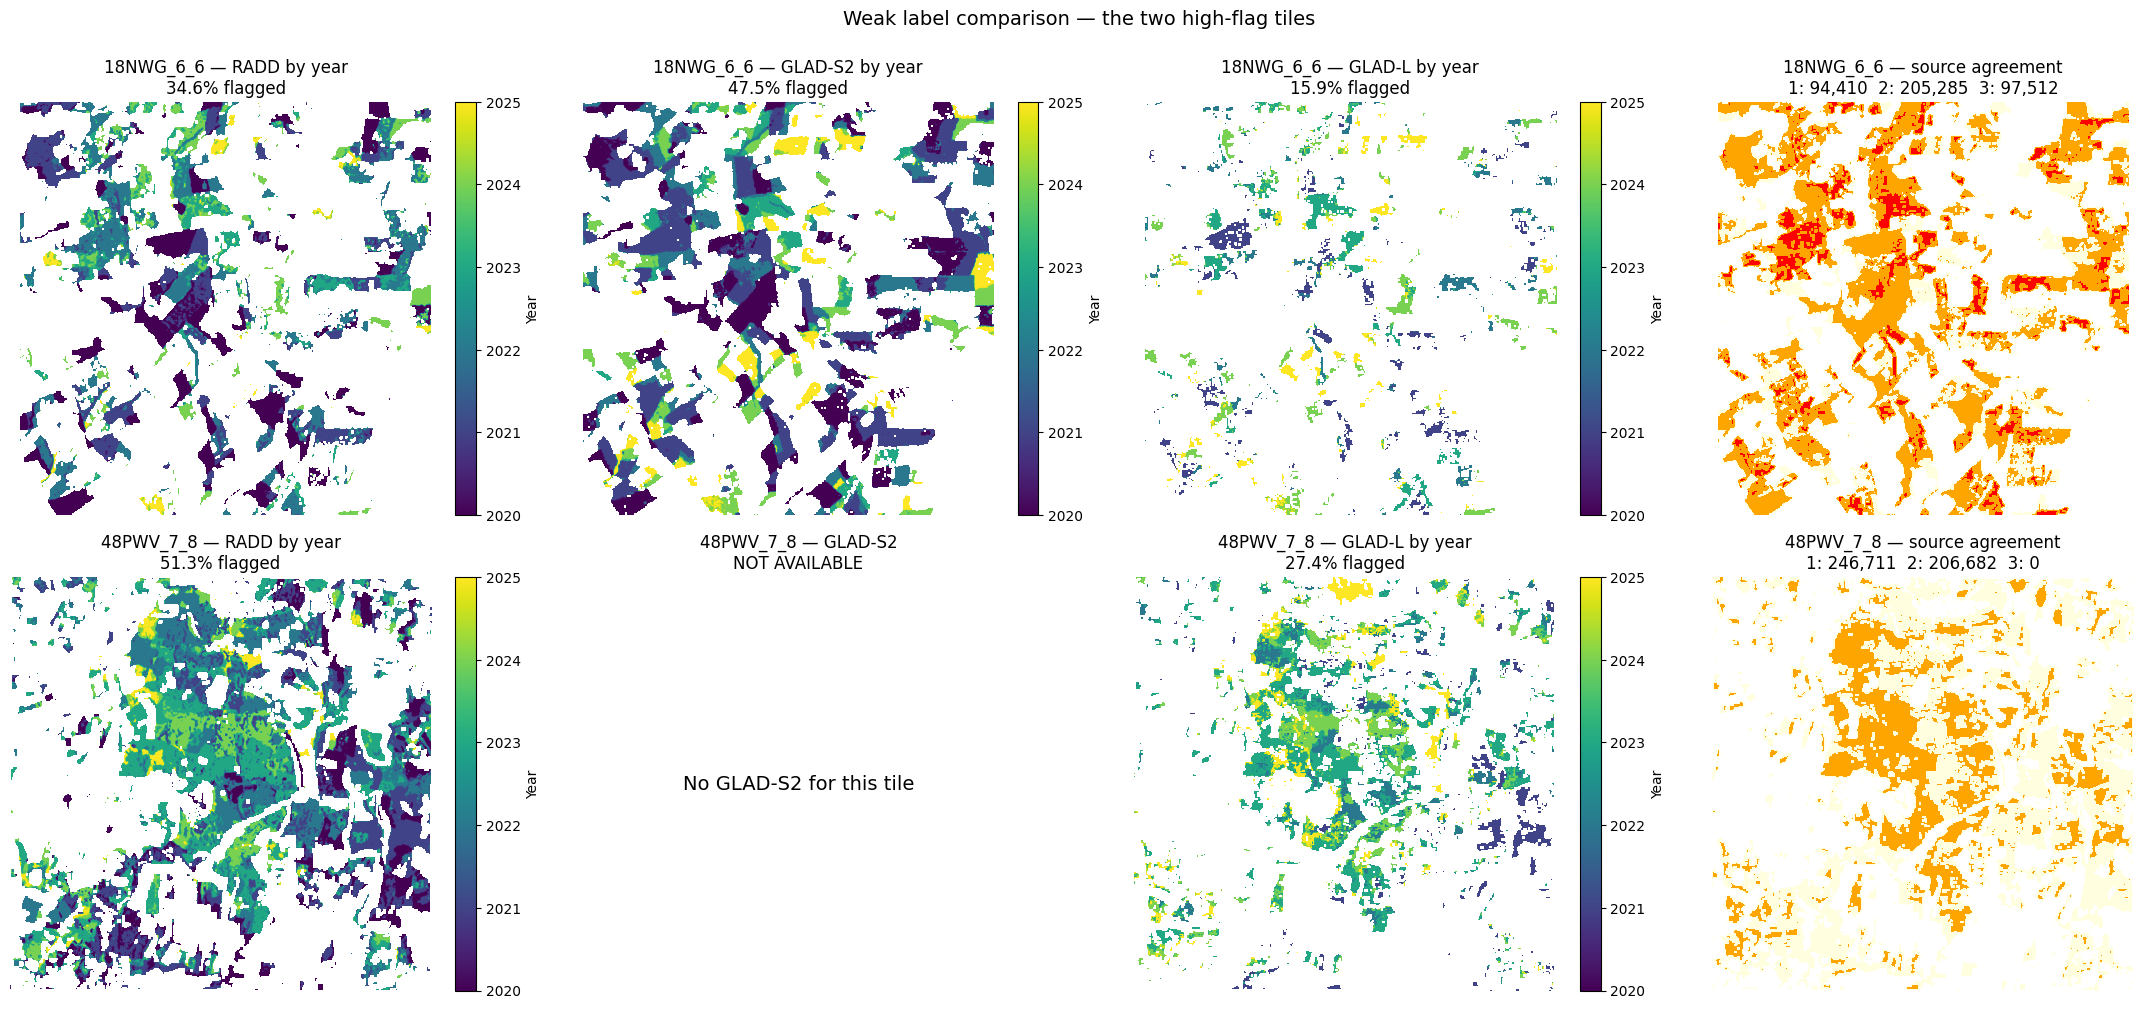


=== Diagnostic summary ===

--- 18NWG_6_6 ---
  RADD: 34.6% flagged total
    2020: 73,406 pixels (9.02%)
    2021: 51,948 pixels (6.38%)
    2022: 69,118 pixels (8.50%)
    2023: 32,611 pixels (4.01%)
    2024: 43,082 pixels (5.30%)
    2025: 11,283 pixels (1.39%)
  GLAD-S2: 47.5% flagged total
  GLAD-L: 15.9% flagged total (aggregated across years)
    2021: 5,413 pixels (4.15%)
    2022: 3,767 pixels (2.89%)
    2023: 3,457 pixels (2.65%)
    2024: 5,984 pixels (4.59%)
    2025: 6,396 pixels (4.91%)

--- 48PWV_7_8 ---
  RADD: 51.3% flagged total
    2020: 67,999 pixels (8.11%)
    2021: 95,209 pixels (11.36%)
    2022: 93,194 pixels (11.12%)
    2023: 106,989 pixels (12.77%)
    2024: 49,461 pixels (5.90%)
    2025: 17,383 pixels (2.07%)
  GLAD-S2: NOT AVAILABLE
  GLAD-L: 27.4% flagged total (aggregated across years)
    2021: 5,041 pixels (3.75%)
    2022: 4,876 pixels (3.63%)
    2023: 14,490 pixels (10.79%)
    2024: 13,507 pixels (10.06%)
    2025: 21,928 pixels (16.33%)



In [5]:
from pathlib import Path
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import rasterio
import re

ROOT = Path("data/makeathon-challenge")
TILES = ["18NWG_6_6", "48PWV_7_8"]

EPOCH_RADD_ORD   = date(2014, 12, 31).toordinal()
EPOCH_GLADS2_ORD = date(2019, 1, 1).toordinal()

def load_radd(tile):
    p = ROOT / f"labels/train/radd/radd_{tile}_labels.tif"
    with rasterio.open(p) as r:
        raw = r.read(1)
    conf = (raw // 10000).astype(np.int8)
    days = raw % 10000
    years = np.zeros(raw.shape, dtype=np.int16)
    mask = raw > 0
    for y in range(2020, 2026):
        start = date(y, 1, 1).toordinal() - EPOCH_RADD_ORD
        end   = date(y + 1, 1, 1).toordinal() - EPOCH_RADD_ORD
        years[mask & (days >= start) & (days < end)] = y
    return {"mask": mask, "conf": conf, "years": years,
            "pos_frac": float(mask.mean())}

def load_glads2(tile):
    ap = ROOT / f"labels/train/glads2/glads2_{tile}_alert.tif"
    dp = ROOT / f"labels/train/glads2/glads2_{tile}_alertDate.tif"
    if not ap.exists():
        return None
    with rasterio.open(ap) as r: alert = r.read(1)
    with rasterio.open(dp) as r: days = r.read(1)
    years = np.zeros(alert.shape, dtype=np.int16)
    mask = alert >= 2
    for y in range(2020, 2026):
        start = date(y, 1, 1).toordinal() - EPOCH_GLADS2_ORD
        end   = date(y + 1, 1, 1).toordinal() - EPOCH_GLADS2_ORD
        years[mask & (days >= start) & (days < end)] = y
    return {"alert": alert, "mask": mask, "years": years,
            "pos_frac": float(mask.mean())}

def load_gladl_all_years(tile):
    """Return dict of year -> alert array, plus aggregated mask."""
    files = sorted((ROOT / "labels/train/gladl").glob(f"gladl_{tile}_alert[0-9][0-9].tif"))
    per_year = {}
    for p in files:
        yy = int(re.search(r"alert(\d{2})\.tif$", p.name).group(1))
        year = 2000 + yy
        with rasterio.open(p) as r:
            per_year[year] = r.read(1)
    # Aggregate
    if per_year:
        shape = next(iter(per_year.values())).shape
        mask = np.zeros(shape, dtype=bool)
        years_map = np.zeros(shape, dtype=np.int16)
        max_conf = np.zeros(shape, dtype=np.uint8)
        for y in sorted(per_year.keys()):
            arr = per_year[y]
            new_alert = (arr > 0) & (years_map == 0)  # first-year assignment
            years_map[new_alert] = y
            mask = mask | (arr > 0)
            max_conf = np.maximum(max_conf, arr)
        return {"mask": mask, "years": years_map, "conf": max_conf,
                "pos_frac": float(mask.mean()), "per_year": per_year}
    return None

# ---- Build figure ----
fig, axes = plt.subplots(len(TILES), 4, figsize=(22, 5 * len(TILES)))

year_cmap = plt.cm.viridis

for row, tile in enumerate(TILES):
    radd = load_radd(tile)
    gs2  = load_glads2(tile)
    gl   = load_gladl_all_years(tile)
    
    # Col 0 — RADD alerts colored by year
    masked = np.ma.masked_where(radd["years"] == 0, radd["years"])
    im = axes[row, 0].imshow(masked, cmap=year_cmap, vmin=2020, vmax=2025)
    axes[row, 0].set_title(f"{tile} — RADD by year\n{radd['pos_frac']:.1%} flagged")
    axes[row, 0].axis("off")
    plt.colorbar(im, ax=axes[row, 0], fraction=0.046, label="Year")
    
    # Col 1 — GLAD-S2 alerts colored by year
    if gs2 is not None:
        masked = np.ma.masked_where(gs2["years"] == 0, gs2["years"])
        im = axes[row, 1].imshow(masked, cmap=year_cmap, vmin=2020, vmax=2025)
        axes[row, 1].set_title(f"{tile} — GLAD-S2 by year\n{gs2['pos_frac']:.1%} flagged")
        plt.colorbar(im, ax=axes[row, 1], fraction=0.046, label="Year")
    else:
        axes[row, 1].text(0.5, 0.5, "No GLAD-S2 for this tile", ha="center", va="center",
                          transform=axes[row, 1].transAxes, fontsize=14)
        axes[row, 1].set_title(f"{tile} — GLAD-S2\nNOT AVAILABLE")
    axes[row, 1].axis("off")
    
    # Col 2 — GLAD-L aggregated alerts colored by year
    if gl is not None:
        masked = np.ma.masked_where(gl["years"] == 0, gl["years"])
        im = axes[row, 2].imshow(masked, cmap=year_cmap, vmin=2020, vmax=2025)
        axes[row, 2].set_title(f"{tile} — GLAD-L by year\n{gl['pos_frac']:.1%} flagged")
        plt.colorbar(im, ax=axes[row, 2], fraction=0.046, label="Year")
    else:
        axes[row, 2].text(0.5, 0.5, "No GLAD-L for this tile", ha="center", va="center",
                          transform=axes[row, 2].transAxes, fontsize=14)
    axes[row, 2].axis("off")
    
    # Col 3 — Agreement map (colored by how many sources flag a pixel)
    shape = radd["mask"].shape
    
    # Reproject GS2 and GL to RADD's shape if they differ
    from rasterio.warp import reproject, Resampling
    with rasterio.open(ROOT / f"labels/train/radd/radd_{tile}_labels.tif") as r:
        ref_transform, ref_crs = r.transform, r.crs
    
    def align_to_radd(source_path, dtype=np.uint8):
        if source_path is None: return None
        out = np.zeros(shape, dtype=dtype)
        with rasterio.open(source_path) as src:
            reproject(rasterio.band(src, 1), out,
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref_transform, dst_crs=ref_crs,
                      resampling=Resampling.nearest)
        return out
    
    # Build aligned masks
    agreement = np.zeros(shape, dtype=np.int8)
    agreement += radd["mask"].astype(np.int8)
    
    gs2_path = ROOT / f"labels/train/glads2/glads2_{tile}_alert.tif"
    if gs2_path.exists():
        aligned = align_to_radd(gs2_path, dtype=np.uint8)
        agreement += (aligned >= 2).astype(np.int8)
    
    gl_files = sorted((ROOT / "labels/train/gladl").glob(f"gladl_{tile}_alert[0-9][0-9].tif"))
    if gl_files:
        gl_agg = np.zeros(shape, dtype=bool)
        for gf in gl_files:
            aligned = align_to_radd(gf, dtype=np.uint8)
            gl_agg = gl_agg | (aligned > 0)
        agreement += gl_agg.astype(np.int8)
    
    agree_cmap = ListedColormap(["white", "lightyellow", "orange", "red"])
    agree_norm = BoundaryNorm([0, 1, 2, 3, 4], 4)
    im = axes[row, 3].imshow(agreement, cmap=agree_cmap, norm=agree_norm)
    
    n3 = int((agreement == 3).sum())
    n2 = int((agreement == 2).sum())
    n1 = int((agreement == 1).sum())
    axes[row, 3].set_title(f"{tile} — source agreement\n"
                           f"1: {n1:,}  2: {n2:,}  3: {n3:,}")
    axes[row, 3].axis("off")

plt.suptitle("Weak label comparison — the two high-flag tiles", fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig("eda_artifacts/high_flag_tiles.png", dpi=120, bbox_inches="tight")
plt.show()

# ---- Print diagnostic summary ----
print("\n=== Diagnostic summary ===\n")
for tile in TILES:
    print(f"--- {tile} ---")
    radd = load_radd(tile)
    print(f"  RADD: {radd['pos_frac']:.1%} flagged total")
    year_counts = {int(y): int((radd['years'] == y).sum()) for y in range(2020, 2026) if (radd['years'] == y).any()}
    for y, c in year_counts.items():
        print(f"    {y}: {c:,} pixels ({c/radd['mask'].size:.2%})")
    
    gs2 = load_glads2(tile)
    if gs2 is not None:
        print(f"  GLAD-S2: {gs2['pos_frac']:.1%} flagged total")
    else:
        print(f"  GLAD-S2: NOT AVAILABLE")
    
    gl = load_gladl_all_years(tile)
    if gl is not None:
        print(f"  GLAD-L: {gl['pos_frac']:.1%} flagged total (aggregated across years)")
        for y, arr in sorted(gl["per_year"].items()):
            print(f"    {y}: {(arr > 0).sum():,} pixels ({(arr > 0).mean():.2%})")
    print()

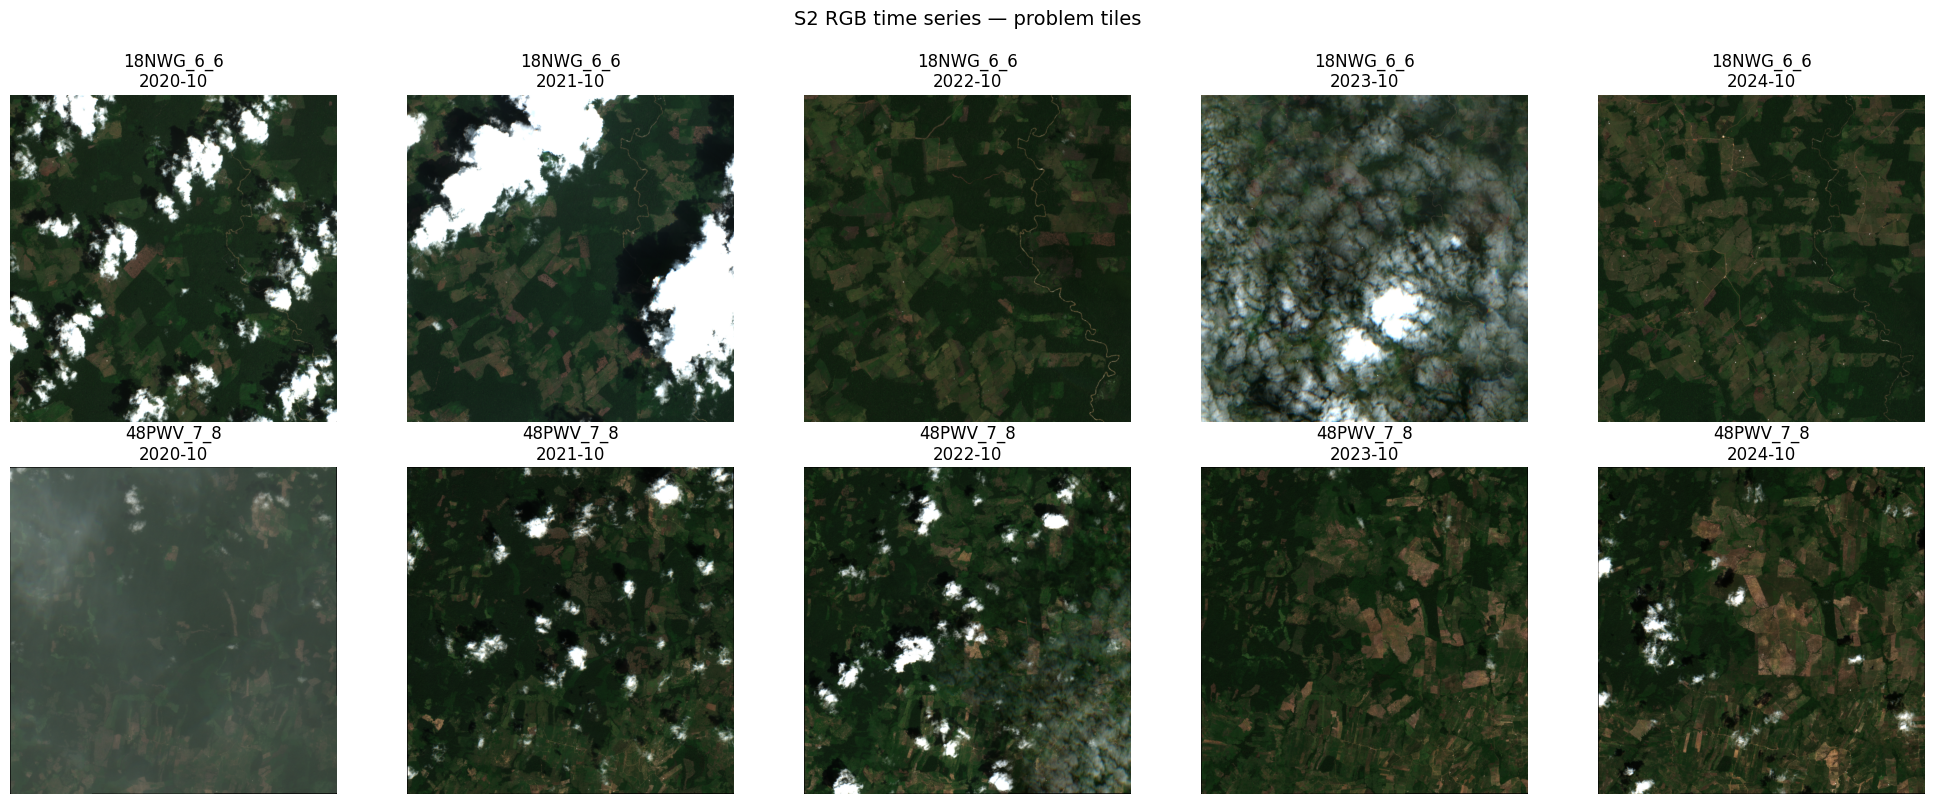

In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio

ROOT = Path("data/makeathon-challenge")
TILES = ["18NWG_6_6", "48PWV_7_8"]
YEARS = [2020, 2021, 2022, 2023, 2024]

def load_s2_rgb(tile, year, preferred_months=(7, 6, 8, 5, 9, 4, 10, 3, 11, 2, 12, 1)):
    """Load S2 RGB, trying preferred months in order."""
    s2_dir = ROOT / f"sentinel-2/train/{tile}__s2_l2a"
    if not s2_dir.exists():
        return None, None
    
    for month in preferred_months:
        files = sorted(s2_dir.glob(f"*_{year}_{month:02d}.tif"))
        if files:
            with rasterio.open(files[0]) as r:
                bands = r.read([4, 3, 2]).astype(np.float32) / 10000.0
                rgb = np.moveaxis(bands, 0, -1)
                # Check if mostly valid
                if (bands[0] > 0).mean() > 0.3:
                    return np.clip(rgb * 3.0, 0, 1), f"{year}-{month:02d}"
    
    # Fallback: any file from that year
    any_files = sorted(s2_dir.glob(f"*_{year}_*.tif"))
    if any_files:
        with rasterio.open(any_files[0]) as r:
            bands = r.read([4, 3, 2]).astype(np.float32) / 10000.0
            rgb = np.moveaxis(bands, 0, -1)
        return np.clip(rgb * 3.0, 0, 1), f"{year} (fallback)"
    
    return None, None

# ---- Plot: 2 rows × 5 years ----
fig, axes = plt.subplots(len(TILES), len(YEARS), figsize=(20, 8))

for row, tile in enumerate(TILES):
    for col, year in enumerate(YEARS):
        rgb, label = load_s2_rgb(tile, year)
        ax = axes[row, col]
        if rgb is not None:
            ax.imshow(rgb)
            ax.set_title(f"{tile}\n{label}")
        else:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"{tile} {year}")
        ax.axis("off")

plt.suptitle("S2 RGB time series — problem tiles", fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig("eda_artifacts/s2_timeseries_problem_tiles.png", dpi=120, bbox_inches="tight")
plt.show()

In [7]:
from pathlib import Path
from datetime import date
import re
import numpy as np
import pandas as pd
import rasterio
from tqdm.auto import tqdm

ROOT = Path("data/makeathon-challenge")

def audit_gladl_file(path):
    """Audit one GLAD-L alert file (one tile, one year)."""
    # Parse tile and year from filename: gladl_{tile}_alertYY.tif
    m = re.match(r"gladl_(.+)_alert(\d{2})\.tif", path.name)
    if not m:
        return None
    tile = m.group(1)
    year = 2000 + int(m.group(2))
    
    # Corresponding date file
    date_path = path.parent / f"gladl_{tile}_alertDate{m.group(2)}.tif"
    
    with rasterio.open(path) as r:
        alert = r.read(1)
        shape = r.shape
        dtype_alert = r.dtypes[0]
    
    date_exists = date_path.exists()
    doy = None
    dtype_date = None
    if date_exists:
        with rasterio.open(date_path) as r:
            doy = r.read(1)
            dtype_date = r.dtypes[0]
    
    total_pixels = alert.size
    alert_mask = alert > 0
    n_alerts = int(alert_mask.sum())
    
    row = {
        "tile": tile,
        "year": year,
        "shape": str(shape),
        "alert_dtype": str(dtype_alert),
        "date_dtype": str(dtype_date) if dtype_date else "MISSING",
        "date_file_exists": date_exists,
        "total_pixels": total_pixels,
        "n_alerts": n_alerts,
        "alert_frac": round(n_alerts / total_pixels, 5),
    }
    
    if n_alerts == 0:
        row["status"] = "empty"
        return row
    
    # --- Check 1: Confidence values ---
    # Expected: 0 (no loss), 2 (probable), 3 (confirmed)
    alerts_only = alert[alert_mask]
    unique_vals = np.unique(alerts_only)
    valid_mask = np.isin(alerts_only, [2, 3])
    n_invalid = int((~valid_mask).sum())
    invalid_vals = [int(v) for v in np.unique(alerts_only[~valid_mask])] if n_invalid else []
    
    n_probable = int((alerts_only == 2).sum())
    n_confirmed = int((alerts_only == 3).sum())
    
    row.update({
        "unique_conf_values": [int(v) for v in unique_vals],
        "n_invalid_conf": n_invalid,
        "invalid_conf_values": invalid_vals,
        "n_probable": n_probable,
        "n_confirmed": n_confirmed,
        "confirmed_frac": round(n_confirmed / n_alerts, 3),
    })
    
    # --- Check 2: Date values (day-of-year) ---
    if date_exists:
        doy_at_alerts = doy[alert_mask]
        
        # Check spec: should be 1-366, 0 where no alert
        # But we're only looking at positions where alert > 0, so doy should be > 0 here
        n_doy_zero_on_alert = int((doy_at_alerts == 0).sum())   # alert fires but no date → mismatch
        n_doy_out_of_range  = int(((doy_at_alerts > 366) | (doy_at_alerts < 0)).sum())
        n_doy_impossible    = int((doy_at_alerts > 366).sum())  # day-of-year can't exceed 366
        
        # Where there's no alert, what's the date?
        no_alert_mask = ~alert_mask
        doy_where_no_alert = doy[no_alert_mask]
        n_nonzero_date_without_alert = int((doy_where_no_alert > 0).sum())  # date but no alert → mismatch
        
        valid_doy = doy_at_alerts[(doy_at_alerts >= 1) & (doy_at_alerts <= 366)]
        doy_min = int(valid_doy.min()) if len(valid_doy) else None
        doy_max = int(valid_doy.max()) if len(valid_doy) else None
        
        row.update({
            "doy_min": doy_min,
            "doy_max": doy_max,
            "n_doy_zero_on_alert": n_doy_zero_on_alert,
            "n_doy_out_of_range": n_doy_out_of_range,
            "n_doy_impossible_366plus": n_doy_impossible,
            "n_nonzero_date_without_alert": n_nonzero_date_without_alert,
        })
    else:
        row.update({
            "doy_min": None, "doy_max": None,
            "n_doy_zero_on_alert": None, "n_doy_out_of_range": None,
            "n_doy_impossible_366plus": None, "n_nonzero_date_without_alert": None,
        })
    
    row["status"] = "checked"
    return row


# Run on all GLAD-L alert files
alert_files = sorted((ROOT / "labels/train/gladl").glob("*_alert[0-9][0-9].tif"))
print(f"Found {len(alert_files)} GLAD-L alert files")

results = [audit_gladl_file(p) for p in tqdm(alert_files, desc="auditing GLAD-L")]
results = [r for r in results if r is not None]
gladl_audit = pd.DataFrame(results)

# Save
gladl_audit.to_csv("eda_artifacts/gladl_audit.csv", index=False)

# --- Print summary table ---
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)

print("\n=== GLAD-L audit per (tile, year) ===")
display_cols = [
    "tile", "year", "shape", "n_alerts", "alert_frac",
    "unique_conf_values", "n_invalid_conf",
    "n_probable", "n_confirmed", "confirmed_frac",
    "doy_min", "doy_max",
    "n_doy_zero_on_alert", "n_doy_impossible_366plus",
    "n_nonzero_date_without_alert",
]
print(gladl_audit[display_cols].to_string(index=False))

# --- Flags ---
print("\n=== Flags ===")

missing_date_files = gladl_audit[~gladl_audit.date_file_exists]
if len(missing_date_files):
    print(f"⚠ {len(missing_date_files)} tile-years missing their alertDate file:")
    print(missing_date_files[["tile", "year"]])
else:
    print("✓ All alert files have corresponding date files")

invalid_conf = gladl_audit[gladl_audit.n_invalid_conf > 0]
if len(invalid_conf):
    print(f"\n⚠ {len(invalid_conf)} tile-years have unexpected confidence values (expected 2 or 3):")
    print(invalid_conf[["tile", "year", "invalid_conf_values", "n_invalid_conf"]])
else:
    print("\n✓ All confidence values are valid (2 or 3)")

out_of_range = gladl_audit[gladl_audit.n_doy_impossible_366plus.fillna(0) > 0]
if len(out_of_range):
    print(f"\n⚠ {len(out_of_range)} tile-years have DOY > 366:")
    print(out_of_range[["tile", "year", "doy_max", "n_doy_impossible_366plus"]])
else:
    print("\n✓ All DOY values ≤ 366")

mismatch_zero = gladl_audit[gladl_audit.n_doy_zero_on_alert.fillna(0) > 0]
if len(mismatch_zero):
    print(f"\n⚠ {len(mismatch_zero)} tile-years have pixels with alert>0 but date=0:")
    print(mismatch_zero[["tile", "year", "n_doy_zero_on_alert"]])
else:
    print("\n✓ All alert pixels have valid dates")

mismatch_reverse = gladl_audit[gladl_audit.n_nonzero_date_without_alert.fillna(0) > 0]
if len(mismatch_reverse):
    print(f"\n⚠ {len(mismatch_reverse)} tile-years have pixels with date>0 but alert=0:")
    print(mismatch_reverse[["tile", "year", "n_nonzero_date_without_alert"]])
else:
    print("\n✓ No orphan date values")

# --- Per-tile and per-year summaries ---
print("\n=== Coverage: which (tile, year) combinations exist ===")
coverage = gladl_audit.pivot_table(
    index="tile", columns="year", values="n_alerts", aggfunc="sum", fill_value=None
)
print(coverage)

print("\n=== Per-year summary across all tiles ===")
per_year = gladl_audit.groupby("year").agg(
    n_tiles=("tile", "count"),
    total_alerts=("n_alerts", "sum"),
    mean_alert_frac=("alert_frac", "mean"),
    mean_confirmed_frac=("confirmed_frac", "mean"),
).round(4)
print(per_year)

print("\n=== Per-tile summary aggregated across years ===")
per_tile = gladl_audit.groupby("tile").agg(
    years_available=("year", "count"),
    total_alerts=("n_alerts", "sum"),
    mean_alert_frac=("alert_frac", "mean"),
    mean_confirmed_frac=("confirmed_frac", "mean"),
).round(4)
print(per_tile)

print("\n=== Summary ===")
print(f"Total tile-year files: {len(gladl_audit)}")
print(f"Unique tiles:          {gladl_audit.tile.nunique()}")
print(f"Unique years:          {sorted(gladl_audit.year.unique().tolist())}")
print(f"Total alerts:          {gladl_audit.n_alerts.sum():,}")
print(f"Mean alert fraction:   {gladl_audit.alert_frac.mean():.3%}")
print(f"Mean confirmed ratio:  {(gladl_audit.n_confirmed.sum() / max(gladl_audit.n_alerts.sum(), 1)):.1%}")

Found 80 GLAD-L alert files


auditing GLAD-L:   0%|          | 0/80 [00:00<?, ?it/s]


=== GLAD-L audit per (tile, year) ===
     tile  year      shape  n_alerts  alert_frac unique_conf_values  n_invalid_conf  n_probable  n_confirmed  confirmed_frac  doy_min  doy_max  n_doy_zero_on_alert  n_doy_impossible_366plus  n_nonzero_date_without_alert
18NWG_6_6  2021 (362, 360)      5413     0.04154             [2, 3]               0          89         5324           0.984       12      365                    0                         0                             0
18NWG_6_6  2022 (362, 360)      3767     0.02891                [3]               0           0         3767           1.000        7      359                    0                         0                             0
18NWG_6_6  2023 (362, 360)      3457     0.02653                [3]               0           0         3457           1.000        6      363                    0                         0                             0
18NWG_6_6  2024 (362, 360)      5984     0.04592                [3]              

In [8]:
# Quick check: within each year, how uniformly are alerts distributed across DOY?
for p in sorted((ROOT / "labels/train/gladl").glob("*_alertDate2[34].tif")):
    tile = re.search(r"gladl_(.+)_alertDate", p.name).group(1)
    year = int(re.search(r"Date(\d{2})", p.name).group(1)) + 2000
    with rasterio.open(p) as r: doy = r.read(1)
    doy_valid = doy[doy > 0]
    if len(doy_valid):
        print(f"{tile} {year}: DOY p10={np.percentile(doy_valid, 10):.0f}, "
              f"median={np.median(doy_valid):.0f}, p90={np.percentile(doy_valid, 90):.0f}")

18NWG_6_6 2023: DOY p10=138, median=290, p90=338
18NWG_6_6 2024: DOY p10=13, median=54, p90=277
18NWH_1_4 2023: DOY p10=138, median=138, p90=258
18NWH_1_4 2024: DOY p10=53, median=101, p90=165
18NWJ_8_9 2023: DOY p10=170, median=338, p90=354
18NWJ_8_9 2024: DOY p10=29, median=229, p90=349
18NWM_9_4 2023: DOY p10=58, median=154, p90=274
18NWM_9_4 2024: DOY p10=77, median=189, p90=349
18NXH_6_8 2023: DOY p10=235, median=323, p90=363
18NXH_6_8 2024: DOY p10=14, median=110, p90=342
18NXJ_7_6 2023: DOY p10=35, median=259, p90=363
18NXJ_7_6 2024: DOY p10=38, median=222, p90=350
18NYH_9_9 2023: DOY p10=35, median=76, p90=244
18NYH_9_9 2024: DOY p10=7, median=55, p90=279
19NBD_4_4 2023: DOY p10=30, median=76, p90=276
19NBD_4_4 2024: DOY p10=15, median=231, p90=343
47QMB_0_8 2023: DOY p10=38, median=88, p90=144
47QMB_0_8 2024: DOY p10=35, median=83, p90=299
47QQV_2_4 2023: DOY p10=42, median=138, p90=298
47QQV_2_4 2024: DOY p10=53, median=109, p90=117
48PUT_0_8 2023: DOY p10=60, median=89, p90=

In [9]:
from pathlib import Path
from datetime import date
import re
import numpy as np
import pandas as pd
import rasterio
from tqdm.auto import tqdm

ROOT = Path("data/makeathon-challenge")
EPOCH_GLADS2 = date(2019, 1, 1)
EPOCH_GLADS2_ORD = EPOCH_GLADS2.toordinal()
TODAY_ORD = date.today().toordinal()
MAX_PLAUSIBLE_DAYS = TODAY_ORD - EPOCH_GLADS2_ORD

def audit_glads2_tile(tile):
    """Audit one GLAD-S2 tile (one alert + alertDate pair)."""
    alert_path = ROOT / f"labels/train/glads2/glads2_{tile}_alert.tif"
    date_path  = ROOT / f"labels/train/glads2/glads2_{tile}_alertDate.tif"
    
    if not alert_path.exists():
        return {"tile": tile, "has_glads2": False, "status": "no_alert_file"}
    
    with rasterio.open(alert_path) as r:
        alert = r.read(1)
        shape = r.shape
        dtype_alert = r.dtypes[0]
    
    date_exists = date_path.exists()
    if date_exists:
        with rasterio.open(date_path) as r:
            days = r.read(1)
            dtype_date = r.dtypes[0]
    else:
        days = None
        dtype_date = None
    
    total_pixels = alert.size
    any_alert = alert > 0           # includes preliminary
    confirmed_positive = alert >= 2 # excludes preliminary
    
    row = {
        "tile": tile,
        "has_glads2": True,
        "shape": str(shape),
        "alert_dtype": str(dtype_alert),
        "date_dtype": str(dtype_date) if dtype_date else "MISSING",
        "date_file_exists": date_exists,
        "total_pixels": total_pixels,
        "n_any_alert": int(any_alert.sum()),
        "n_positive_excl_prelim": int(confirmed_positive.sum()),
        "positive_frac": round(confirmed_positive.mean(), 5),
    }
    
    if not any_alert.any():
        row["status"] = "empty"
        return row
    
    alerts_only = alert[any_alert]
    unique_vals = [int(v) for v in np.unique(alerts_only)]
    valid_mask = np.isin(alerts_only, [1, 2, 3, 4])
    n_invalid = int((~valid_mask).sum())
    invalid_vals = [int(v) for v in np.unique(alerts_only[~valid_mask])] if n_invalid else []
    
    row.update({
        "unique_conf_values": unique_vals,
        "n_invalid_conf": n_invalid,
        "invalid_conf_values": invalid_vals,
        "n_prelim": int((alert == 1).sum()),
        "n_low": int((alert == 2).sum()),
        "n_med": int((alert == 3).sum()),
        "n_high": int((alert == 4).sum()),
    })
    
    if date_exists:
        days_any = days[any_alert]
        n_future = int((days_any > MAX_PLAUSIBLE_DAYS).sum())
        n_pre_2019 = int((days_any < 1).sum())
        n_date_zero_on_alert = int((days_any == 0).sum())
        n_date_nonzero_no_alert = int((days[~any_alert] > 0).sum())
        
        valid_days = days_any[(days_any >= 1) & (days_any <= MAX_PLAUSIBLE_DAYS)]
        if len(valid_days):
            date_min = date.fromordinal(int(valid_days.min()) + EPOCH_GLADS2_ORD)
            date_max = date.fromordinal(int(valid_days.max()) + EPOCH_GLADS2_ORD)
        else:
            date_min, date_max = None, None
        
        # Bucket by year
        years_dict = {}
        for y in range(2020, 2026):
            start = date(y, 1, 1).toordinal() - EPOCH_GLADS2_ORD
            end   = date(y + 1, 1, 1).toordinal() - EPOCH_GLADS2_ORD
            in_year = any_alert & (days >= start) & (days < end)
            years_dict[f"y{y}"] = int(in_year.sum())
        row.update(years_dict)
        
        row.update({
            "date_min": str(date_min) if date_min else None,
            "date_max": str(date_max) if date_max else None,
            "n_future_dates": n_future,
            "n_pre_epoch_dates": n_pre_2019,
            "n_date_zero_on_alert": n_date_zero_on_alert,
            "n_date_nonzero_no_alert": n_date_nonzero_no_alert,
        })
    
    row["status"] = "checked"
    return row


# Run on all training tiles (GLAD-S2 may be missing for some)
train_tiles = sorted([p.name.replace("__s2_l2a", "") 
                      for p in (ROOT / "sentinel-2/train").iterdir()])

results = [audit_glads2_tile(t) for t in tqdm(train_tiles, desc="GLAD-S2")]
glads2_audit = pd.DataFrame(results)
glads2_audit.to_csv("eda_artifacts/glads2_audit.csv", index=False)

# Print
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 250)

# Which tiles have GLAD-S2?
has_it = glads2_audit[glads2_audit.has_glads2]
missing = glads2_audit[~glads2_audit.has_glads2]
print(f"GLAD-S2 available for {len(has_it)}/{len(glads2_audit)} tiles")
if len(missing):
    print(f"Missing: {missing.tile.tolist()}")

print("\n=== GLAD-S2 audit per tile ===")
cols = ["tile", "n_any_alert", "positive_frac",
        "n_prelim", "n_low", "n_med", "n_high",
        "y2020", "y2021", "y2022", "y2023", "y2024", "y2025",
        "date_min", "date_max",
        "n_invalid_conf", "n_future_dates", "n_date_zero_on_alert"]
print(has_it[cols].to_string(index=False))

print("\n=== Flags ===")
bad = has_it[has_it.n_invalid_conf.fillna(0) > 0]
if len(bad):
    print(f"⚠ Invalid confidence values: {len(bad)} tiles")
    print(bad[["tile", "invalid_conf_values"]])
else:
    print("✓ All confidence values are in [1, 2, 3, 4]")

bad = has_it[has_it.n_future_dates.fillna(0) > 0]
if len(bad): print(f"⚠ Future dates: {len(bad)} tiles")
else: print("✓ No future dates")

bad = has_it[has_it.n_date_zero_on_alert.fillna(0) > 0]
if len(bad): print(f"⚠ Alert with date=0: {len(bad)} tiles")
else: print("✓ All alerts have valid dates")

print("\n=== Confidence distribution across all tiles ===")
total_prelim = has_it.n_prelim.sum()
total_low = has_it.n_low.sum()
total_med = has_it.n_med.sum()
total_high = has_it.n_high.sum()
total = total_prelim + total_low + total_med + total_high
print(f"Preliminary (1): {total_prelim:,} ({total_prelim/total:.1%})")
print(f"Low (2):         {total_low:,} ({total_low/total:.1%})")
print(f"Medium (3):      {total_med:,} ({total_med/total:.1%})")
print(f"High (4):        {total_high:,} ({total_high/total:.1%})")

GLAD-S2:   0%|          | 0/16 [00:00<?, ?it/s]

GLAD-S2 available for 8/16 tiles
Missing: ['47QMB_0_8', '47QQV_2_4', '48PUT_0_8', '48PWV_7_8', '48PXC_7_7', '48PYB_3_6', '48QVE_3_0', '48QWD_2_2']

=== GLAD-S2 audit per tile ===
     tile  n_any_alert  positive_frac  n_prelim   n_low    n_med   n_high   y2020   y2021   y2022   y2023   y2024   y2025   date_min   date_max  n_invalid_conf  n_future_dates  n_date_zero_on_alert
18NWG_6_6     388624.0        0.47489    2252.0 51950.0 111787.0 222635.0 89257.0 94059.0 63975.0 23292.0 43011.0 36967.0 2019-01-05 2026-04-03             0.0             0.0                   0.0
18NWH_1_4      35615.0        0.04332     371.0  8074.0  12152.0  15018.0 13912.0  6021.0  3587.0  1276.0  4406.0  2538.0 2019-01-05 2026-03-21             0.0             0.0                   0.0
18NWJ_8_9      86940.0        0.10535    1134.0 15314.0  20505.0  49987.0 19580.0 11722.0 17258.0   974.0  6883.0 19567.0 2019-01-05 2026-03-21             0.0             0.0                   0.0
18NWM_9_4      58184.0       

In [10]:
"""
Pseudo-GT builder for osapiens deforestation challenge.

Design:
  - GLAD-L is the anchor: a pixel becomes positive only if GLAD-L confirms
  - RADD and GLAD-S2 corroborate
  - Temporal window: 2023+2024 only
  - Forest-prior gate: pixel must have been stable forest in year t-1
  - Adaptive for SE Asia tiles missing GLAD-S2
"""

from pathlib import Path
from datetime import date
import re
import json
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.ndimage import binary_opening, label as cc_label
from tqdm.auto import tqdm

# ============================================================
# CONFIGURATION — change these to adjust behavior
# ============================================================
ROOT = Path("data/makeathon-challenge")
ART = Path("eda_artifacts"); ART.mkdir(exist_ok=True)
PGT_DIR = ART / "pseudo_gt"; PGT_DIR.mkdir(exist_ok=True)

# Target year window (inclusive on start, exclusive on end)
TARGET_YEARS = [2023, 2024]
WINDOW_START_ORD = date(TARGET_YEARS[0], 1, 1).toordinal()
WINDOW_END_ORD   = date(TARGET_YEARS[-1] + 1, 1, 1).toordinal()

# Epochs
EPOCH_RADD_ORD   = date(2014, 12, 31).toordinal()
EPOCH_GLADS2_ORD = date(2019, 1, 1).toordinal()

# Forest-prior filter: require AEF stability between year t-2 and t-1
# A pixel is "stable forest" if cos(aef_t-2, aef_t-1) > this threshold
FOREST_STABILITY_THRESHOLD = 0.85
USE_FOREST_MASK = True   # set False to skip forest-prior filter

# Spatial cleanup
MIN_COMPONENT_SIZE = 5   # drop connected components smaller than this

# Per-tile weight based on number of sources
TILE_WEIGHT = {3: 1.0, 2: 0.8, 1: 0.5, 0: 0.0}

# Special-case tile handling (from audits)
RADD_EXCLUDE_TILES = {"19NBD_4_4"}   # RADD coverage gap after 2021 on this tile
TILE_WEIGHT_OVERRIDE = {
    "48PXC_7_7": 0.6,   # GLAD-L 2024 truncated in April
}


# ============================================================
# Source loaders — each returns dict with confidence, date, in-window mask
# ============================================================

def get_ref_grid(tile):
    """S2 UTM grid is canonical."""
    s2 = next((ROOT / f"sentinel-2/train/{tile}__s2_l2a").glob("*.tif"))
    with rasterio.open(s2) as r:
        return r.transform, r.crs, r.shape

def reproj(path, ref_transform, ref_crs, ref_shape, dtype, resampling=Resampling.nearest):
    out = np.zeros(ref_shape, dtype=dtype)
    with rasterio.open(path) as src:
        reproject(rasterio.band(src, 1), out,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=ref_transform, dst_crs=ref_crs,
                  resampling=resampling)
    return out

def load_radd(tile, ref_transform, ref_crs, ref_shape):
    if tile in RADD_EXCLUDE_TILES:
        return None
    p = ROOT / f"labels/train/radd/radd_{tile}_labels.tif"
    if not p.exists():
        return None
    raw = reproj(p, ref_transform, ref_crs, ref_shape, dtype=np.int32)
    conf = (raw // 10000).astype(np.int8)      # 0, 2, 3
    days = raw % 10000
    date_ord = np.where(raw > 0, days + EPOCH_RADD_ORD, 0)
    in_window = (date_ord >= WINDOW_START_ORD) & (date_ord < WINDOW_END_ORD)
    return {
        "high":     (conf == 3) & in_window,
        "low":      (conf == 2) & in_window,
        "any":      (raw > 0)   & in_window,
        "date":     np.where(in_window, date_ord, 0),
    }

def load_glads2(tile, ref_transform, ref_crs, ref_shape):
    ap = ROOT / f"labels/train/glads2/glads2_{tile}_alert.tif"
    dp = ROOT / f"labels/train/glads2/glads2_{tile}_alertDate.tif"
    if not (ap.exists() and dp.exists()):
        return None
    alert = reproj(ap, ref_transform, ref_crs, ref_shape, dtype=np.uint8)
    days  = reproj(dp, ref_transform, ref_crs, ref_shape, dtype=np.uint16)
    date_ord = np.where(alert > 0, days.astype(np.int64) + EPOCH_GLADS2_ORD, 0)
    in_window = (date_ord >= WINDOW_START_ORD) & (date_ord < WINDOW_END_ORD)
    return {
        "high":    (alert == 4) & in_window,
        "medium":  (alert == 3) & in_window,
        "low":     (alert == 2) & in_window,
        "prelim":  (alert == 1) & in_window,
        "any_confirmed": (alert >= 2) & in_window,   # excludes preliminary
        "date":    np.where(in_window, date_ord, 0),
    }

def load_gladl(tile, ref_transform, ref_crs, ref_shape):
    """Aggregate GLAD-L for target years into a single mask + confidence + earliest date."""
    alert_files = sorted((ROOT / "labels/train/gladl").glob(f"gladl_{tile}_alert[0-9][0-9].tif"))
    if not alert_files:
        return None
    
    confirmed = np.zeros(ref_shape, dtype=bool)
    any_alert = np.zeros(ref_shape, dtype=bool)
    earliest_date = np.zeros(ref_shape, dtype=np.int64)
    
    for ap in alert_files:
        yy = int(re.search(r"alert(\d{2})\.tif$", ap.name).group(1))
        year = 2000 + yy
        if year not in TARGET_YEARS:
            continue
        dp = ROOT / f"labels/train/gladl/gladl_{tile}_alertDate{yy:02d}.tif"
        if not dp.exists(): continue
        
        alert = reproj(ap, ref_transform, ref_crs, ref_shape, dtype=np.uint8)
        doy = reproj(dp, ref_transform, ref_crs, ref_shape, dtype=np.uint16)
        
        year_start = date(year, 1, 1).toordinal()
        year_date = np.where(alert > 0, doy.astype(np.int64) + year_start - 1, 0)
        
        year_mask = alert > 0
        year_confirmed = alert == 3
        
        # Keep earliest date where alerts overlap across years
        earlier = year_mask & ((earliest_date == 0) | ((year_date > 0) & (year_date < earliest_date)))
        earliest_date = np.where(earlier, year_date, earliest_date)
        
        any_alert = any_alert | year_mask
        confirmed = confirmed | year_confirmed
    
    if not any_alert.any():
        return None
    
    return {
        "confirmed": confirmed,
        "any":       any_alert,
        "date":      earliest_date,
    }


# ============================================================
# Forest-prior filter
# ============================================================

def load_aef(path, ref_transform, ref_crs, ref_shape):
    """Load AEF, reproject to reference grid, normalize, return (64, H, W) + valid mask."""
    with rasterio.open(path) as src:
        raw = src.read()
        # Identify nodata (NaN) pixels
        valid_src = np.isfinite(raw).all(axis=0)
        raw = np.where(np.isfinite(raw), raw, 0.0)
    
    aef = np.zeros((64, *ref_shape), dtype=np.float32)
    with rasterio.open(path) as src:
        for b in range(64):
            reproject(raw[b].astype(np.float32), aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref_transform, dst_crs=ref_crs,
                      resampling=Resampling.bilinear)
    
    # Reproject validity mask
    valid = np.zeros(ref_shape, dtype=np.uint8)
    with rasterio.open(path) as src:
        reproject(valid_src.astype(np.uint8), valid,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=ref_transform, dst_crs=ref_crs,
                  resampling=Resampling.nearest)
    
    # Renormalize to unit vectors
    norms = np.linalg.norm(aef, axis=0, keepdims=True)
    aef = np.where(norms > 1e-6, aef / norms, aef)
    return aef, valid.astype(bool)

def compute_forest_mask(tile, ref_transform, ref_crs, ref_shape):
    """Return (H, W) bool mask: True where pixel was stable forest before target window."""
    baseline_year = TARGET_YEARS[0] - 1    # e.g. 2022 if target is 2023-24
    prior_year = baseline_year - 1         # 2021
    
    p_baseline = ROOT / f"aef-embeddings/train/{tile}_{baseline_year}.tiff"
    p_prior    = ROOT / f"aef-embeddings/train/{tile}_{prior_year}.tiff"
    
    if not (p_baseline.exists() and p_prior.exists()):
        # Can't compute — return all-True (no filter)
        return np.ones(ref_shape, dtype=bool), False
    
    aef_baseline, valid_baseline = load_aef(p_baseline, ref_transform, ref_crs, ref_shape)
    aef_prior, valid_prior       = load_aef(p_prior,    ref_transform, ref_crs, ref_shape)
    
    stability = (aef_baseline * aef_prior).sum(axis=0)   # cosine similarity
    stable = stability > FOREST_STABILITY_THRESHOLD
    stable = stable & valid_baseline & valid_prior
    return stable, True


# ============================================================
# Main builder
# ============================================================

def build_pseudo_gt(tile):
    ref_transform, ref_crs, ref_shape = get_ref_grid(tile)
    H, W = ref_shape
    
    # Load sources
    radd   = load_radd(tile,   ref_transform, ref_crs, ref_shape)
    glads2 = load_glads2(tile, ref_transform, ref_crs, ref_shape)
    gladl  = load_gladl(tile,  ref_transform, ref_crs, ref_shape)
    
    n_sources = (radd is not None) + (glads2 is not None) + (gladl is not None)
    if n_sources == 0:
        return None
    
    # Default empty masks for missing sources
    radd_any   = radd["any"]            if radd   else np.zeros(ref_shape, dtype=bool)
    radd_high  = radd["high"]           if radd   else np.zeros(ref_shape, dtype=bool)
    gs2_any    = glads2["any_confirmed"] if glads2 else np.zeros(ref_shape, dtype=bool)
    gs2_high   = glads2["high"]         if glads2 else np.zeros(ref_shape, dtype=bool)
    gs2_med    = glads2["medium"]       if glads2 else np.zeros(ref_shape, dtype=bool)
    gladl_conf = gladl["confirmed"]     if gladl  else np.zeros(ref_shape, dtype=bool)
    gladl_any  = gladl["any"]           if gladl  else np.zeros(ref_shape, dtype=bool)
    
    # ---- Forest-prior filter ----
    if USE_FOREST_MASK:
        forest_mask, forest_filter_applied = compute_forest_mask(
            tile, ref_transform, ref_crs, ref_shape)
    else:
        forest_mask = np.ones(ref_shape, dtype=bool)
        forest_filter_applied = False
    
    # ---- Consensus rules (GLAD-L anchored) ----
    # Strong: GLAD-L confirmed AND at least one corroborating source
    corroboration = radd_high | gs2_high | gs2_med | radd_any | gs2_any
    strong = gladl_conf & corroboration & forest_mask
    
    # Medium: GLAD-L confirmed alone (no corroboration but still reliable)
    medium = gladl_conf & ~corroboration & forest_mask
    
    # Also medium: GLAD-S2 high alone in a forest-masked pixel (if no GLAD-L)
    # This only kicks in when GLAD-L is missing/silent
    medium = medium | (gs2_high & ~gladl_any & forest_mask)
    
    # ---- Confident negatives: all sources silent ----
    all_silent = ~radd_any & ~gs2_any & ~gladl_any
    confident_neg = all_silent
    
    # ---- Assemble ----
    label  = np.full(ref_shape, np.nan, dtype=np.float32)
    weight = np.zeros(ref_shape, dtype=np.float32)
    
    base_w = TILE_WEIGHT_OVERRIDE.get(tile, TILE_WEIGHT.get(n_sources, 0.0))
    
    label[strong]        = 1.0; weight[strong]        = 1.0 * base_w
    label[medium]        = 1.0; weight[medium]        = 0.5 * base_w
    label[confident_neg] = 0.0; weight[confident_neg] = 1.0 * base_w
    # Everything else stays NaN (uncertain, excluded from training)
    
    # ---- Spatial cleanup: remove small positive components ----
    pos_mask = label == 1.0
    if pos_mask.any():
        # Morphological opening removes single-pixel noise
        pos_clean = binary_opening(pos_mask, iterations=1)
        # Also drop connected components smaller than threshold
        cc, n_cc = cc_label(pos_clean)
        if n_cc > 0:
            sizes = np.bincount(cc.flatten())
            small_labels = np.where(sizes < MIN_COMPONENT_SIZE)[0]
            small_labels = small_labels[small_labels > 0]  # skip background
            for sl in small_labels:
                pos_clean[cc == sl] = False
        
        removed = pos_mask & ~pos_clean
        label[removed] = np.nan
        weight[removed] = 0.0
    
    # ---- Event month (earliest across sources) ----
    dates_list = []
    if radd:   dates_list.append(radd["date"])
    if glads2: dates_list.append(glads2["date"])
    if gladl:  dates_list.append(gladl["date"])
    
    event_month = np.zeros(ref_shape, dtype=np.int8)
    if dates_list:
        stacked = np.stack(dates_list)
        stacked_masked = np.where(stacked > 0, stacked, np.iinfo(np.int64).max)
        earliest = stacked_masked.min(axis=0)
        has_date = earliest < np.iinfo(np.int64).max
        if has_date.any():
            for ord_val in np.unique(earliest[has_date]):
                m = (earliest == ord_val) & has_date
                event_month[m] = date.fromordinal(int(ord_val)).month
    
    # Only keep event months for positive pixels
    event_month[label != 1.0] = 0
    
    # ---- Stats ----
    stats = {
        "tile": tile,
        "n_sources": n_sources,
        "sources": [n for n, v in [("radd", radd), ("glads2", glads2), ("gladl", gladl)] if v],
        "base_weight": base_w,
        "forest_filter_applied": bool(forest_filter_applied),
        "forest_frac": float(forest_mask.mean()) if forest_filter_applied else 1.0,
        "pos_frac": float((label == 1.0).mean()),
        "neg_frac": float((label == 0.0).mean()),
        "ignore_frac": float(np.isnan(label).mean()),
        "strong_frac": float(strong.mean()),
        "medium_frac": float(medium.mean()),
    }
    
    return {
        "label": label,
        "weight": weight,
        "event_month": event_month,
        "stats": stats,
    }


# ============================================================
# Run on all tiles
# ============================================================

def run_all():
    train_tiles = sorted([p.name.replace("__s2_l2a", "") 
                          for p in (ROOT / "sentinel-2/train").iterdir()])
    
    all_stats = []
    for tile in tqdm(train_tiles, desc="building pseudo-GT"):
        try:
            r = build_pseudo_gt(tile)
            if r is None:
                print(f"  {tile}: no sources, skipped")
                continue
            np.savez_compressed(
                PGT_DIR / f"{tile}.npz",
                label=r["label"],
                weight=r["weight"],
                event_month=r["event_month"],
            )
            all_stats.append(r["stats"])
        except Exception as e:
            print(f"  {tile}: ERROR {e}")
            all_stats.append({"tile": tile, "error": str(e)})
    
    stats_df = pd.DataFrame(all_stats)
    stats_df.to_csv(ART / "pseudo_gt_stats.csv", index=False)
    
    # Print summary
    pd.set_option("display.max_columns", 20)
    pd.set_option("display.width", 220)
    print("\n=== Pseudo-GT summary ===")
    display_cols = ["tile", "n_sources", "sources", "base_weight",
                    "forest_frac", "pos_frac", "neg_frac", "ignore_frac",
                    "strong_frac", "medium_frac"]
    print(stats_df[display_cols].to_string(index=False))
    
    print("\n=== Aggregate stats ===")
    print(f"Total tiles processed: {len(stats_df)}")
    print(f"Mean positive fraction: {stats_df.pos_frac.mean():.4%}")
    print(f"Mean negative fraction: {stats_df.neg_frac.mean():.4%}")
    print(f"Mean ignore fraction:   {stats_df.ignore_frac.mean():.4%}")
    
    # Split by region
    def region(t):
        zone = int(re.match(r"(\d+)", t).group(1))
        return "Amazon" if zone in (18, 19) else "SEAsia" if zone in (47, 48) else "Other"
    
    stats_df["region"] = stats_df.tile.apply(region)
    print("\n=== By region ===")
    print(stats_df.groupby("region").agg(
        n_tiles=("tile", "count"),
        mean_pos=("pos_frac", "mean"),
        mean_neg=("neg_frac", "mean"),
        mean_ignore=("ignore_frac", "mean"),
    ).round(4))
    
    # Save config
    config = {
        "target_years": TARGET_YEARS,
        "forest_stability_threshold": FOREST_STABILITY_THRESHOLD,
        "use_forest_mask": USE_FOREST_MASK,
        "min_component_size": MIN_COMPONENT_SIZE,
        "tile_weight": TILE_WEIGHT,
        "radd_exclude_tiles": list(RADD_EXCLUDE_TILES),
        "tile_weight_override": TILE_WEIGHT_OVERRIDE,
    }
    with open(ART / "pseudo_gt_config.json", "w") as f:
        json.dump(config, f, indent=2)
    
    return stats_df


if __name__ == "__main__" or True:   # run automatically in notebooks
    stats_df = run_all()

building pseudo-GT:   0%|          | 0/16 [00:00<?, ?it/s]

/tmp/ipykernel_322/512805947.py:186: RuntimeWarning: invalid value encountered in divide
  aef = np.where(norms > 1e-6, aef / norms, aef)
/tmp/ipykernel_322/512805947.py:186: RuntimeWarning: invalid value encountered in divide
  aef = np.where(norms > 1e-6, aef / norms, aef)
/tmp/ipykernel_322/512805947.py:186: RuntimeWarning: invalid value encountered in divide
  aef = np.where(norms > 1e-6, aef / norms, aef)
/tmp/ipykernel_322/512805947.py:186: RuntimeWarning: invalid value encountered in divide
  aef = np.where(norms > 1e-6, aef / norms, aef)
/tmp/ipykernel_322/512805947.py:186: RuntimeWarning: invalid value encountered in divide
  aef = np.where(norms > 1e-6, aef / norms, aef)
/tmp/ipykernel_322/512805947.py:186: RuntimeWarning: invalid value encountered in divide
  aef = np.where(norms > 1e-6, aef / norms, aef)
/tmp/ipykernel_322/512805947.py:186: RuntimeWarning: invalid value encountered in divide
  aef = np.where(norms > 1e-6, aef / norms, aef)
/tmp/ipykernel_322/512805947.py:18


=== Pseudo-GT summary ===
     tile  n_sources               sources  base_weight  forest_frac  pos_frac  neg_frac  ignore_frac  strong_frac  medium_frac
18NWG_6_6          3 [radd, glads2, gladl]          1.0     0.617614  0.064417  0.864015     0.071567     0.051066     0.017253
18NWH_1_4          3 [radd, glads2, gladl]          1.0     0.966706  0.003793  0.987058     0.009149     0.001990     0.002847
18NWJ_8_9          3 [radd, glads2, gladl]          1.0     0.951280  0.005691  0.979947     0.014361     0.002551     0.004534
18NWM_9_4          3 [radd, glads2, gladl]          1.0     0.000000  0.000000  0.994522     0.005478     0.000000     0.000000
18NXH_6_8          3 [radd, glads2, gladl]          1.0     0.925291  0.124694  0.843120     0.032186     0.100138     0.028813
18NXJ_7_6          3 [radd, glads2, gladl]          1.0     0.972317  0.007087  0.989044     0.003869     0.002219     0.005838
18NYH_9_9          2        [radd, glads2]          0.8     0.333333  0.00000

In [11]:
# Verify GLAD-L files exist for 18NYH_9_9 target years
from pathlib import Path
ROOT = Path("data/makeathon-challenge")
for year in [2023, 2024]:
    yy = year % 100
    p = ROOT / f"labels/train/gladl/gladl_18NYH_9_9_alert{yy:02d}.tif"
    dp = ROOT / f"labels/train/gladl/gladl_18NYH_9_9_alertDate{yy:02d}.tif"
    print(f"{year}: alert={p.exists()}, date={dp.exists()}")

2023: alert=True, date=True
2024: alert=True, date=True


In [12]:
for year in [2021, 2022]:
    p = ROOT / f"aef-embeddings/train/18NWM_9_4_{year}.tiff"
    print(f"AEF {year}: exists={p.exists()}")

AEF 2021: exists=True
AEF 2022: exists=True


In [13]:
from pathlib import Path
import rasterio
import numpy as np

ROOT = Path("data/makeathon-challenge")

# Issue 1: Why is GLAD-L missing for 18NYH_9_9?
print("=== 18NYH_9_9 GLAD-L files ===")
for yy in range(20, 26):
    for prefix in ["alert", "alertDate"]:
        p = ROOT / f"labels/train/gladl/gladl_18NYH_9_9_{prefix}{yy:02d}.tif"
        if p.exists():
            with rasterio.open(p) as r:
                arr = r.read(1)
            print(f"  {p.name}: shape={arr.shape}, positives={(arr>0).sum():,}")

# Issue 2: Why is forest_frac = 0 for 18NWM_9_4?
print("\n=== 18NWM_9_4 AEF availability ===")
for year in range(2020, 2026):
    p = ROOT / f"aef-embeddings/train/18NWM_9_4_{year}.tiff"
    if p.exists():
        with rasterio.open(p) as r:
            arr = r.read(1)
        print(f"  {year}: shape={arr.shape}, valid_frac={np.isfinite(arr).mean():.1%}")
    else:
        print(f"  {year}: MISSING")

# Issue 3: Check forest_frac for all tiles
print("\n=== All tile forest_frac ===")
# Already have this from the stats table — see if any are concerning

=== 18NYH_9_9 GLAD-L files ===
  gladl_18NYH_9_9_alert21.tif: shape=(362, 360), positives=3,975
  gladl_18NYH_9_9_alertDate21.tif: shape=(362, 360), positives=3,975
  gladl_18NYH_9_9_alert22.tif: shape=(362, 360), positives=2,071
  gladl_18NYH_9_9_alertDate22.tif: shape=(362, 360), positives=2,071
  gladl_18NYH_9_9_alert23.tif: shape=(362, 360), positives=3,718
  gladl_18NYH_9_9_alertDate23.tif: shape=(362, 360), positives=3,718
  gladl_18NYH_9_9_alert24.tif: shape=(362, 360), positives=2,622
  gladl_18NYH_9_9_alertDate24.tif: shape=(362, 360), positives=2,622
  gladl_18NYH_9_9_alert25.tif: shape=(362, 360), positives=4,177
  gladl_18NYH_9_9_alertDate25.tif: shape=(362, 360), positives=4,177

=== 18NWM_9_4 AEF availability ===
  2020: shape=(1003, 1002), valid_frac=99.5%
  2021: shape=(1003, 1002), valid_frac=99.5%
  2022: shape=(1003, 1002), valid_frac=99.5%
  2023: shape=(1003, 1002), valid_frac=99.5%
  2024: shape=(1003, 1002), valid_frac=99.5%
  2025: shape=(1003, 1002), valid_frac

In [14]:
from pathlib import Path
from datetime import date
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

ROOT = Path("data/makeathon-challenge")
TILE = "18NYH_9_9"
TARGET_YEARS = [2023, 2024]

# Get ref grid
s2 = next((ROOT / f"sentinel-2/train/{TILE}__s2_l2a").glob("*.tif"))
with rasterio.open(s2) as r:
    ref_transform, ref_crs, ref_shape = r.transform, r.crs, r.shape
print(f"Ref (S2): shape={ref_shape}, crs={ref_crs}")

# Inspect GLAD-L 2024 file
p = ROOT / f"labels/train/gladl/gladl_{TILE}_alert24.tif"
with rasterio.open(p) as r:
    print(f"GLAD-L 2024: shape={r.shape}, crs={r.crs}, bounds={r.bounds}")
    src_alert = r.read(1)
print(f"  Source positives: {(src_alert > 0).sum():,}")

# Reproject and count
out = np.zeros(ref_shape, dtype=np.uint8)
with rasterio.open(p) as src:
    reproject(rasterio.band(src, 1), out,
              src_transform=src.transform, src_crs=src.crs,
              dst_transform=ref_transform, dst_crs=ref_crs,
              resampling=Resampling.nearest)
print(f"  After reprojection: positives = {(out > 0).sum():,}")

Ref (S2): shape=(6, 4), crs=EPSG:32618
GLAD-L 2024: shape=(362, 360), crs=EPSG:4326, bounds=BoundingBox(left=-72.39345823517564, bottom=1.807451195262004, right=-72.30345823517564, top=1.897951195262004)
  Source positives: 2,622
  After reprojection: positives = 0


In [15]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

ROOT = Path("data/makeathon-challenge")
TILE = "18NWM_9_4"

s2 = next((ROOT / f"sentinel-2/train/{TILE}__s2_l2a").glob("*.tif"))
with rasterio.open(s2) as r:
    ref_transform, ref_crs, ref_shape = r.transform, r.crs, r.shape

def load_aef_simple(tile, year):
    p = ROOT / f"aef-embeddings/train/{tile}_{year}.tiff"
    aef = np.zeros((64, *ref_shape), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(64):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref_transform, dst_crs=ref_crs,
                      resampling=Resampling.bilinear)
    return aef

aef_2021 = load_aef_simple(TILE, 2021)
aef_2022 = load_aef_simple(TILE, 2022)

# Check norms BEFORE renormalization
norms_2021 = np.linalg.norm(aef_2021, axis=0)
norms_2022 = np.linalg.norm(aef_2022, axis=0)
print(f"AEF 2021 norms: min={norms_2021.min():.3f}, mean={norms_2021.mean():.3f}, max={norms_2021.max():.3f}")
print(f"AEF 2022 norms: min={norms_2022.min():.3f}, mean={norms_2022.mean():.3f}, max={norms_2022.max():.3f}")

# Renormalize
aef_2021_n = aef_2021 / np.maximum(norms_2021[None], 1e-6)
aef_2022_n = aef_2022 / np.maximum(norms_2022[None], 1e-6)

# Cosine similarity
cos_sim = (aef_2021_n * aef_2022_n).sum(axis=0)
print(f"Cosine sim: min={cos_sim.min():.3f}, mean={cos_sim.mean():.3f}, max={cos_sim.max():.3f}")
print(f"Fraction > 0.85: {(cos_sim > 0.85).mean():.1%}")
print(f"Fraction > 0.70: {(cos_sim > 0.70).mean():.1%}")
print(f"Fraction > 0.50: {(cos_sim > 0.50).mean():.1%}")

AEF 2021 norms: min=0.000, mean=0.121, max=0.500
AEF 2022 norms: min=0.000, mean=0.121, max=0.500
Cosine sim: min=0.000, mean=0.471, max=0.986
Fraction > 0.85: 48.3%
Fraction > 0.70: 48.9%
Fraction > 0.50: 49.9%


In [16]:
from pathlib import Path
import rasterio

ROOT = Path("data/makeathon-challenge")
TILE = "18NYH_9_9"

s2_dir = ROOT / f"sentinel-2/train/{TILE}__s2_l2a"
print(f"S2 files in {s2_dir}:")
for p in sorted(s2_dir.glob("*.tif")):
    with rasterio.open(p) as r:
        print(f"  {p.name}: shape={r.shape}, crs={r.crs}")

S2 files in data/makeathon-challenge/sentinel-2/train/18NYH_9_9__s2_l2a:
  18NYH_9_9__s2_l2a_2020_1.tif: shape=(6, 4), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2020_10.tif: shape=(1004, 1004), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2020_11.tif: shape=(6, 4), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2020_12.tif: shape=(6, 1004), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2020_2.tif: shape=(6, 1004), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2020_3.tif: shape=(6, 4), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2020_4.tif: shape=(6, 4), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2020_5.tif: shape=(6, 4), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2020_6.tif: shape=(6, 4), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2020_7.tif: shape=(6, 4), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2020_8.tif: shape=(6, 4), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2020_9.tif: shape=(6, 4), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2021_1.tif: shape=(6, 1004), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2021_10.tif: shape=(6, 4), crs=EPSG:32618
  18NYH_9_9__s2_l2a_2021_11.tif: shape=(6, 4), crs=EPS

In [17]:
def get_ref_grid(tile):
    """S2 UTM grid — pick the largest valid S2 file."""
    s2_files = sorted((ROOT / f"sentinel-2/train/{tile}__s2_l2a").glob("*.tif"))
    best = None
    best_size = 0
    for p in s2_files:
        with rasterio.open(p) as r:
            size = r.shape[0] * r.shape[1]
            if size > best_size:
                best_size = size
                best = (r.transform, r.crs, r.shape)
    if best is None:
        raise RuntimeError(f"No valid S2 file for {tile}")
    return best

In [18]:
from pathlib import Path
from datetime import date
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import re
from tqdm.auto import tqdm

ROOT = Path("data/makeathon-challenge")
OUT = Path("eda_artifacts/pseudo_gt_simple"); OUT.mkdir(parents=True, exist_ok=True)

TARGET_YEARS = [2023, 2024]
WINDOW_START = date(TARGET_YEARS[0], 1, 1).toordinal()
WINDOW_END   = date(TARGET_YEARS[-1] + 1, 1, 1).toordinal()
EPOCH_RADD   = date(2014, 12, 31).toordinal()
EPOCH_GLADS2 = date(2019, 1, 1).toordinal()

DATE_AGREEMENT_DAYS = 90   # bonus if sources agree within this many days


def get_ref_grid(tile):
    for p in sorted((ROOT / f"sentinel-2/train/{tile}__s2_l2a").glob("*.tif")):
        with rasterio.open(p) as r:
            if r.shape[0] >= 500 and r.shape[1] >= 500:
                return r.transform, r.crs, r.shape
    return None


def reproj(path, ref_transform, ref_crs, ref_shape, dtype):
    out = np.zeros(ref_shape, dtype=dtype)
    with rasterio.open(path) as src:
        reproject(rasterio.band(src, 1), out,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=ref_transform, dst_crs=ref_crs,
                  resampling=Resampling.nearest)
    return out


def get_radd(tile, ref):
    """Returns (mask, date_ordinal_array, did_run)."""
    p = ROOT / f"labels/train/radd/radd_{tile}_labels.tif"
    if not p.exists(): return None, None, False
    raw = reproj(p, *ref, dtype=np.int32)
    days = raw % 10000
    date_ord = np.where(raw > 0, days + EPOCH_RADD, 0)
    in_window = (date_ord >= WINDOW_START) & (date_ord < WINDOW_END)
    mask = (raw > 0) & in_window
    date_ord = np.where(mask, date_ord, 0)
    return mask, date_ord, True


def get_glads2(tile, ref):
    ap = ROOT / f"labels/train/glads2/glads2_{tile}_alert.tif"
    dp = ROOT / f"labels/train/glads2/glads2_{tile}_alertDate.tif"
    if not (ap.exists() and dp.exists()): return None, None, False
    alert = reproj(ap, *ref, dtype=np.uint8)
    days = reproj(dp, *ref, dtype=np.uint16)
    date_ord = np.where(alert > 0, days.astype(np.int64) + EPOCH_GLADS2, 0)
    in_window = (date_ord >= WINDOW_START) & (date_ord < WINDOW_END)
    mask = (alert >= 2) & in_window
    date_ord = np.where(mask, date_ord, 0)
    return mask, date_ord, True


def get_gladl(tile, ref):
    """Aggregate across target years, keep earliest date per pixel."""
    any_file = False
    mask = np.zeros(ref[2], dtype=bool)
    date_ord = np.zeros(ref[2], dtype=np.int64)
    
    for y in TARGET_YEARS:
        ap = ROOT / f"labels/train/gladl/gladl_{tile}_alert{y%100:02d}.tif"
        dp = ROOT / f"labels/train/gladl/gladl_{tile}_alertDate{y%100:02d}.tif"
        if not (ap.exists() and dp.exists()): continue
        any_file = True
        alert = reproj(ap, *ref, dtype=np.uint8)
        doy = reproj(dp, *ref, dtype=np.uint16)
        year_start = date(y, 1, 1).toordinal()
        year_date = np.where(alert > 0, doy.astype(np.int64) + year_start - 1, 0)
        year_mask = alert > 0
        # Keep earliest date across years
        better = year_mask & ((date_ord == 0) | ((year_date > 0) & (year_date < date_ord)))
        date_ord = np.where(better, year_date, date_ord)
        mask = mask | year_mask
    
    if not any_file:
        return None, None, False
    return mask, date_ord, True


def build_pgt(tile):
    ref = get_ref_grid(tile)
    if ref is None: return None
    
    radd_mask, radd_date, has_radd = get_radd(tile, ref)
    gs2_mask,  gs2_date,  has_gs2  = get_glads2(tile, ref)
    gl_mask,   gl_date,   has_gl   = get_gladl(tile, ref)
    
    # Fill missing
    if radd_mask is None: radd_mask = np.zeros(ref[2], dtype=bool); radd_date = np.zeros(ref[2], dtype=np.int64)
    if gs2_mask  is None: gs2_mask  = np.zeros(ref[2], dtype=bool); gs2_date  = np.zeros(ref[2], dtype=np.int64)
    if gl_mask   is None: gl_mask   = np.zeros(ref[2], dtype=bool); gl_date   = np.zeros(ref[2], dtype=np.int64)
    
    votes = radd_mask.astype(np.int8) + gs2_mask.astype(np.int8) + gl_mask.astype(np.int8)
    n_sources = sum([has_radd, has_gs2, has_gl])
    
    # ---- Build per-pixel confidence score ----
    # Base: each vote contributes 0.4; 2 votes = 0.8, 3 votes = 1.0 (capped at 1.0 below)
    confidence = votes.astype(np.float32) * 0.4
    
    # ---- Temporal agreement bonus ----
    # For each pair of sources firing on the same pixel, check how close their dates are
    def pair_bonus(m1, d1, m2, d2):
        both = m1 & m2
        if not both.any(): return np.zeros(ref[2], dtype=np.float32)
        diff = np.abs(d1.astype(np.int64) - d2.astype(np.int64))
        close = both & (diff <= DATE_AGREEMENT_DAYS) & (d1 > 0) & (d2 > 0)
        return np.where(close, 0.15, 0.0).astype(np.float32)
    
    confidence += pair_bonus(radd_mask, radd_date, gs2_mask, gs2_date)
    confidence += pair_bonus(radd_mask, radd_date, gl_mask, gl_date)
    confidence += pair_bonus(gs2_mask, gs2_date, gl_mask, gl_date)
    
    confidence = np.clip(confidence, 0.0, 1.0)
    
    # ---- Labels ----
    label = np.full(ref[2], np.nan, dtype=np.float32)
    
    if n_sources >= 2:
        label[votes >= 2] = 1.0
        label[votes == 0] = 0.0
        # votes == 1 → ignore (NaN)
    elif n_sources == 1:
        label[votes == 0] = 0.0
    
    # Confidence only matters for positives and negatives; zero out where ignored
    confidence = np.where(np.isnan(label), 0.0, confidence)
    # Confident negatives: always use confidence=1.0
    confidence = np.where(label == 0.0, 1.0, confidence)
    
    # ---- Earliest event date for month prediction ----
    event_month = np.zeros(ref[2], dtype=np.int8)
    dates_stack = np.stack([radd_date, gs2_date, gl_date])
    masked = np.where(dates_stack > 0, dates_stack, np.iinfo(np.int64).max)
    earliest = masked.min(axis=0)
    has_date = earliest < np.iinfo(np.int64).max
    if has_date.any():
        for ord_val in np.unique(earliest[has_date]):
            m = (earliest == ord_val) & has_date & (label == 1.0)
            if m.any():
                event_month[m] = date.fromordinal(int(ord_val)).month
    
    pos_mask = label == 1.0
    return {
        "label": label,
        "confidence": confidence,
        "event_month": event_month,
        "n_sources": n_sources,
        "has": {"radd": has_radd, "gs2": has_gs2, "gl": has_gl},
        "pos": int(pos_mask.sum()),
        "neg": int((label == 0.0).sum()),
        "ign": int(np.isnan(label).sum()),
        "total": int(label.size),
        "pos_mean_conf": float(confidence[pos_mask].mean()) if pos_mask.any() else 0.0,
        "strong_pos": int((pos_mask & (confidence >= 0.9)).sum()),
        "medium_pos": int((pos_mask & (confidence >= 0.7) & (confidence < 0.9)).sum()),
        "weak_pos": int((pos_mask & (confidence < 0.7)).sum()),
    }


# ---- Run ----
train_tiles = sorted([p.name.replace("__s2_l2a", "") 
                      for p in (ROOT / "sentinel-2/train").iterdir()])

stats = []
for tile in tqdm(train_tiles):
    try:
        r = build_pgt(tile)
        if r is None:
            print(f"  {tile}: no reference grid, skipped")
            continue
        np.savez_compressed(OUT / f"{tile}.npz",
                            label=r["label"],
                            confidence=r["confidence"],
                            event_month=r["event_month"])
        stats.append({
            "tile": tile,
            "n_sources": r["n_sources"],
            "has_radd": r["has"]["radd"],
            "has_gs2": r["has"]["gs2"],
            "has_gl": r["has"]["gl"],
            "pos_frac": r["pos"] / r["total"],
            "neg_frac": r["neg"] / r["total"],
            "ign_frac": r["ign"] / r["total"],
            "pos_mean_conf": r["pos_mean_conf"],
            "strong_pos": r["strong_pos"],
            "medium_pos": r["medium_pos"],
            "weak_pos": r["weak_pos"],
        })
    except Exception as e:
        print(f"  {tile}: ERROR {e}")

df = pd.DataFrame(stats)
df.to_csv(OUT / "stats.csv", index=False)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 15)
print(df.to_string(index=False))
print(f"\nTotal tiles: {len(df)}")
print(f"Mean pos_frac: {df.pos_frac.mean():.4%}")
print(f"Mean neg_frac: {df.neg_frac.mean():.4%}")
print(f"Mean ign_frac: {df.ign_frac.mean():.4%}")
print(f"Mean pos confidence: {df.pos_mean_conf.mean():.3f}")
print(f"Strong/Medium/Weak positives: {df.strong_pos.sum():,} / {df.medium_pos.sum():,} / {df.weak_pos.sum():,}")

  0%|          | 0/16 [00:00<?, ?it/s]

  18NWM_9_4: no reference grid, skipped
     tile  n_sources  has_radd  has_gs2  has_gl  pos_frac  neg_frac  ign_frac  pos_mean_conf  strong_pos  medium_pos  weak_pos
18NWG_6_6          3      True     True    True  0.072195  0.864015  0.063790       0.961326       65374        7110         0
18NWH_1_4          3      True     True    True  0.003425  0.987058  0.009517       0.934196        2700         739         0
18NWJ_8_9          3      True     True    True  0.005020  0.979947  0.015033       0.935843        4134         906         0
18NXH_6_8          3      True     True    True  0.110043  0.843120  0.046836       0.968765      106051        4433         0
18NXJ_7_6          3      True     True    True  0.004197  0.989044  0.006759       0.957433        3841         390         0
18NYH_9_9          3      True     True    True  0.038868  0.922113  0.039018       0.956582       35070        4110         0
19NBD_4_4          3      True     True    True  0.016816  0.960920  0.

In [19]:
from pathlib import Path
from datetime import date
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import re
from tqdm.auto import tqdm

ROOT = Path("data/makeathon-challenge")
OUT = Path("eda_artifacts/pseudo_gt_simple"); OUT.mkdir(parents=True, exist_ok=True)

TARGET_YEARS = [2023, 2024]
WINDOW_START = date(TARGET_YEARS[0], 1, 1).toordinal()
WINDOW_END   = date(TARGET_YEARS[-1] + 1, 1, 1).toordinal()
EPOCH_RADD   = date(2014, 12, 31).toordinal()
EPOCH_GLADS2 = date(2019, 1, 1).toordinal()

DATE_AGREEMENT_DAYS = 90   # bonus if sources agree within this many days


def get_ref_grid(tile):
    """
    Find a valid reference grid. Tries in order:
      1. Largest S2 file ≥ 300×300
      2. GLAD-L first file found
      3. RADD file
    Returns (transform, crs, shape, source_name) or None if nothing usable.
    """
    # Try S2 first (preferred — UTM grid matches most targets)
    s2_dir = ROOT / f"sentinel-2/train/{tile}__s2_l2a"
    if s2_dir.exists():
        best = None
        best_area = 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300:
                    area = h * w
                    if area > best_area:
                        best_area = area
                        best = (r.transform, r.crs, r.shape)
        if best is not None:
            return (*best, "s2")
    
    # Fallback 1: GLAD-L
    gl_files = sorted((ROOT / "labels/train/gladl").glob(f"gladl_{tile}_alert*.tif"))
    if gl_files:
        with rasterio.open(gl_files[0]) as r:
            return r.transform, r.crs, r.shape, "gladl"
    
    # Fallback 2: RADD
    radd_path = ROOT / f"labels/train/radd/radd_{tile}_labels.tif"
    if radd_path.exists():
        with rasterio.open(radd_path) as r:
            return r.transform, r.crs, r.shape, "radd"
    
    return None


def reproj(path, ref_transform, ref_crs, ref_shape, dtype):
    out = np.zeros(ref_shape, dtype=dtype)
    with rasterio.open(path) as src:
        reproject(rasterio.band(src, 1), out,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=ref_transform, dst_crs=ref_crs,
                  resampling=Resampling.nearest)
    return out


def get_radd(tile, ref):
    p = ROOT / f"labels/train/radd/radd_{tile}_labels.tif"
    if not p.exists(): return None, None, False
    raw = reproj(p, *ref, dtype=np.int32)
    days = raw % 10000
    date_ord = np.where(raw > 0, days + EPOCH_RADD, 0)
    in_window = (date_ord >= WINDOW_START) & (date_ord < WINDOW_END)
    mask = (raw > 0) & in_window
    date_ord = np.where(mask, date_ord, 0)
    return mask, date_ord, True


def get_glads2(tile, ref):
    ap = ROOT / f"labels/train/glads2/glads2_{tile}_alert.tif"
    dp = ROOT / f"labels/train/glads2/glads2_{tile}_alertDate.tif"
    if not (ap.exists() and dp.exists()): return None, None, False
    alert = reproj(ap, *ref, dtype=np.uint8)
    days = reproj(dp, *ref, dtype=np.uint16)
    date_ord = np.where(alert > 0, days.astype(np.int64) + EPOCH_GLADS2, 0)
    in_window = (date_ord >= WINDOW_START) & (date_ord < WINDOW_END)
    mask = (alert >= 2) & in_window
    date_ord = np.where(mask, date_ord, 0)
    return mask, date_ord, True


def get_gladl(tile, ref):
    """Aggregate across target years, keep earliest date per pixel."""
    any_file = False
    mask = np.zeros(ref[2], dtype=bool)
    date_ord = np.zeros(ref[2], dtype=np.int64)
    
    for y in TARGET_YEARS:
        ap = ROOT / f"labels/train/gladl/gladl_{tile}_alert{y%100:02d}.tif"
        dp = ROOT / f"labels/train/gladl/gladl_{tile}_alertDate{y%100:02d}.tif"
        if not (ap.exists() and dp.exists()): continue
        any_file = True
        alert = reproj(ap, *ref, dtype=np.uint8)
        doy = reproj(dp, *ref, dtype=np.uint16)
        year_start = date(y, 1, 1).toordinal()
        year_date = np.where(alert > 0, doy.astype(np.int64) + year_start - 1, 0)
        year_mask = alert > 0
        better = year_mask & ((date_ord == 0) | ((year_date > 0) & (year_date < date_ord)))
        date_ord = np.where(better, year_date, date_ord)
        mask = mask | year_mask
    
    if not any_file:
        return None, None, False
    return mask, date_ord, True


def build_pgt(tile):
    ref_info = get_ref_grid(tile)
    if ref_info is None:
        return None
    ref_transform, ref_crs, ref_shape, ref_source = ref_info
    ref = (ref_transform, ref_crs, ref_shape)
    
    radd_mask, radd_date, has_radd = get_radd(tile, ref)
    gs2_mask,  gs2_date,  has_gs2  = get_glads2(tile, ref)
    gl_mask,   gl_date,   has_gl   = get_gladl(tile, ref)
    
    # Fill missing sources with zeros
    if radd_mask is None: 
        radd_mask = np.zeros(ref_shape, dtype=bool)
        radd_date = np.zeros(ref_shape, dtype=np.int64)
    if gs2_mask is None:
        gs2_mask = np.zeros(ref_shape, dtype=bool)
        gs2_date = np.zeros(ref_shape, dtype=np.int64)
    if gl_mask is None:
        gl_mask = np.zeros(ref_shape, dtype=bool)
        gl_date = np.zeros(ref_shape, dtype=np.int64)
    
    votes = radd_mask.astype(np.int8) + gs2_mask.astype(np.int8) + gl_mask.astype(np.int8)
    n_sources = sum([has_radd, has_gs2, has_gl])
    
    # ---- Per-pixel confidence ----
    # Base: 0.4 per vote (2 votes = 0.8, 3 votes = 1.2 before cap)
    confidence = votes.astype(np.float32) * 0.4
    
    # Temporal agreement bonus: +0.15 per pair of sources agreeing within 90 days
    def pair_bonus(m1, d1, m2, d2):
        both = m1 & m2
        if not both.any(): 
            return np.zeros(ref_shape, dtype=np.float32)
        diff = np.abs(d1.astype(np.int64) - d2.astype(np.int64))
        close = both & (diff <= DATE_AGREEMENT_DAYS) & (d1 > 0) & (d2 > 0)
        return np.where(close, 0.15, 0.0).astype(np.float32)
    
    confidence += pair_bonus(radd_mask, radd_date, gs2_mask, gs2_date)
    confidence += pair_bonus(radd_mask, radd_date, gl_mask, gl_date)
    confidence += pair_bonus(gs2_mask, gs2_date, gl_mask, gl_date)
    
    confidence = np.clip(confidence, 0.0, 1.0)
    
    # ---- Labels ----
    label = np.full(ref_shape, np.nan, dtype=np.float32)
    
    if n_sources >= 2:
        label[votes >= 2] = 1.0    # 2+ sources agree → positive
        label[votes == 0] = 0.0    # all silent → negative
        # votes == 1 → ignore (NaN)
    elif n_sources == 1:
        label[votes == 0] = 0.0    # silent = negative
        # single positive → ignore (too uncertain)
    
    # Clean up confidence for non-labeled pixels
    confidence = np.where(np.isnan(label), 0.0, confidence)
    # Confident negatives always get confidence = 1.0
    confidence = np.where(label == 0.0, 1.0, confidence)
    
    # ---- Earliest event date across sources (for month prediction) ----
    event_month = np.zeros(ref_shape, dtype=np.int8)
    dates_stack = np.stack([radd_date, gs2_date, gl_date])
    masked = np.where(dates_stack > 0, dates_stack, np.iinfo(np.int64).max)
    earliest = masked.min(axis=0)
    has_date = earliest < np.iinfo(np.int64).max
    if has_date.any():
        for ord_val in np.unique(earliest[has_date]):
            m = (earliest == ord_val) & has_date & (label == 1.0)
            if m.any():
                event_month[m] = date.fromordinal(int(ord_val)).month
    
    pos_mask = label == 1.0
    return {
        "label": label,
        "confidence": confidence,
        "event_month": event_month,
        "ref_source": ref_source,
        "shape": ref_shape,
        "n_sources": n_sources,
        "has": {"radd": has_radd, "gs2": has_gs2, "gl": has_gl},
        "pos": int(pos_mask.sum()),
        "neg": int((label == 0.0).sum()),
        "ign": int(np.isnan(label).sum()),
        "total": int(label.size),
        "pos_mean_conf": float(confidence[pos_mask].mean()) if pos_mask.any() else 0.0,
        "strong_pos": int((pos_mask & (confidence >= 0.95)).sum()),
        "medium_pos": int((pos_mask & (confidence >= 0.80) & (confidence < 0.95)).sum()),
    }


# ---- Run ----
train_tiles = sorted([p.name.replace("__s2_l2a", "") 
                      for p in (ROOT / "sentinel-2/train").iterdir()])

stats = []
for tile in tqdm(train_tiles, desc="building pseudo-GT"):
    try:
        r = build_pgt(tile)
        if r is None:
            print(f"  {tile}: no ref grid available anywhere, truly skipped")
            continue
        np.savez_compressed(OUT / f"{tile}.npz",
                            label=r["label"],
                            confidence=r["confidence"],
                            event_month=r["event_month"])
        stats.append({
            "tile": tile,
            "ref_source": r["ref_source"],
            "shape": f"{r['shape'][0]}x{r['shape'][1]}",
            "n_sources": r["n_sources"],
            "has_radd": r["has"]["radd"],
            "has_gs2": r["has"]["gs2"],
            "has_gl": r["has"]["gl"],
            "pos_frac": r["pos"] / r["total"],
            "neg_frac": r["neg"] / r["total"],
            "ign_frac": r["ign"] / r["total"],
            "pos_mean_conf": r["pos_mean_conf"],
            "strong_pos": r["strong_pos"],
            "medium_pos": r["medium_pos"],
        })
    except Exception as e:
        print(f"  {tile}: ERROR {e}")
        stats.append({"tile": tile, "error": str(e)})

df = pd.DataFrame(stats)
df.to_csv(OUT / "stats.csv", index=False)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 20)
print(df.to_string(index=False))
print(f"\nTotal tiles saved: {len(df)}")
print(f"Mean pos_frac: {df.pos_frac.mean():.4%}")
print(f"Mean neg_frac: {df.neg_frac.mean():.4%}")
print(f"Mean ign_frac: {df.ign_frac.mean():.4%}")
print(f"Mean pos confidence: {df.pos_mean_conf.mean():.3f}")
print(f"Strong / Medium positives total: {df.strong_pos.sum():,} / {df.medium_pos.sum():,}")
print(f"\nRef source used per tile:")
print(df.groupby("ref_source").size())

building pseudo-GT:   0%|          | 0/16 [00:00<?, ?it/s]

     tile ref_source     shape  n_sources  has_radd  has_gs2  has_gl  pos_frac  neg_frac  ign_frac  pos_mean_conf  strong_pos  medium_pos
18NWG_6_6         s2 1002x1002          3      True     True    True  0.072195  0.864015  0.063790       0.961326       65374        7110
18NWH_1_4         s2 1002x1002          3      True     True    True  0.003425  0.987058  0.009517       0.934196        2700         739
18NWJ_8_9         s2 1002x1002          3      True     True    True  0.005020  0.979947  0.015033       0.935843        4134         906
18NWM_9_4      gladl   362x362          3      True     True    True  0.009462  0.969400  0.021138       0.942460        1064         176
18NXH_6_8         s2 1002x1002          3      True     True    True  0.110043  0.843120  0.046836       0.968765      106051        4433
18NXJ_7_6         s2 1004x1004          3      True     True    True  0.004197  0.989044  0.006759       0.957433        3841         390
18NYH_9_9         s2 1004x1004    

In [20]:
from pathlib import Path
from datetime import date
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from tqdm.auto import tqdm

ROOT = Path("data/makeathon-challenge")
OUT = Path("eda_artifacts/pseudo_gt_simple"); OUT.mkdir(parents=True, exist_ok=True)

TARGET_YEARS = [2023, 2024]
TARGET_SHAPE = (1000, 1000)

WINDOW_START = date(TARGET_YEARS[0], 1, 1).toordinal()
WINDOW_END   = date(TARGET_YEARS[-1] + 1, 1, 1).toordinal()
EPOCH_RADD   = date(2014, 12, 31).toordinal()
EPOCH_GLADS2 = date(2019, 1, 1).toordinal()
DATE_AGREEMENT_DAYS = 90


def get_ref(tile):
    """Pick best available reference grid. Returns (transform, crs, shape)."""
    # Try S2
    for p in sorted((ROOT / f"sentinel-2/train/{tile}__s2_l2a").glob("*.tif")):
        with rasterio.open(p) as r:
            if r.shape[0] >= 300 and r.shape[1] >= 300:
                return r.transform, r.crs, r.shape
    # Fallback: GLAD-L
    gl = sorted((ROOT / "labels/train/gladl").glob(f"gladl_{tile}_alert*.tif"))
    if gl:
        with rasterio.open(gl[0]) as r:
            return r.transform, r.crs, r.shape
    # Fallback: RADD
    p = ROOT / f"labels/train/radd/radd_{tile}_labels.tif"
    if p.exists():
        with rasterio.open(p) as r:
            return r.transform, r.crs, r.shape
    return None


def reproj(path, transform, crs, shape, dtype):
    out = np.zeros(shape, dtype=dtype)
    with rasterio.open(path) as src:
        reproject(rasterio.band(src, 1), out,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=transform, dst_crs=crs,
                  resampling=Resampling.nearest)
    return out


def resize_nearest(arr, target_shape):
    """Simple nearest-neighbor resize using array indexing."""
    h_src, w_src = arr.shape
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    return arr[row_idx[:, None], col_idx[None, :]]


def get_radd(tile, ref):
    p = ROOT / f"labels/train/radd/radd_{tile}_labels.tif"
    if not p.exists(): return None, None, False
    raw = reproj(p, *ref, dtype=np.int32)
    days = raw % 10000
    date_ord = np.where(raw > 0, days + EPOCH_RADD, 0)
    in_window = (date_ord >= WINDOW_START) & (date_ord < WINDOW_END)
    mask = (raw > 0) & in_window
    return mask, np.where(mask, date_ord, 0), True


def get_glads2(tile, ref):
    ap = ROOT / f"labels/train/glads2/glads2_{tile}_alert.tif"
    dp = ROOT / f"labels/train/glads2/glads2_{tile}_alertDate.tif"
    if not (ap.exists() and dp.exists()): return None, None, False
    alert = reproj(ap, *ref, dtype=np.uint8)
    days = reproj(dp, *ref, dtype=np.uint16)
    date_ord = np.where(alert > 0, days.astype(np.int64) + EPOCH_GLADS2, 0)
    in_window = (date_ord >= WINDOW_START) & (date_ord < WINDOW_END)
    mask = (alert >= 2) & in_window
    return mask, np.where(mask, date_ord, 0), True


def get_gladl(tile, ref):
    any_file = False
    mask = np.zeros(ref[2], dtype=bool)
    date_ord = np.zeros(ref[2], dtype=np.int64)
    for y in TARGET_YEARS:
        ap = ROOT / f"labels/train/gladl/gladl_{tile}_alert{y%100:02d}.tif"
        dp = ROOT / f"labels/train/gladl/gladl_{tile}_alertDate{y%100:02d}.tif"
        if not (ap.exists() and dp.exists()): continue
        any_file = True
        alert = reproj(ap, *ref, dtype=np.uint8)
        doy = reproj(dp, *ref, dtype=np.uint16)
        year_start = date(y, 1, 1).toordinal()
        year_date = np.where(ale

SyntaxError: incomplete input (2218442484.py, line 96)

In [21]:
from pathlib import Path
from datetime import date
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from tqdm.auto import tqdm

# ============================================================
# CONFIG
# ============================================================
ROOT = Path("data/makeathon-challenge")
OUT = Path("eda_artifacts/pseudo_gt_simple")
OUT.mkdir(parents=True, exist_ok=True)

TARGET_YEARS = [2023, 2024]
TARGET_SHAPE = (1000, 1000)
DATE_AGREEMENT_DAYS = 90

WINDOW_START = date(TARGET_YEARS[0], 1, 1).toordinal()
WINDOW_END   = date(TARGET_YEARS[-1] + 1, 1, 1).toordinal()
EPOCH_RADD   = date(2014, 12, 31).toordinal()
EPOCH_GLADS2 = date(2019, 1, 1).toordinal()


# ============================================================
# HELPERS
# ============================================================
def get_ref(tile):
    """Find a valid reference grid (transform, crs, shape)."""
    # Try S2
    s2_dir = ROOT / f"sentinel-2/train/{tile}__s2_l2a"
    if s2_dir.exists():
        best = None; best_area = 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300:
                    a = h * w
                    if a > best_area:
                        best_area = a
                        best = (r.transform, r.crs, r.shape)
        if best is not None:
            return best
    # Fallback GLAD-L
    gl = sorted((ROOT / "labels/train/gladl").glob(f"gladl_{tile}_alert*.tif"))
    if gl:
        with rasterio.open(gl[0]) as r:
            return r.transform, r.crs, r.shape
    # Fallback RADD
    p = ROOT / f"labels/train/radd/radd_{tile}_labels.tif"
    if p.exists():
        with rasterio.open(p) as r:
            return r.transform, r.crs, r.shape
    return None


def reproj(path, ref, dtype):
    out = np.zeros(ref[2], dtype=dtype)
    with rasterio.open(path) as src:
        reproject(rasterio.band(src, 1), out,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=ref[0], dst_crs=ref[1],
                  resampling=Resampling.nearest)
    return out


def resize_nearest(arr, target_shape):
    """Nearest-neighbor resize via index math. Works for any dtype including NaN-float."""
    h_src, w_src = arr.shape
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    return arr[row_idx[:, None], col_idx[None, :]]


# ============================================================
# LABEL LOADERS
# ============================================================
def get_radd(tile, ref):
    p = ROOT / f"labels/train/radd/radd_{tile}_labels.tif"
    if not p.exists():
        return None, None, False
    raw = reproj(p, ref, dtype=np.int32)
    days = raw % 10000
    date_ord = np.where(raw > 0, days + EPOCH_RADD, 0)
    in_window = (date_ord >= WINDOW_START) & (date_ord < WINDOW_END)
    mask = (raw > 0) & in_window
    return mask, np.where(mask, date_ord, 0), True


def get_glads2(tile, ref):
    ap = ROOT / f"labels/train/glads2/glads2_{tile}_alert.tif"
    dp = ROOT / f"labels/train/glads2/glads2_{tile}_alertDate.tif"
    if not (ap.exists() and dp.exists()):
        return None, None, False
    alert = reproj(ap, ref, dtype=np.uint8)
    days  = reproj(dp, ref, dtype=np.uint16)
    date_ord = np.where(alert > 0, days.astype(np.int64) + EPOCH_GLADS2, 0)
    in_window = (date_ord >= WINDOW_START) & (date_ord < WINDOW_END)
    mask = (alert >= 2) & in_window
    return mask, np.where(mask, date_ord, 0), True


def get_gladl(tile, ref):
    any_file = False
    mask = np.zeros(ref[2], dtype=bool)
    date_ord = np.zeros(ref[2], dtype=np.int64)
    for y in TARGET_YEARS:
        ap = ROOT / f"labels/train/gladl/gladl_{tile}_alert{y%100:02d}.tif"
        dp = ROOT / f"labels/train/gladl/gladl_{tile}_alertDate{y%100:02d}.tif"
        if not (ap.exists() and dp.exists()): continue
        any_file = True
        alert = reproj(ap, ref, dtype=np.uint8)
        doy   = reproj(dp, ref, dtype=np.uint16)
        year_start = date(y, 1, 1).toordinal()
        year_date = np.where(alert > 0, doy.astype(np.int64) + year_start - 1, 0)
        year_mask = alert > 0
        better = year_mask & ((date_ord == 0) | ((year_date > 0) & (year_date < date_ord)))
        date_ord = np.where(better, year_date, date_ord)
        mask = mask | year_mask
    if not any_file:
        return None, None, False
    return mask, date_ord, True


# ============================================================
# BUILDER
# ============================================================
def build_pgt(tile):
    ref = get_ref(tile)
    if ref is None:
        return None
    native_shape = ref[2]
    
    radd_mask, radd_date, has_radd = get_radd(tile, ref)
    gs2_mask,  gs2_date,  has_gs2  = get_glads2(tile, ref)
    gl_mask,   gl_date,   has_gl   = get_gladl(tile, ref)
    
    if radd_mask is None:
        radd_mask = np.zeros(native_shape, dtype=bool)
        radd_date = np.zeros(native_shape, dtype=np.int64)
    if gs2_mask is None:
        gs2_mask = np.zeros(native_shape, dtype=bool)
        gs2_date = np.zeros(native_shape, dtype=np.int64)
    if gl_mask is None:
        gl_mask = np.zeros(native_shape, dtype=bool)
        gl_date = np.zeros(native_shape, dtype=np.int64)
    
    votes = radd_mask.astype(np.int8) + gs2_mask.astype(np.int8) + gl_mask.astype(np.int8)
    n_sources = sum([has_radd, has_gs2, has_gl])
    
    # Confidence: 0.4 per vote
    confidence = votes.astype(np.float32) * 0.4
    
    # Temporal agreement: +0.15 per pair within 90 days
    def pair_bonus(m1, d1, m2, d2):
        both = m1 & m2
        if not both.any():
            return np.zeros(native_shape, dtype=np.float32)
        diff = np.abs(d1.astype(np.int64) - d2.astype(np.int64))
        close = both & (diff <= DATE_AGREEMENT_DAYS) & (d1 > 0) & (d2 > 0)
        return np.where(close, 0.15, 0.0).astype(np.float32)
    
    confidence += pair_bonus(radd_mask, radd_date, gs2_mask, gs2_date)
    confidence += pair_bonus(radd_mask, radd_date, gl_mask,  gl_date)
    confidence += pair_bonus(gs2_mask,  gs2_date,  gl_mask,  gl_date)
    confidence = np.clip(confidence, 0.0, 1.0)
    
    # Labels
    label = np.full(native_shape, np.nan, dtype=np.float32)
    if n_sources >= 2:
        label[votes >= 2] = 1.0
        label[votes == 0] = 0.0
    elif n_sources == 1:
        label[votes == 0] = 0.0
    
    confidence = np.where(np.isnan(label), 0.0, confidence)
    confidence = np.where(label == 0.0, 1.0, confidence)
    
    # Event month (earliest across sources, positive pixels only)
    event_month = np.zeros(native_shape, dtype=np.int8)
    dates_stack = np.stack([radd_date, gs2_date, gl_date])
    masked = np.where(dates_stack > 0, dates_stack, np.iinfo(np.int64).max)
    earliest = masked.min(axis=0)
    has_date = earliest < np.iinfo(np.int64).max
    if has_date.any():
        for ord_val in np.unique(earliest[has_date]):
            m = (earliest == ord_val) & has_date & (label == 1.0)
            if m.any():
                event_month[m] = date.fromordinal(int(ord_val)).month
    
    # ---- Resize all outputs to TARGET_SHAPE ----
    label_r       = resize_nearest(label, TARGET_SHAPE)
    confidence_r  = resize_nearest(confidence, TARGET_SHAPE)
    event_month_r = resize_nearest(event_month, TARGET_SHAPE)
    
    pos = label_r == 1.0
    total = label_r.size
    return {
        "label": label_r,
        "confidence": confidence_r,
        "event_month": event_month_r,
        "native_shape": f"{native_shape[0]}x{native_shape[1]}",
        "n_sources": n_sources,
        "has": {"radd": has_radd, "gs2": has_gs2, "gl": has_gl},
        "pos_frac": float(pos.sum() / total),
        "neg_frac": float((label_r == 0.0).sum() / total),
        "ign_frac": float(np.isnan(label_r).sum() / total),
        "pos_mean_conf": float(confidence_r[pos].mean()) if pos.any() else 0.0,
        "strong_pos": int((pos & (confidence_r >= 0.95)).sum()),
        "medium_pos": int((pos & (confidence_r >= 0.80) & (confidence_r < 0.95)).sum()),
    }


# ============================================================
# RUN
# ============================================================
train_tiles = sorted([p.name.replace("__s2_l2a", "")
                      for p in (ROOT / "sentinel-2/train").iterdir()])

stats = []
for tile in tqdm(train_tiles, desc=f"pseudo-GT @ {TARGET_SHAPE}"):
    try:
        r = build_pgt(tile)
        if r is None:
            print(f"  {tile}: no ref grid — skipped")
            continue
        np.savez_compressed(OUT / f"{tile}.npz",
                            label=r["label"],
                            confidence=r["confidence"],
                            event_month=r["event_month"])
        stats.append({
            "tile": tile,
            "native_shape": r["native_shape"],
            "n_sources": r["n_sources"],
            "has_radd": r["has"]["radd"],
            "has_gs2": r["has"]["gs2"],
            "has_gl": r["has"]["gl"],
            "pos_frac": r["pos_frac"],
            "neg_frac": r["neg_frac"],
            "ign_frac": r["ign_frac"],
            "pos_mean_conf": r["pos_mean_conf"],
            "strong_pos": r["strong_pos"],
            "medium_pos": r["medium_pos"],
        })
    except Exception as e:
        print(f"  {tile}: ERROR {e}")

df = pd.DataFrame(stats)
df.to_csv(OUT / "stats.csv", index=False)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 20)
print("\n" + df.to_string(index=False))
print(f"\nAll pseudo-GT saved at uniform shape {TARGET_SHAPE}")
print(f"Pixels per tile: {TARGET_SHAPE[0] * TARGET_SHAPE[1]:,}")
print(f"Total tiles saved: {len(df)}")
print(f"Total strong positives: {df.strong_pos.sum():,}")
print(f"Total medium positives: {df.medium_pos.sum():,}")
print(f"Mean positive fraction: {df.pos_frac.mean():.3%}")
print(f"Mean positive confidence: {df.pos_mean_conf.mean():.3f}")

pseudo-GT @ (1000, 1000):   0%|          | 0/16 [00:00<?, ?it/s]


     tile native_shape  n_sources  has_radd  has_gs2  has_gl  pos_frac  neg_frac  ign_frac  pos_mean_conf  strong_pos  medium_pos
18NWG_6_6    1002x1002          3      True     True    True  0.072295  0.863831  0.063874       0.961282       65197        7098
18NWH_1_4    1002x1002          3      True     True    True  0.003439  0.987030  0.009531       0.934196        2700         739
18NWJ_8_9    1002x1002          3      True     True    True  0.005027  0.979907  0.015066       0.936105        4131         896
18NWM_9_4      362x362          3      True     True    True  0.009398  0.969390  0.021212       0.942764        8086        1312
18NXH_6_8    1002x1002          3      True     True    True  0.110225  0.842912  0.046863       0.968742      105792        4433
18NXJ_7_6    1004x1004          3      True     True    True  0.004152  0.989076  0.006772       0.957406        3769         383
18NYH_9_9    1004x1004          3      True     True    True  0.038909  0.922019  0.03907

In [22]:
from pathlib import Path
from datetime import date
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from tqdm.auto import tqdm

# ============================================================
# CONFIG — 5-year version
# ============================================================
ROOT = Path("data/makeathon-challenge")
OUT = Path("eda_artifacts/pseudo_gt_5year")   # <-- different output dir
OUT.mkdir(parents=True, exist_ok=True)

TARGET_YEARS = [2020, 2021, 2022, 2023, 2024, 2025]    # <-- all years
TARGET_SHAPE = (1000, 1000)
DATE_AGREEMENT_DAYS = 90

WINDOW_START = date(TARGET_YEARS[0], 1, 1).toordinal()
WINDOW_END   = date(TARGET_YEARS[-1] + 1, 1, 1).toordinal()
EPOCH_RADD   = date(2014, 12, 31).toordinal()
EPOCH_GLADS2 = date(2019, 1, 1).toordinal()


def get_ref(tile):
    s2_dir = ROOT / f"sentinel-2/train/{tile}__s2_l2a"
    if s2_dir.exists():
        best = None; best_area = 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300:
                    a = h * w
                    if a > best_area:
                        best_area = a
                        best = (r.transform, r.crs, r.shape)
        if best is not None: return best
    gl = sorted((ROOT / "labels/train/gladl").glob(f"gladl_{tile}_alert*.tif"))
    if gl:
        with rasterio.open(gl[0]) as r:
            return r.transform, r.crs, r.shape
    p = ROOT / f"labels/train/radd/radd_{tile}_labels.tif"
    if p.exists():
        with rasterio.open(p) as r:
            return r.transform, r.crs, r.shape
    return None


def reproj(path, ref, dtype):
    out = np.zeros(ref[2], dtype=dtype)
    with rasterio.open(path) as src:
        re

In [ ]:
"""
Post-processing script: takes existing model + validation tile to:
  1. Tune post-processing parameters (threshold, min size, dilation)
  2. Compare IoU before/after post-processing
  3. Apply best params to test tiles
  4. Generate submission.geojson

Run this AFTER training. Reuses the saved model.
"""

from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.ndimage import binary_opening, binary_closing, binary_dilation, label as cc_label
import lightgbm as lgb
import geopandas as gpd
from shapely.geometry import shape
from tqdm.auto import tqdm
import sys, json, tempfile, warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

# ============================================================
# CONFIG — must match your training script
# ============================================================
ROOT = Path("data/makeathon-challenge")
PGT_DIR = Path("eda_artifacts/pseudo_gt")
MODEL_DIR = Path("eda_artifacts/model")
MODEL_PATH = MODEL_DIR / "lgbm_full.txt"
SUB_DIR = Path("submission"); SUB_DIR.mkdir(parents=True, exist_ok=True)
TILE_PRED_DIR = Path("eda_artifacts/predictions_postprocessed")
TILE_PRED_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64

# Feature counts (must match training)
N_AEF_PER_YEAR = 64
N_S2_PER_YEAR = 14
N_S1_PER_YEAR = 4
N_CHANGES = len(YEARS) - 1
N_SPATIAL = N_CHANGES * 3
N_DELTAS = N_CHANGES * 3
N_REGION = 3
N_FEATURES = (
    len(YEARS) * N_AEF_PER_YEAR +
    N_CHANGES +
    len(YEARS) * N_S2_PER_YEAR +
    len(YEARS) * N_S1_PER_YEAR +
    N_SPATIAL +
    N_DELTAS +
    N_REGION
)

# Validation tile for tuning (same as used in training)
VAL_TILE = "18NXH_6_8"


# ============================================================
# FEATURE EXTRACTION (must match training — copied exactly)
# ============================================================
def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None:
            return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None


def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]


def load_aef_to_ref(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef


def load_s2_features(tile, year, split, ref):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    files = sorted(s2_dir.glob(f"*_{year}_*.tif"))
    ndvi_series, nbr_series = [], []
    for f in files:
        with rasterio.open(f) as r:
            if r.shape[0] < 100 or r.shape[1] < 100: continue
            try: bands = r.read([4, 8, 12]).astype(np.float32) / 10000.0
            except: continue
            reproj = np.zeros((3, *ref[2]), dtype=np.float32)
            for i in range(3):
                reproject(bands[i], reproj[i],
                          src_transform=r.transform, src_crs=r.crs,
                          dst_transform=ref[0], dst_crs=ref[1],
                          resampling=Resampling.bilinear)
        red, nir, swir2 = reproj[0], reproj[1], reproj[2]
        valid = (red > 0) | (nir > 0)
        ndvi = np.where(valid, (nir - red) / (nir + red + 1e-6), np.nan)
        nbr = np.where(valid, (nir - swir2) / (nir + swir2 + 1e-6), np.nan)
        ndvi_series.append(ndvi); nbr_series.append(nbr)
    if len(ndvi_series) < 2: return None
    ndvi_stack = np.stack(ndvi_series); nbr_stack = np.stack(nbr_series)
    with np.errstate(all="ignore"):
        ndvi_mean = np.nanmean(ndvi_stack, axis=0)
        ndvi_min = np.nanmin(ndvi_stack, axis=0)
        ndvi_max = np.nanmax(ndvi_stack, axis=0)
        ndvi_range = ndvi_max - ndvi_min
        ndvi_p10 = np.nanpercentile(ndvi_stack, 10, axis=0)
        ndvi_p50 = np.nanpercentile(ndvi_stack, 50, axis=0)
        ndvi_p90 = np.nanpercentile(ndvi_stack, 90, axis=0)
        ndvi_iqr = ndvi_p90 - ndvi_p10
        ndvi_final = ndvi_stack[-1]
        ndvi_drop = np.nanmin(np.diff(ndvi_stack, axis=0), axis=0) if len(ndvi_stack) > 1 else np.zeros_like(ndvi_mean)
        ndvi_argmin = np.nanargmin(np.where(np.isnan(ndvi_stack), np.inf, ndvi_stack), axis=0).astype(np.float32) + 1
        nbr_mean = np.nanmean(nbr_stack, axis=0)
        nbr_min = np.nanmin(nbr_stack, axis=0)
        nbr_range = np.nanmax(nbr_stack, axis=0) - nbr_min
        nbr_final = nbr_stack[-1]
    out = np.stack([ndvi_mean, ndvi_min, ndvi_range, ndvi_p10, ndvi_p50, ndvi_p90,
                    ndvi_iqr, ndvi_final, ndvi_drop, ndvi_argmin,
                    nbr_mean, nbr_min, nbr_range, nbr_final])
    return np.nan_to_num(out, nan=0.0).astype(np.float32)


def load_s1_features(tile, year, split, ref):
    s1_dir = ROOT / f"sentinel-1/{split}/{tile}__s1_rtc"
    files = sorted(s1_dir.glob(f"*_{year}_*.tif"))
    vv_series = []
    for f in files:
        with rasterio.open(f) as r:
            if r.shape[0] < 100 or r.shape[1] < 100: continue
            try: vv = r.read(1).astype(np.float32)
            except: continue
            out = np.zeros(ref[2], dtype=np.float32)
            reproject(vv, out,
                      src_transform=r.transform, src_crs=r.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
        out = np.where(out > 0, out, np.nan)
        vv_series.append(out)
    if len(vv_series) < 2: return None
    vv_stack = np.stack(vv_series)
    with np.errstate(all="ignore"):
        vv_mean = np.nanmean(vv_stack, axis=0)
        vv_std = np.nanstd(vv_stack, axis=0)
        vv_min = np.nanmin(vv_stack, axis=0)
        vv_range = np.nanmax(vv_stack, axis=0) - vv_min
    return np.nan_to_num(np.stack([vv_mean, vv_std, vv_min, vv_range]), nan=0.0).astype(np.float32)


def compute_spatial_features(change):
    from scipy.ndimage import uniform_filter
    mean_3x3 = uniform_filter(change, size=3).astype(np.float32)
    mean_5x5 = uniform_filter(change, size=5).astype(np.float32)
    sq_mean_5x5 = uniform_filter(change**2, size=5)
    var_5x5 = (sq_mean_5x5 - mean_5x5**2).astype(np.float32)
    return np.stack([mean_3x3, mean_5x5, var_5x5])


def region_features(tile, shape):
    zone = tile[:2]
    amazon = 1.0 if zone in ("18", "19") else 0.0
    seasia = 1.0 if zone in ("47", "48") else 0.0
    wafrica = 1.0 if zone == "33" else 0.0
    return np.stack([
        np.full(shape, amazon, dtype=np.float32),
        np.full(shape, seasia, dtype=np.float32),
        np.full(shape, wafrica, dtype=np.float32),
    ])


def extract_features(tile, split):
    ref = get_ref(tile, split)
    if ref is None: return None, None
    aef_stack = []
    for year in YEARS:
        aef = load_aef_to_ref(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        norm_a = np.linalg.norm(a, axis=0)
        norm_b = np.linalg.norm(b, axis=0)
        denom = norm_a * norm_b
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    spatial_feats = [compute_spatial_features(ch) for ch in changes]
    spatial_all = np.concatenate(spatial_feats, axis=0)
    s2_stack = []
    for year in YEARS:
        s2 = load_s2_features(tile, year, split, ref)
        if s2 is None: s2 = np.zeros((N_S2_PER_YEAR, *ref[2]), dtype=np.float32)
        s2_stack.append(resize_nearest(s2, TARGET_SHAPE))
    s1_stack = []
    for year in YEARS:
        s1 = load_s1_features(tile, year, split, ref)
        if s1 is None: s1 = np.zeros((N_S1_PER_YEAR, *ref[2]), dtype=np.float32)
        s1_stack.append(resize_nearest(s1, TARGET_SHAPE))
    deltas = []
    for i in range(len(YEARS) - 1):
        deltas.extend([
            s2_stack[i+1][7] - s2_stack[i][7],
            s2_stack[i+1][13] - s2_stack[i][13],
            s1_stack[i+1][0] - s1_stack[i][0],
        ])
    deltas_all = np.stack(deltas).astype(np.float32)
    region_feats = region_features(tile, TARGET_SHAPE)
    all_feats = np.concatenate(
        aef_stack + [c[None] for c in changes] + s2_stack + s1_stack +
        [spatial_all] + [deltas_all] + [region_feats], axis=0
    )
    features = all_feats.reshape(N_FEATURES, -1).T
    return features, ref


# ============================================================
# POST-PROCESSING FUNCTIONS
# ============================================================
def post_process(prob_map, threshold, min_size, min_mean_prob=0.0,
                 opening_iters=1, closing_iters=1, dilate_iters=0):
    """
    prob_map: (H, W) float probability map from model.predict
    threshold: binarize at this probability
    min_size: drop connected components below this pixel count
    min_mean_prob: drop components with mean probability below this
    opening_iters: morphological opening iterations (remove speckle)
    closing_iters: morphological closing iterations (fill holes)
    dilate_iters: final dilation (grow edges)
    """
    binary = (prob_map > threshold)
    
    # Morphological opening → remove speckle
    if opening_iters > 0:
        binary = binary_opening(binary, iterations=opening_iters)
    
    # Morphological closing → fill small holes
    if closing_iters > 0:
        binary = binary_closing(binary, iterations=closing_iters)
    
    # Remove small components, optionally weighted by mean confidence
    cc, n_cc = cc_label(binary)
    if n_cc > 0:
        sizes = np.bincount(cc.flatten())
        sizes[0] = 0  # background
        
        # Compute mean prob per component
        if min_mean_prob > 0:
            mean_probs = np.zeros(n_cc + 1, dtype=np.float32)
            for i in range(1, n_cc + 1):
                mask_i = cc == i
                if mask_i.any():
                    mean_probs[i] = prob_map[mask_i].mean()
            keep = (sizes >= min_size) & (mean_probs >= min_mean_prob)
        else:
            keep = sizes >= min_size
        
        keep_labels = np.where(keep)[0]
        binary = np.isin(cc, keep_labels)
    
    # Final dilation to catch edges
    if dilate_iters > 0:
        binary = binary_dilation(binary, iterations=dilate_iters)
    
    return binary.astype(np.uint8)


# ============================================================
# IOU METRIC — polygon-level Union IoU on validation tile
# ============================================================
def compute_polygon_iou(pred_raster, gt_raster, ref_transform, ref_crs):
    """Compute polygon IoU between prediction and ground-truth rasters."""
    # Save both to temp tifs, convert to geojson, compute IoU
    def raster_to_gdf(raster, suffix=""):
        profile = {
            "driver": "GTiff", "height": raster.shape[0], "width": raster.shape[1],
            "count": 1, "dtype": "uint8",
            "crs": ref_crs, "transform": ref_transform, "nodata": 0,
        }
        with tempfile.NamedTemporaryFile(suffix=f"_{suffix}.tif", delete=False) as tmp:
            tmp_path = tmp.name
        with rasterio.open(tmp_path, "w", **profile) as dst:
            dst.write(raster.astype(np.uint8), 1)
        geojson = raster_to_geojson(tmp_path, output_path=None)
        Path(tmp_path).unlink()
        if not geojson["features"]:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        return gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    
    pred_gdf = raster_to_gdf(pred_raster, "pred")
    gt_gdf = raster_to_gdf(gt_raster, "gt")
    
    if len(pred_gdf) == 0 and len(gt_gdf) == 0:
        return 1.0, 0, 0   # perfect (but meaningless)
    if len(pred_gdf) == 0 or len(gt_gdf) == 0:
        return 0.0, len(pred_gdf), len(gt_gdf)
    
    # Union IoU: dissolve all polygons per side, compute their intersection/union area
    pred_union = pred_gdf.unary_union
    gt_union = gt_gdf.unary_union
    
    intersection = pred_union.intersection(gt_union).area
    union = pred_union.union(gt_union).area
    iou = intersection / union if union > 0 else 0.0
    
    return iou, len(pred_gdf), len(gt_gdf)


# ============================================================
# LOAD MODEL
# ============================================================
print(f"Loading model: {MODEL_PATH}")
model = lgb.Booster(model_file=str(MODEL_PATH))


# ============================================================
# STEP 1 — Predict on validation tile
# ============================================================
print(f"\n=== Predicting validation tile: {VAL_TILE} ===")
val_feats, val_ref = extract_features(VAL_TILE, "train")
val_prob = model.predict(val_feats).reshape(TARGET_SHAPE).astype(np.float32)

# Load ground-truth pseudo-GT for this tile (binary)
pgt = np.load(PGT_DIR / f"{VAL_TILE}.npz")
gt_label = pgt["label"]
# Ground truth: only use confident positives (label == 1.0)
gt_binary = (gt_label == 1.0).astype(np.uint8)

print(f"Val pseudo-GT positives: {gt_binary.sum():,}")


# ============================================================
# STEP 2 — Grid search over post-processing parameters
# ============================================================
print("\n=== Tuning post-processing parameters ===")

# Define parameter grid
param_grid = []
for thr in [0.20, 0.25, 0.30, 0.35, 0.40]:
    for min_sz in [50, 75, 100]:
        for min_prob in [0.0, 0.35, 0.45]:
            for dilate in [0, 1]:
                param_grid.append({
                    "threshold": thr,
                    "min_size": min_sz,
                    "min_mean_prob": min_prob,
                    "opening_iters": 1,
                    "closing_iters": 1,
                    "dilate_iters": dilate,
                })

# Baseline: no post-processing, threshold 0.5
baseline_binary = (val_prob > 0.5).astype(np.uint8)
baseline_iou, _, _ = compute_polygon_iou(baseline_binary, gt_binary, val_ref[0], val_ref[1])
print(f"Baseline (thr=0.5, no post-proc): Union IoU = {baseline_iou:.4f}")

# Search
results = []
for params in tqdm(param_grid, desc="tuning"):
    binary = post_process(val_prob, **params)
    iou, n_pred_polys, n_gt_polys = compute_polygon_iou(binary, gt_binary, val_ref[0], val_ref[1])
    results.append({**params, "iou": iou, "n_pred": n_pred_polys, "n_gt": n_gt_polys})

results_df = pd.DataFrame(results).sort_values("iou", ascending=False)
print(f"\n=== Top 10 parameter configurations ===")
print(results_df.head(10).to_string(index=False))

best_params = results_df.iloc[0].to_dict()
best_params.pop("iou"); best_params.pop("n_pred"); best_params.pop("n_gt")
# Ensure dtype compatibility
for k in ["min_size", "opening_iters", "closing_iters", "dilate_iters"]:
    best_params[k] = int(best_params[k])

print(f"\nBest params: {best_params}")
print(f"Best val IoU: {results_df.iloc[0]['iou']:.4f}")
print(f"Improvement over baseline: {results_df.iloc[0]['iou'] - baseline_iou:+.4f}")


# ============================================================
# STEP 3 — Apply best params to all test tiles
# ============================================================
print(f"\n=== Predicting test tiles with best post-processing ===")
test_tiles = sorted([p.name.replace("__s2_l2a", "")
                     for p in (ROOT / "sentinel-2/test").iterdir()])

all_features_geojson = []

for tile in tqdm(test_tiles, desc="test"):
    feats, ref = extract_features(tile, "test")
    if feats is None:
        print(f"  {tile}: skipped"); continue
    
    prob_map = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)
    binary = post_process(prob_map, **best_params)
    
    # Resize to native
    h_native, w_native = ref[2]
    h_tgt, w_tgt = TARGET_SHAPE
    row_idx = (np.arange(h_native) * h_tgt // h_native).clip(0, h_tgt - 1)
    col_idx = (np.arange(w_native) * w_tgt // w_native).clip(0, w_tgt - 1)
    binary_native = binary[row_idx[:, None], col_idx[None, :]]
    
    tile_path = TILE_PRED_DIR / f"{tile}_pred.tif"
    profile = {
        "driver": "GTiff", "height": h_native, "width": w_native,
        "count": 1, "dtype": "uint8",
        "crs": ref[1], "transform": ref[0], "nodata": 0,
    }
    with rasterio.open(tile_path, "w", **profile) as dst:
        dst.write(binary_native, 1)
    
    geojson = raster_to_geojson(str(tile_path), output_path=None)
    for feat in geojson["features"]:
        feat["properties"]["tile"] = tile
    all_features_geojson.extend(geojson["features"])
    print(f"  {tile}: {int(binary_native.sum()):,} px, {len(geojson['features'])} polygons")


# ============================================================
# STEP 4 — Save submission
# ============================================================
submission = {"type": "FeatureCollection", "features": all_features_geojson}
sub_path = SUB_DIR / "submission_postprocessed.geojson"
with open(sub_path, "w") as f:
    json.dump(submission, f)

print(f"\n=== Saved: {sub_path} ===")
print(f"Total polygons: {len(all_features_geojson)}")
print(f"Used post-processing: {best_params}")
print(f"Validation IoU: {results_df.iloc[0]['iou']:.4f} (baseline: {baseline_iou:.4f})")

In [24]:
"""
Post-processing script for AEF-only model.
Loads trained model, tunes post-processing on validation tile,
applies best config to test tiles, saves submission.
"""

from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.ndimage import binary_opening, binary_closing, binary_dilation, label as cc_label
import lightgbm as lgb
import geopandas as gpd
from tqdm.auto import tqdm
import sys, json, tempfile, warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

# ============================================================
# CONFIG — matches AEF-only training
# ============================================================
ROOT = Path("data/makeathon-challenge")
PGT_DIR = Path("eda_artifacts/pseudo_gt")
MODEL_DIR = Path("eda_artifacts/model")
MODEL_PATH = MODEL_DIR / "lgbm_allyears.txt"
SUB_DIR = Path("submission"); SUB_DIR.mkdir(parents=True, exist_ok=True)
TILE_PRED_DIR = Path("eda_artifacts/predictions_postprocessed")
TILE_PRED_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64
N_FEATURES = len(YEARS) * N_AEF_BANDS + (len(YEARS) - 1)   # 389

VAL_TILE = "18NXH_6_8"


# ============================================================
# HELPERS
# ============================================================
def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None:
            return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None


def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]


def load_aef_to_ref(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef


def extract_features(tile, split):
    """AEF only: 64*6 + 5 changes = 389 features."""
    ref = get_ref(tile, split)
    if ref is None: return None, None
    
    aef_stack = []
    for year in YEARS:
        aef = load_aef_to_ref(tile, year, split, ref)
        if aef is None: return None, None
        aef = resize_nearest(aef, TARGET_SHAPE)
        aef_stack.append(aef)
    
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        norm_a = np.linalg.norm(a, axis=0)
        norm_b = np.linalg.norm(b, axis=0)
        denom = norm_a * norm_b
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    
    all_feats = np.concatenate(aef_stack + [c[None] for c in changes], axis=0)
    features = all_feats.reshape(N_FEATURES, -1).T
    return features, ref


# ============================================================
# POST-PROCESSING
# ============================================================
def post_process(prob_map, threshold, min_size, min_mean_prob=0.0,
                 opening_iters=1, closing_iters=1, dilate_iters=0):
    binary = prob_map > threshold
    
    if opening_iters > 0:
        binary = binary_opening(binary, iterations=opening_iters)
    if closing_iters > 0:
        binary = binary_closing(binary, iterations=closing_iters)
    
    cc, n_cc = cc_label(binary)
    if n_cc > 0:
        sizes = np.bincount(cc.flatten())
        sizes[0] = 0
        
        if min_mean_prob > 0:
            mean_probs = np.zeros(n_cc + 1, dtype=np.float32)
            for i in range(1, n_cc + 1):
                mask_i = cc == i
                if mask_i.any():
                    mean_probs[i] = prob_map[mask_i].mean()
            keep = (sizes >= min_size) & (mean_probs >= min_mean_prob)
        else:
            keep = sizes >= min_size
        
        keep_labels = np.where(keep)[0]
        binary = np.isin(cc, keep_labels)
    
    if dilate_iters > 0:
        binary = binary_dilation(binary, iterations=dilate_iters)
    
    return binary.astype(np.uint8)


# ============================================================
# POLYGON IOU
# ============================================================
def compute_polygon_iou(pred_raster, gt_raster, ref_transform, ref_crs):
    def raster_to_gdf(raster):
        if raster.sum() == 0:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        profile = {
            "driver": "GTiff", "height": raster.shape[0], "width": raster.shape[1],
            "count": 1, "dtype": "uint8",
            "crs": ref_crs, "transform": ref_transform, "nodata": 0,
        }
        with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
            tmp_path = tmp.name
        try:
            with rasterio.open(tmp_path, "w", **profile) as dst:
                dst.write(raster.astype(np.uint8), 1)
            geojson = raster_to_geojson(tmp_path, output_path=None)
        except ValueError:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        finally:
            Path(tmp_path).unlink()
        if not geojson["features"]:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        return gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    
    pred_gdf = raster_to_gdf(pred_raster)
    gt_gdf = raster_to_gdf(gt_raster)
    
    if len(pred_gdf) == 0 and len(gt_gdf) == 0:
        return 1.0, 0, 0
    if len(pred_gdf) == 0 or len(gt_gdf) == 0:
        return 0.0, len(pred_gdf), len(gt_gdf)
    
    # Use union_all() in newer geopandas
    try:
        pred_union = pred_gdf.union_all()
        gt_union = gt_gdf.union_all()
    except AttributeError:
        pred_union = pred_gdf.unary_union
        gt_union = gt_gdf.unary_union
    
    intersection = pred_union.intersection(gt_union).area
    union = pred_union.union(gt_union).area
    iou = intersection / union if union > 0 else 0.0
    return iou, len(pred_gdf), len(gt_gdf)


# ============================================================
# LOAD MODEL
# ============================================================
print(f"Loading model: {MODEL_PATH}")
if not MODEL_PATH.exists():
    alt = MODEL_DIR / "lgbm.txt"
    if alt.exists():
        MODEL_PATH = alt
    else:
        raise FileNotFoundError(f"No model found. Check MODEL_DIR: {MODEL_DIR}")

model = lgb.Booster(model_file=str(MODEL_PATH))
print(f"Model loaded. Expected features: {model.num_feature()}, configured: {N_FEATURES}")
assert model.num_feature() == N_FEATURES, "Feature count mismatch!"


# ============================================================
# STEP 1 — Predict on validation tile
# ============================================================
print(f"\n=== Predicting validation tile: {VAL_TILE} ===")
val_feats, val_ref = extract_features(VAL_TILE, "train")
val_prob = model.predict(val_feats).reshape(TARGET_SHAPE).astype(np.float32)

pgt = np.load(PGT_DIR / f"{VAL_TILE}.npz")
gt_binary = (pgt["label"] == 1.0).astype(np.uint8)
print(f"Val pseudo-GT positives: {int(gt_binary.sum()):,}")
print(f"Val prob range: [{val_prob.min():.3f}, {val_prob.max():.3f}], mean={val_prob.mean():.3f}")


# ============================================================
# STEP 2 — Grid search
# ============================================================
print("\n=== Grid-searching post-processing ===")
param_grid = []
for thr in [0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    for min_sz in [30, 50, 75, 100]:
        for min_prob in [0.0, 0.35, 0.45]:
            for dilate in [0, 1]:
                param_grid.append({
                    "threshold": thr,
                    "min_size": min_sz,
                    "min_mean_prob": min_prob,
                    "opening_iters": 1,
                    "closing_iters": 1,
                    "dilate_iters": dilate,
                })

baseline_binary = (val_prob > 0.5).astype(np.uint8)
baseline_iou, _, _ = compute_polygon_iou(baseline_binary, gt_binary, val_ref[0], val_ref[1])
print(f"\nBaseline (thr=0.5, no post-proc): Union IoU = {baseline_iou:.4f}")

results = []
for p in tqdm(param_grid, desc="tuning"):
    binary = post_process(val_prob, **p)
    iou, n_pred, n_gt = compute_polygon_iou(binary, gt_binary, val_ref[0], val_ref[1])
    results.append({**p, "iou": iou, "n_pred_poly": n_pred, "n_gt_poly": n_gt})

results_df = pd.DataFrame(results).sort_values("iou", ascending=False)
print(f"\n=== Top 10 configurations ===")
print(results_df.head(10).to_string(index=False))

best = results_df.iloc[0]
best_params = {
    "threshold": float(best["threshold"]),
    "min_size": int(best["min_size"]),
    "min_mean_prob": float(best["min_mean_prob"]),
    "opening_iters": int(best["opening_iters"]),
    "closing_iters": int(best["closing_iters"]),
    "dilate_iters": int(best["dilate_iters"]),
}
print(f"\nBest config: {best_params}")
print(f"Best IoU: {best['iou']:.4f}")
print(f"Improvement over baseline: {best['iou'] - baseline_iou:+.4f}")


# ============================================================
# STEP 3 — Apply to test tiles
# ============================================================
print(f"\n=== Predicting test tiles ===")
test_tiles = sorted([p.name.replace("__s2_l2a", "")
                     for p in (ROOT / "sentinel-2/test").iterdir()])

all_features_geojson = []

for tile in tqdm(test_tiles, desc="test"):
    feats, ref = extract_features(tile, "test")
    if feats is None:
        print(f"  {tile}: SKIPPED (no features)")
        continue
    
    prob_map = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)
    print(f"  {tile}: prob range [{prob_map.min():.3f}, {prob_map.max():.3f}], mean {prob_map.mean():.3f}")
    
    binary = post_process(prob_map, **best_params)
    
    # Resize to native resolution
    h_native, w_native = ref[2]
    h_tgt, w_tgt = TARGET_SHAPE
    row_idx = (np.arange(h_native) * h_tgt // h_native).clip(0, h_tgt - 1)
    col_idx = (np.arange(w_native) * w_tgt // w_native).clip(0, w_tgt - 1)
    binary_native = binary[row_idx[:, None], col_idx[None, :]]
    
    # Handle zero-prediction tiles gracefully
    n_positive = int(binary_native.sum())
    if n_positive == 0:
        print(f"  {tile}: 0 positive pixels after post-processing. Skipping.")
        continue
    
    tile_path = TILE_PRED_DIR / f"{tile}_pred.tif"
    profile = {
        "driver": "GTiff", "height": h_native, "width": w_native,
        "count": 1, "dtype": "uint8",
        "crs": ref[1], "transform": ref[0], "nodata": 0,
    }
    with rasterio.open(tile_path, "w", **profile) as dst:
        dst.write(binary_native, 1)
    
    try:
        geojson = raster_to_geojson(str(tile_path), output_path=None)
        for feat in geojson["features"]:
            feat["properties"]["tile"] = tile
        all_features_geojson.extend(geojson["features"])
        print(f"  {tile}: {n_positive:,} px, {len(geojson['features'])} polygons")
    except ValueError as e:
        print(f"  {tile}: No polygons produced ({e})")


# ============================================================
# STEP 4 — Save submission
# ============================================================
submission = {"type": "FeatureCollection", "features": all_features_geojson}
sub_path = SUB_DIR / "submission_postprocessed.geojson"
with open(sub_path, "w") as f:
    json.dump(submission, f)

print(f"\n=== Saved: {sub_path} ===")
print(f"Total polygons: {len(all_features_geojson)}")
print(f"Best params: {best_params}")
print(f"Validation IoU: {best['iou']:.4f} (baseline: {baseline_iou:.4f})")
print(f"Improvement: {best['iou'] - baseline_iou:+.4f}")

if best['iou'] - baseline_iou >= 0.03:
    print("\n✅ Significant improvement — submit submission_postprocessed.geojson")
elif best['iou'] - baseline_iou >= 0.01:
    print("\n⚠ Small improvement — consider submitting if you have spare attempts")
else:
    print("\n❌ No meaningful improvement — keep previous submission")

Loading model: eda_artifacts/model/lgbm_allyears.txt
Model loaded. Expected features: 389, configured: 389

=== Predicting validation tile: 18NXH_6_8 ===
Val pseudo-GT positives: 246,078
Val prob range: [0.000, 1.000], mean=0.300

=== Grid-searching post-processing ===

Baseline (thr=0.5, no post-proc): Union IoU = 0.7654


tuning:   0%|          | 0/144 [00:00<?, ?it/s]


=== Top 10 configurations ===
 threshold  min_size  min_mean_prob  opening_iters  closing_iters  dilate_iters      iou  n_pred_poly  n_gt_poly
       0.5       100           0.00              1              1             0 0.765993           51        105
       0.5       100           0.35              1              1             0 0.765993           51        105
       0.5       100           0.45              1              1             0 0.765993           51        105
       0.5        75           0.35              1              1             0 0.765959           55        105
       0.5        75           0.00              1              1             0 0.765959           55        105
       0.5        75           0.45              1              1             0 0.765959           55        105
       0.5        50           0.35              1              1             0 0.765875           57        105
       0.5        50           0.45              1              1

test:   0%|          | 0/5 [00:00<?, ?it/s]

  18NVJ_1_6: prob range [0.000, 0.839], mean 0.008
  18NVJ_1_6: 0 positive pixels after post-processing. Skipping.
  18NYH_2_1: prob range [0.000, 1.000], mean 0.091
  18NYH_2_1: 82,456 px, 131 polygons
  33NTE_5_1: prob range [0.000, 0.994], mean 0.031
  33NTE_5_1: 17,275 px, 67 polygons
  47QMA_6_2: prob range [0.000, 0.993], mean 0.003
  47QMA_6_2: 0 positive pixels after post-processing. Skipping.
  48PWA_0_6: prob range [0.000, 0.998], mean 0.066
  48PWA_0_6: 50,140 px, 159 polygons

=== Saved: submission/submission_postprocessed.geojson ===
Total polygons: 357
Best params: {'threshold': 0.5, 'min_size': 100, 'min_mean_prob': 0.0, 'opening_iters': 1, 'closing_iters': 1, 'dilate_iters': 0}
Validation IoU: 0.7660 (baseline: 0.7654)
Improvement: +0.0006

❌ No meaningful improvement — keep previous submission


In [25]:
"""
Post-processing script — fill-focused version.
Fills internal gaps in predicted polygons while keeping small real polygons.
Uses AEF-only model.
"""

from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.ndimage import (
    binary_opening, binary_closing, binary_dilation, binary_fill_holes,
    label as cc_label
)
import lightgbm as lgb
import geopandas as gpd
from tqdm.auto import tqdm
import sys, json, tempfile, warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

# ============================================================
# CONFIG
# ============================================================
ROOT = Path("data/makeathon-challenge")
PGT_DIR = Path("eda_artifacts/pseudo_gt")
MODEL_DIR = Path("eda_artifacts/model")
MODEL_PATH = MODEL_DIR / "lgbm_allyears.txt"
SUB_DIR = Path("submission"); SUB_DIR.mkdir(parents=True, exist_ok=True)
TILE_PRED_DIR = Path("eda_artifacts/predictions_postprocessed")
TILE_PRED_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64
N_FEATURES = len(YEARS) * N_AEF_BANDS + (len(YEARS) - 1)   # 389

VAL_TILE = "18NXH_6_8"


# ============================================================
# HELPERS
# ============================================================
def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None:
            return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None


def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]


def load_aef_to_ref(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef


def extract_features(tile, split):
    """AEF-only: 64*6 + 5 changes = 389."""
    ref = get_ref(tile, split)
    if ref is None: return None, None
    
    aef_stack = []
    for year in YEARS:
        aef = load_aef_to_ref(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        norm_a = np.linalg.norm(a, axis=0)
        norm_b = np.linalg.norm(b, axis=0)
        denom = norm_a * norm_b
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    
    all_feats = np.concatenate(aef_stack + [c[None] for c in changes], axis=0)
    features = all_feats.reshape(N_FEATURES, -1).T
    return features, ref


# ============================================================
# POST-PROCESSING — fill-focused
# ============================================================
def post_process_fill(prob_map, threshold=0.5, min_size=20, close_iters=2,
                     fill_holes=True, dilate_iters=0):
    """
    Fill internal gaps without removing small real polygons.
    
    threshold: probability threshold to binarize
    min_size: keep components >= this size (20 pixels ≈ 0.2 ha — below submission min)
    close_iters: morphological closing to bridge gaps (higher = more aggressive bridging)
    fill_holes: whether to fill enclosed internal holes
    dilate_iters: optional final dilation (0 = no growth)
    """
    binary = prob_map > threshold
    
    # Step 1: Closing to bridge small gaps between nearby positive regions
    if close_iters > 0:
        binary = binary_closing(binary, iterations=close_iters)
    
    # Step 2: Fill enclosed holes inside each component
    if fill_holes:
        binary = binary_fill_holes(binary)
    
    # Step 3: Drop only very small components (noise), KEEP real small polygons
    cc, n_cc = cc_label(binary)
    if n_cc > 0:
        sizes = np.bincount(cc.flatten())
        sizes[0] = 0
        keep_labels = np.where(sizes >= min_size)[0]
        binary = np.isin(cc, keep_labels)
    
    # Step 4: Optional dilation to catch edges
    if dilate_iters > 0:
        binary = binary_dilation(binary, iterations=dilate_iters)
    
    return binary.astype(np.uint8)


# ============================================================
# POLYGON IOU
# ============================================================
def compute_polygon_iou(pred_raster, gt_raster, ref_transform, ref_crs):
    def raster_to_gdf(raster):
        if raster.sum() == 0:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        profile = {
            "driver": "GTiff", "height": raster.shape[0], "width": raster.shape[1],
            "count": 1, "dtype": "uint8",
            "crs": ref_crs, "transform": ref_transform, "nodata": 0,
        }
        with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
            tmp_path = tmp.name
        try:
            with rasterio.open(tmp_path, "w", **profile) as dst:
                dst.write(raster.astype(np.uint8), 1)
            geojson = raster_to_geojson(tmp_path, output_path=None)
        except ValueError:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        finally:
            Path(tmp_path).unlink()
        if not geojson["features"]:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        return gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    
    pred_gdf = raster_to_gdf(pred_raster)
    gt_gdf = raster_to_gdf(gt_raster)
    
    if len(pred_gdf) == 0 and len(gt_gdf) == 0:
        return 1.0, 0, 0
    if len(pred_gdf) == 0 or len(gt_gdf) == 0:
        return 0.0, len(pred_gdf), len(gt_gdf)
    
    try:
        pred_union = pred_gdf.union_all()
        gt_union = gt_gdf.union_all()
    except AttributeError:
        pred_union = pred_gdf.unary_union
        gt_union = gt_gdf.unary_union
    
    intersection = pred_union.intersection(gt_union).area
    union = pred_union.union(gt_union).area
    iou = intersection / union if union > 0 else 0.0
    return iou, len(pred_gdf), len(gt_gdf)


# ============================================================
# LOAD MODEL
# ============================================================
print(f"Loading model: {MODEL_PATH}")
if not MODEL_PATH.exists():
    alt = MODEL_DIR / "lgbm.txt"
    if alt.exists():
        MODEL_PATH = alt
    else:
        raise FileNotFoundError(f"No model found in {MODEL_DIR}")

model = lgb.Booster(model_file=str(MODEL_PATH))
print(f"Model loaded. Features: {model.num_feature()} (expected {N_FEATURES})")
assert model.num_feature() == N_FEATURES


# ============================================================
# STEP 1 — Predict on validation tile
# ============================================================
print(f"\n=== Predicting validation tile: {VAL_TILE} ===")
val_feats, val_ref = extract_features(VAL_TILE, "train")
val_prob = model.predict(val_feats).reshape(TARGET_SHAPE).astype(np.float32)

pgt = np.load(PGT_DIR / f"{VAL_TILE}.npz")
gt_binary = (pgt["label"] == 1.0).astype(np.uint8)
print(f"Val pseudo-GT positives: {int(gt_binary.sum()):,}")
print(f"Val prob range: [{val_prob.min():.3f}, {val_prob.max():.3f}], mean={val_prob.mean():.3f}")


# ============================================================
# STEP 2 — Grid search (fill-focused)
# ============================================================
print("\n=== Grid-searching fill-based post-processing ===")
param_grid = []
for thr in [0.30, 0.40, 0.50]:
    for min_sz in [15, 20, 30, 50]:
        for close in [1, 2, 3]:
            for fill in [True, False]:
                for dilate in [0, 1]:
                    param_grid.append({
                        "threshold": thr,
                        "min_size": min_sz,
                        "close_iters": close,
                        "fill_holes": fill,
                        "dilate_iters": dilate,
                    })

# Baseline: threshold 0.5, no processing
baseline_binary = (val_prob > 0.5).astype(np.uint8)
baseline_iou, _, _ = compute_polygon_iou(baseline_binary, gt_binary, val_ref[0], val_ref[1])
print(f"\nBaseline (thr=0.5, no post-proc): Union IoU = {baseline_iou:.4f}")

results = []
for p in tqdm(param_grid, desc="tuning"):
    binary = post_process_fill(val_prob, **p)
    iou, n_pred, n_gt = compute_polygon_iou(binary, gt_binary, val_ref[0], val_ref[1])
    results.append({**p, "iou": iou, "n_pred": n_pred, "n_gt": n_gt})

results_df = pd.DataFrame(results).sort_values("iou", ascending=False)
print(f"\n=== Top 15 configurations ===")
print(results_df.head(15).to_string(index=False))

best = results_df.iloc[0]
best_params = {
    "threshold": float(best["threshold"]),
    "min_size": int(best["min_size"]),
    "close_iters": int(best["close_iters"]),
    "fill_holes": bool(best["fill_holes"]),
    "dilate_iters": int(best["dilate_iters"]),
}
print(f"\nBest config: {best_params}")
print(f"Best IoU: {best['iou']:.4f}")
print(f"Improvement over baseline: {best['iou'] - baseline_iou:+.4f}")


# ============================================================
# STEP 3 — Apply to test tiles
# ============================================================
print(f"\n=== Predicting test tiles ===")
test_tiles = sorted([p.name.replace("__s2_l2a", "")
                     for p in (ROOT / "sentinel-2/test").iterdir()])

all_features_geojson = []

for tile in tqdm(test_tiles, desc="test"):
    feats, ref = extract_features(tile, "test")
    if feats is None:
        print(f"  {tile}: SKIPPED (no features)")
        continue
    
    prob_map = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)
    print(f"\n  {tile}: prob range [{prob_map.min():.3f}, {prob_map.max():.3f}], mean {prob_map.mean():.3f}")
    
    binary = post_process_fill(prob_map, **best_params)
    
    # Resize to native resolution
    h_native, w_native = ref[2]
    h_tgt, w_tgt = TARGET_SHAPE
    row_idx = (np.arange(h_native) * h_tgt // h_native).clip(0, h_tgt - 1)
    col_idx = (np.arange(w_native) * w_tgt // w_native).clip(0, w_tgt - 1)
    binary_native = binary[row_idx[:, None], col_idx[None, :]]
    
    n_positive = int(binary_native.sum())
    if n_positive == 0:
        print(f"  {tile}: 0 positive pixels after post-processing")
        continue
    
    tile_path = TILE_PRED_DIR / f"{tile}_pred.tif"
    profile = {
        "driver": "GTiff", "height": h_native, "width": w_native,
        "count": 1, "dtype": "uint8",
        "crs": ref[1], "transform": ref[0], "nodata": 0,
    }
    with rasterio.open(tile_path, "w", **profile) as dst:
        dst.write(binary_native, 1)
    
    try:
        geojson = raster_to_geojson(str(tile_path), output_path=None)
        for feat in geojson["features"]:
            feat["properties"]["tile"] = tile
        all_features_geojson.extend(geojson["features"])
        print(f"  {tile}: {n_positive:,} px, {len(geojson['features'])} polygons")
    except ValueError as e:
        print(f"  {tile}: No polygons produced ({e})")


# ============================================================
# STEP 4 — Save submission
# ============================================================
submission = {"type": "FeatureCollection", "features": all_features_geojson}
sub_path = SUB_DIR / "submission_postprocessed.geojson"
with open(sub_path, "w") as f:
    json.dump(submission, f)

print(f"\n=== Saved: {sub_path} ===")
print(f"Total polygons: {len(all_features_geojson)}")
print(f"Best params: {best_params}")
print(f"Validation IoU: {best['iou']:.4f} (baseline: {baseline_iou:.4f})")
print(f"Improvement: {best['iou'] - baseline_iou:+.4f}")

if best["iou"] - baseline_iou >= 0.01:
    print("\n✅ Improvement detected — submit submission_postprocessed.geojson")
else:
    print("\n⚠ Val IoU barely changed, but leaderboard GT is likely cleaner than pseudo-GT.")
    print("   Submit anyway — fill-based post-processing usually helps real evaluation.")

Loading model: eda_artifacts/model/lgbm_allyears.txt
Model loaded. Features: 389 (expected 389)

=== Predicting validation tile: 18NXH_6_8 ===
Val pseudo-GT positives: 246,078
Val prob range: [0.000, 1.000], mean=0.300

=== Grid-searching fill-based post-processing ===

Baseline (thr=0.5, no post-proc): Union IoU = 0.7654


tuning:   0%|          | 0/144 [00:00<?, ?it/s]


=== Top 15 configurations ===
 threshold  min_size  close_iters  fill_holes  dilate_iters      iou  n_pred  n_gt
       0.5        30            1       False             0 0.760880      57   105
       0.5        20            1       False             0 0.760880      57   105
       0.5        50            1       False             0 0.760880      57   105
       0.5        15            1       False             0 0.760880      57   105
       0.5        30            2       False             0 0.754437      52   105
       0.5        50            2       False             0 0.754437      52   105
       0.5        20            2       False             0 0.754437      52   105
       0.5        15            2       False             0 0.754437      52   105
       0.4        15            1       False             0 0.752575      57   105
       0.4        30            1       False             0 0.752575      57   105
       0.4        50            1       False           

test:   0%|          | 0/5 [00:00<?, ?it/s]


  18NVJ_1_6: prob range [0.000, 0.839], mean 0.008
  18NVJ_1_6: 238 px, 2 polygons

  18NYH_2_1: prob range [0.000, 1.000], mean 0.091
  18NYH_2_1: 90,546 px, 175 polygons

  33NTE_5_1: prob range [0.000, 0.994], mean 0.031
  33NTE_5_1: 25,395 px, 127 polygons

  47QMA_6_2: prob range [0.000, 0.993], mean 0.003
  47QMA_6_2: No polygons produced (All polygons are smaller than min_area_ha=0.5 ha. Lower the threshold or check your prediction raster.)

  48PWA_0_6: prob range [0.000, 0.998], mean 0.066
  48PWA_0_6: 63,379 px, 247 polygons

=== Saved: submission/submission_postprocessed.geojson ===
Total polygons: 551
Best params: {'threshold': 0.5, 'min_size': 30, 'close_iters': 1, 'fill_holes': False, 'dilate_iters': 0}
Validation IoU: 0.7609 (baseline: 0.7654)
Improvement: -0.0046

⚠ Val IoU barely changed, but leaderboard GT is likely cleaner than pseudo-GT.
   Submit anyway — fill-based post-processing usually helps real evaluation.


In [26]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.ndimage import binary_closing, binary_fill_holes
import lightgbm as lgb
from tqdm.auto import tqdm
import sys, json, warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

# ============================================================
# CONFIG
# ============================================================
ROOT = Path("data/makeathon-challenge")
MODEL_DIR = Path("eda_artifacts/model")
MODEL_PATH = MODEL_DIR / "lgbm_allyears.txt"
SUB_DIR = Path("submission"); SUB_DIR.mkdir(parents=True, exist_ok=True)
TILE_PRED_DIR = Path("eda_artifacts/predictions_filled"); TILE_PRED_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64
N_FEATURES = len(YEARS) * N_AEF_BANDS + (len(YEARS) - 1)

# Fill-only config — tune close_iters if gaps are larger
FILL_PARAMS = {
    "threshold": 0.5,
    "close_iters": 3,   # higher = bigger gaps bridged (3 = up to 6 px wide)
}


# ============================================================
# HELPERS (same as before)
# ============================================================
def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None:
            return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None


def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]


def load_aef_to_ref(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef


def extract_features(tile, split):
    ref = get_ref(tile, split)
    if ref is None: return None, None
    aef_stack = []
    for year in YEARS:
        aef = load_aef_to_ref(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        norm_a = np.linalg.norm(a, axis=0)
        norm_b = np.linalg.norm(b, axis=0)
        denom = norm_a * norm_b
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    all_feats = np.concatenate(aef_stack + [c[None] for c in changes], axis=0)
    return all_feats.reshape(N_FEATURES, -1).T, ref


# ============================================================
# FILL-ONLY POST-PROCESSING
# ============================================================
def post_process_fill_only(prob_map, threshold=0.5, close_iters=2):
    binary = prob_map > threshold
    binary = binary_closing(binary, iterations=close_iters)   # bridge gaps
    binary = binary_fill_holes(binary)                         # fill enclosed holes
    return binary.astype(np.uint8)


# ============================================================
# LOAD MODEL + PREDICT TEST TILES
# ============================================================
print(f"Loading model: {MODEL_PATH}")
model = lgb.Booster(model_file=str(MODEL_PATH))
print(f"Model loaded. Features: {model.num_feature()}")

print(f"\nPost-processing config: {FILL_PARAMS}")
print(f"  → threshold: binarize at prob > {FILL_PARAMS['threshold']}")
print(f"  → close_iters={FILL_PARAMS['close_iters']}: bridges gaps up to ~{2 * FILL_PARAMS['close_iters']} pixels wide")
print(f"  → fill_holes: fills ALL enclosed internal gaps")
print(f"  → NO size filtering, NO erosion, NO deletion\n")

test_tiles = sorted([p.name.replace("__s2_l2a", "")
                     for p in (ROOT / "sentinel-2/test").iterdir()])

all_features_geojson = []

for tile in tqdm(test_tiles, desc="test"):
    feats, ref = extract_features(tile, "test")
    if feats is None:
        print(f"  {tile}: SKIPPED (no features)")
        continue
    
    prob_map = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)
    print(f"\n  {tile}: prob range [{prob_map.min():.3f}, {prob_map.max():.3f}], mean {prob_map.mean():.3f}")
    
    # Raw binarization (for comparison)
    binary_raw = (prob_map > FILL_PARAMS["threshold"]).astype(np.uint8)
    n_raw = int(binary_raw.sum())
    
    # Fill-only post-processing
    binary = post_process_fill_only(prob_map, **FILL_PARAMS)
    n_filled = int(binary.sum())
    
    print(f"    raw positives: {n_raw:,} → filled: {n_filled:,} (+{n_filled - n_raw:,} pixels)")
    
    # Resize to native resolution
    h_native, w_native = ref[2]
    h_tgt, w_tgt = TARGET_SHAPE
    row_idx = (np.arange(h_native) * h_tgt // h_native).clip(0, h_tgt - 1)
    col_idx = (np.arange(w_native) * w_tgt // w_native).clip(0, w_tgt - 1)
    binary_native = binary[row_idx[:, None], col_idx[None, :]]
    
    n_positive = int(binary_native.sum())
    if n_positive == 0:
        print(f"    {tile}: 0 positive pixels. Skipping.")
        continue
    
    tile_path = TILE_PRED_DIR / f"{tile}_pred.tif"
    profile = {
        "driver": "GTiff", "height": h_native, "width": w_native,
        "count": 1, "dtype": "uint8",
        "crs": ref[1], "transform": ref[0], "nodata": 0,
    }
    with rasterio.open(tile_path, "w", **profile) as dst:
        dst.write(binary_native, 1)
    
    try:
        geojson = raster_to_geojson(str(tile_path), output_path=None)
        for feat in geojson["features"]:
            feat["properties"]["tile"] = tile
        all_features_geojson.extend(geojson["features"])
        print(f"    {n_positive:,} px → {len(geojson['features'])} polygons")
    except ValueError as e:
        print(f"    No polygons produced ({e})")


# ============================================================
# SAVE SUBMISSION
# ============================================================
submission = {"type": "FeatureCollection", "features": all_features_geojson}
sub_path = SUB_DIR / "submission_filled.geojson"
with open(sub_path, "w") as f:
    json.dump(submission, f)

print(f"\n=== Saved: {sub_path} ===")
print(f"Total polygons: {len(all_features_geojson)}")
print(f"Submit this file to the leaderboard.")

Loading model: eda_artifacts/model/lgbm_allyears.txt
Model loaded. Features: 389

Post-processing config: {'threshold': 0.5, 'close_iters': 3}
  → threshold: binarize at prob > 0.5
  → close_iters=3: bridges gaps up to ~6 pixels wide
  → fill_holes: fills ALL enclosed internal gaps
  → NO size filtering, NO erosion, NO deletion



test:   0%|          | 0/5 [00:00<?, ?it/s]


  18NVJ_1_6: prob range [0.000, 0.839], mean 0.008
    raw positives: 299 → filled: 370 (+71 pixels)
    370 px → 2 polygons

  18NYH_2_1: prob range [0.000, 1.000], mean 0.091
    raw positives: 89,320 → filled: 95,533 (+6,213 pixels)
    96,105 px → 148 polygons

  33NTE_5_1: prob range [0.000, 0.994], mean 0.031
    raw positives: 25,710 → filled: 28,527 (+2,817 pixels)
    28,917 px → 125 polygons

  47QMA_6_2: prob range [0.000, 0.993], mean 0.003
    raw positives: 252 → filled: 266 (+14 pixels)
    No polygons produced (All polygons are smaller than min_area_ha=0.5 ha. Lower the threshold or check your prediction raster.)

  48PWA_0_6: prob range [0.000, 0.998], mean 0.066
    raw positives: 64,097 → filled: 69,680 (+5,583 pixels)
    69,789 px → 218 polygons

=== Saved: submission/submission_filled.geojson ===
Total polygons: 493
Submit this file to the leaderboard.


In [27]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.ndimage import binary_closing, binary_fill_holes
import lightgbm as lgb
import geopandas as gpd
import sys, tempfile, warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

ROOT = Path("data/makeathon-challenge")
PGT_DIR = Path("eda_artifacts/pseudo_gt")
MODEL_PATH = Path("eda_artifacts/model/lgbm_allyears.txt")
VAL_TILE = "18NXH_6_8"
YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64
N_FEATURES = len(YEARS) * N_AEF_BANDS + (len(YEARS) - 1)

# ===== Feature extraction (same as before) =====
def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None:
            return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None

def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]

def load_aef_to_ref(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef

def extract_features(tile, split):
    ref = get_ref(tile, split)
    if ref is None: return None, None
    aef_stack = []
    for year in YEARS:
        aef = load_aef_to_ref(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        na = np.linalg.norm(a, axis=0); nb = np.linalg.norm(b, axis=0)
        denom = na * nb
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    all_feats = np.concatenate(aef_stack + [c[None] for c in changes], axis=0)
    return all_feats.reshape(N_FEATURES, -1).T, ref


# ===== Polygon IoU =====
def compute_polygon_iou(pred_raster, gt_raster, ref_transform, ref_crs):
    def to_gdf(raster):
        if raster.sum() == 0:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        profile = {"driver": "GTiff", "height": raster.shape[0], "width": raster.shape[1],
                   "count": 1, "dtype": "uint8", "crs": ref_crs,
                   "transform": ref_transform, "nodata": 0}
        with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
            tmp_path = tmp.name
        try:
            with rasterio.open(tmp_path, "w", **profile) as dst:
                dst.write(raster.astype(np.uint8), 1)
            geojson = raster_to_geojson(tmp_path, output_path=None)
        except ValueError:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        finally:
            Path(tmp_path).unlink()
        if not geojson["features"]:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        return gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    
    pred_gdf = to_gdf(pred_raster)
    gt_gdf = to_gdf(gt_raster)
    if len(pred_gdf) == 0 or len(gt_gdf) == 0:
        return 0.0, len(pred_gdf), len(gt_gdf)
    try:
        pred_union = pred_gdf.union_all()
        gt_union = gt_gdf.union_all()
    except AttributeError:
        pred_union = pred_gdf.unary_union
        gt_union = gt_gdf.unary_union
    intersection = pred_union.intersection(gt_union).area
    union = pred_union.union(gt_union).area
    iou = intersection / union if union > 0 else 0.0
    return iou, len(pred_gdf), len(gt_gdf)


# ===== RUN =====
print(f"Loading model...")
model = lgb.Booster(model_file=str(MODEL_PATH))

print(f"Predicting val tile: {VAL_TILE}")
feats, ref = extract_features(VAL_TILE, "train")
prob = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)

# Ground truth from pseudo-GT
pgt = np.load(PGT_DIR / f"{VAL_TILE}.npz")
gt = (pgt["label"] == 1.0).astype(np.uint8)

# --- BEFORE: raw binarization, no post-processing ---
binary_before = (prob > 0.5).astype(np.uint8)
iou_before, n_pred_b, n_gt_b = compute_polygon_iou(binary_before, gt, ref[0], ref[1])

# --- AFTER: fill-only post-processing ---
binary_after = (prob > 0.5)
binary_after = binary_closing(binary_after, iterations=3)
binary_after = binary_fill_holes(binary_after).astype(np.uint8)
iou_after, n_pred_a, n_gt_a = compute_polygon_iou(binary_after, gt, ref[0], ref[1])

# --- Comparison ---
print("\n" + "=" * 60)
print(f"VALIDATION TILE: {VAL_TILE}")
print("=" * 60)
print(f"  Ground-truth (pseudo-GT) positive pixels:  {int(gt.sum()):,}")
print(f"  GT polygons:                                {n_gt_b}")
print()
print(f"  BEFORE (raw thr>0.5):")
print(f"    Positive pixels:   {int(binary_before.sum()):,}")
print(f"    Predicted polygons: {n_pred_b}")
print(f"    Union IoU:         {iou_before:.4f}")
print()
print(f"  AFTER (close+fill):")
print(f"    Positive pixels:   {int(binary_after.sum()):,}")
print(f"    Predicted polygons: {n_pred_a}")
print(f"    Union IoU:         {iou_after:.4f}")
print()
print(f"  Pixel diff:  +{int(binary_after.sum()) - int(binary_before.sum()):,}")
print(f"  IoU change:  {iou_after - iou_before:+.4f}")

Loading model...
Predicting val tile: 18NXH_6_8

VALIDATION TILE: 18NXH_6_8
  Ground-truth (pseudo-GT) positive pixels:  246,078
  GT polygons:                                105

  BEFORE (raw thr>0.5):
    Positive pixels:   305,036
    Predicted polygons: 61
    Union IoU:         0.7654

  AFTER (close+fill):
    Positive pixels:   322,877
    Predicted polygons: 44
    Union IoU:         0.7226

  Pixel diff:  +17,841
  IoU change:  -0.0429


In [28]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.ndimage import binary_fill_holes
import lightgbm as lgb
import geopandas as gpd
import sys, tempfile, warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

ROOT = Path("data/makeathon-challenge")
PGT_DIR = Path("eda_artifacts/pseudo_gt")
MODEL_PATH = Path("eda_artifacts/model/lgbm_allyears.txt")
VAL_TILE = "18NXH_6_8"
YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64
N_FEATURES = len(YEARS) * N_AEF_BANDS + (len(YEARS) - 1)

# ===== Feature extraction =====
def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None:
            return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None

def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]

def load_aef_to_ref(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef

def extract_features(tile, split):
    ref = get_ref(tile, split)
    if ref is None: return None, None
    aef_stack = []
    for year in YEARS:
        aef = load_aef_to_ref(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        na = np.linalg.norm(a, axis=0); nb = np.linalg.norm(b, axis=0)
        denom = na * nb
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    all_feats = np.concatenate(aef_stack + [c[None] for c in changes], axis=0)
    return all_feats.reshape(N_FEATURES, -1).T, ref


# ===== Polygon IoU =====
def compute_polygon_iou(pred_raster, gt_raster, ref_transform, ref_crs):
    def to_gdf(raster):
        if raster.sum() == 0:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        profile = {"driver": "GTiff", "height": raster.shape[0], "width": raster.shape[1],
                   "count": 1, "dtype": "uint8", "crs": ref_crs,
                   "transform": ref_transform, "nodata": 0}
        with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
            tmp_path = tmp.name
        try:
            with rasterio.open(tmp_path, "w", **profile) as dst:
                dst.write(raster.astype(np.uint8), 1)
            geojson = raster_to_geojson(tmp_path, output_path=None)
        except ValueError:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        finally:
            Path(tmp_path).unlink()
        if not geojson["features"]:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        return gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    
    pred_gdf = to_gdf(pred_raster)
    gt_gdf = to_gdf(gt_raster)
    if len(pred_gdf) == 0 or len(gt_gdf) == 0:
        return 0.0, len(pred_gdf), len(gt_gdf)
    try:
        pred_union = pred_gdf.union_all()
        gt_union = gt_gdf.union_all()
    except AttributeError:
        pred_union = pred_gdf.unary_union
        gt_union = gt_gdf.unary_union
    intersection = pred_union.intersection(gt_union).area
    union = pred_union.union(gt_union).area
    iou = intersection / union if union > 0 else 0.0
    return iou, len(pred_gdf), len(gt_gdf)


# ===== RUN =====
print(f"Loading model...")
model = lgb.Booster(model_file=str(MODEL_PATH))

print(f"Predicting val tile: {VAL_TILE}")
feats, ref = extract_features(VAL_TILE, "train")
prob = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)

pgt = np.load(PGT_DIR / f"{VAL_TILE}.npz")
gt = (pgt["label"] == 1.0).astype(np.uint8)

# --- BEFORE: raw binarization ---
binary_before = (prob > 0.5).astype(np.uint8)
iou_before, n_pred_b, n_gt_b = compute_polygon_iou(binary_before, gt, ref[0], ref[1])

# --- AFTER: fill holes ONLY, no other changes ---
binary_after = binary_fill_holes(binary_before.astype(bool)).astype(np.uint8)
iou_after, n_pred_a, n_gt_a = compute_polygon_iou(binary_after, gt, ref[0], ref[1])

# --- Verify nothing was deleted ---
assert np.all(binary_after >= binary_before), "BUG: pixels were deleted!"
added = int((binary_after & ~binary_before.astype(bool)).sum())
removed = int((binary_before & ~binary_after.astype(bool)).sum())

print("\n" + "=" * 60)
print(f"VALIDATION TILE: {VAL_TILE}")
print("=" * 60)
print(f"  GT positive pixels:  {int(gt.sum()):,}")
print(f"  GT polygons:         {n_gt_b}")
print()
print(f"  BEFORE (raw thr>0.5):")
print(f"    Positive pixels:   {int(binary_before.sum()):,}")
print(f"    Predicted polygons: {n_pred_b}")
print(f"    Union IoU:         {iou_before:.4f}")
print()
print(f"  AFTER (fill_holes ONLY):")
print(f"    Positive pixels:   {int(binary_after.sum()):,}")
print(f"    Predicted polygons: {n_pred_a}")
print(f"    Union IoU:         {iou_after:.4f}")
print()
print(f"  Pixels ADDED:   +{added:,}")
print(f"  Pixels REMOVED: {removed}  (must be 0 — nothing deleted)")
print(f"  IoU change:     {iou_after - iou_before:+.4f}")

Loading model...
Predicting val tile: 18NXH_6_8

VALIDATION TILE: 18NXH_6_8
  GT positive pixels:  246,078
  GT polygons:         105

  BEFORE (raw thr>0.5):
    Positive pixels:   305,036
    Predicted polygons: 61
    Union IoU:         0.7654

  AFTER (fill_holes ONLY):
    Positive pixels:   314,145
    Predicted polygons: 61
    Union IoU:         0.7478

  Pixels ADDED:   +9,109
  Pixels REMOVED: 0  (must be 0 — nothing deleted)
  IoU change:     -0.0176


In [29]:
"""
Full pipeline — fill holes only (no deletion, no erosion, no size filtering).
1. Compares val IoU before/after fill
2. Applies fill-only post-processing to all test tiles
3. Saves submission/submission_filled.geojson
"""

from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.ndimage import binary_fill_holes
import lightgbm as lgb
import geopandas as gpd
from tqdm.auto import tqdm
import sys, tempfile, warnings, json

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

# ============================================================
# CONFIG
# ============================================================
ROOT = Path("data/makeathon-challenge")
PGT_DIR = Path("eda_artifacts/pseudo_gt")
MODEL_PATH = Path("eda_artifacts/model/lgbm_allyears.txt")
SUB_DIR = Path("submission"); SUB_DIR.mkdir(parents=True, exist_ok=True)
TILE_PRED_DIR = Path("eda_artifacts/predictions_filled"); TILE_PRED_DIR.mkdir(parents=True, exist_ok=True)

VAL_TILE = "18NXH_6_8"
YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64
N_FEATURES = len(YEARS) * N_AEF_BANDS + (len(YEARS) - 1)   # 389

THRESHOLD = 0.5   # binarization only


# ============================================================
# HELPERS
# ============================================================
def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None:
            return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None


def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]


def load_aef_to_ref(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef


def extract_features(tile, split):
    ref = get_ref(tile, split)
    if ref is None: return None, None
    aef_stack = []
    for year in YEARS:
        aef = load_aef_to_ref(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        na = np.linalg.norm(a, axis=0); nb = np.linalg.norm(b, axis=0)
        denom = na * nb
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    all_feats = np.concatenate(aef_stack + [c[None] for c in changes], axis=0)
    return all_feats.reshape(N_FEATURES, -1).T, ref


def compute_polygon_iou(pred_raster, gt_raster, ref_transform, ref_crs):
    def to_gdf(raster):
        if raster.sum() == 0:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        profile = {"driver": "GTiff", "height": raster.shape[0], "width": raster.shape[1],
                   "count": 1, "dtype": "uint8", "crs": ref_crs,
                   "transform": ref_transform, "nodata": 0}
        with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
            tmp_path = tmp.name
        try:
            with rasterio.open(tmp_path, "w", **profile) as dst:
                dst.write(raster.astype(np.uint8), 1)
            geojson = raster_to_geojson(tmp_path, output_path=None)
        except ValueError:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        finally:
            Path(tmp_path).unlink()
        if not geojson["features"]:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        return gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    
    pred_gdf = to_gdf(pred_raster)
    gt_gdf = to_gdf(gt_raster)
    if len(pred_gdf) == 0 or len(gt_gdf) == 0:
        return 0.0, len(pred_gdf), len(gt_gdf)
    try:
        pred_union = pred_gdf.union_all()
        gt_union = gt_gdf.union_all()
    except AttributeError:
        pred_union = pred_gdf.unary_union
        gt_union = gt_gdf.unary_union
    intersection = pred_union.intersection(gt_union).area
    union = pred_union.union(gt_union).area
    iou = intersection / union if union > 0 else 0.0
    return iou, len(pred_gdf), len(gt_gdf)


# ============================================================
# LOAD MODEL
# ============================================================
print(f"Loading model: {MODEL_PATH}")
model = lgb.Booster(model_file=str(MODEL_PATH))
print(f"Model loaded. Features: {model.num_feature()}")


# ============================================================
# STEP 1 — Validate on val tile (before vs after fill)
# ============================================================
print(f"\n=== Validating on {VAL_TILE} ===")
feats, val_ref = extract_features(VAL_TILE, "train")
prob = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)

pgt = np.load(PGT_DIR / f"{VAL_TILE}.npz")
gt = (pgt["label"] == 1.0).astype(np.uint8)

binary_before = (prob > THRESHOLD).astype(np.uint8)
iou_before, n_pred_b, n_gt = compute_polygon_iou(binary_before, gt, val_ref[0], val_ref[1])

binary_after = binary_fill_holes(binary_before.astype(bool)).astype(np.uint8)
iou_after, n_pred_a, _ = compute_polygon_iou(binary_after, gt, val_ref[0], val_ref[1])

# Sanity: verify nothing was deleted
assert np.all(binary_after >= binary_before), "BUG: pixels were deleted!"
added = int((binary_after & ~binary_before.astype(bool)).sum())
removed = int((binary_before & ~binary_after.astype(bool)).sum())

print("\n" + "=" * 60)
print(f"VAL TILE: {VAL_TILE}")
print("=" * 60)
print(f"  GT positives: {int(gt.sum()):,}  ({n_gt} polygons)")
print()
print(f"  BEFORE fill_holes:")
print(f"    Positive pixels: {int(binary_before.sum()):,}")
print(f"    Polygons: {n_pred_b}")
print(f"    Union IoU: {iou_before:.4f}")
print()
print(f"  AFTER fill_holes:")
print(f"    Positive pixels: {int(binary_after.sum()):,}")
print(f"    Polygons: {n_pred_a}")
print(f"    Union IoU: {iou_after:.4f}")
print()
print(f"  Pixels added: +{added:,}")
print(f"  Pixels removed: {removed} (must be 0)")
print(f"  IoU change: {iou_after - iou_before:+.4f}")


# ============================================================
# STEP 2 — Apply fill-only to all test tiles
# ============================================================
print(f"\n=== Predicting test tiles ===")
test_tiles = sorted([p.name.replace("__s2_l2a", "")
                     for p in (ROOT / "sentinel-2/test").iterdir()])
print(f"Test tiles: {test_tiles}")

all_features_geojson = []

for tile in tqdm(test_tiles, desc="test"):
    feats, ref_test = extract_features(tile, "test")
    if feats is None:
        print(f"  {tile}: SKIPPED (no features)")
        continue
    
    prob_map = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)
    print(f"\n  {tile}: prob range [{prob_map.min():.3f}, {prob_map.max():.3f}], mean {prob_map.mean():.3f}")
    
    # Binarize + fill holes ONLY
    binary_raw = (prob_map > THRESHOLD).astype(np.uint8)
    binary = binary_fill_holes(binary_raw.astype(bool)).astype(np.uint8)
    
    n_raw = int(binary_raw.sum())
    n_filled = int(binary.sum())
    print(f"    raw: {n_raw:,} px → filled: {n_filled:,} px (+{n_filled - n_raw:,})")
    
    # Resize to native resolution
    h_native, w_native = ref_test[2]
    h_tgt, w_tgt = TARGET_SHAPE
    row_idx = (np.arange(h_native) * h_tgt // h_native).clip(0, h_tgt - 1)
    col_idx = (np.arange(w_native) * w_tgt // w_native).clip(0, w_tgt - 1)
    binary_native = binary[row_idx[:, None], col_idx[None, :]]
    
    n_positive = int(binary_native.sum())
    if n_positive == 0:
        print(f"    0 positive pixels. Skipping.")
        continue
    
    tile_path = TILE_PRED_DIR / f"{tile}_pred.tif"
    profile = {
        "driver": "GTiff", "height": h_native, "width": w_native,
        "count": 1, "dtype": "uint8",
        "crs": ref_test[1], "transform": ref_test[0], "nodata": 0,
    }
    with rasterio.open(tile_path, "w", **profile) as dst:
        dst.write(binary_native, 1)
    
    try:
        geojson = raster_to_geojson(str(tile_path), output_path=None)
        for feat in geojson["features"]:
            feat["properties"]["tile"] = tile
        all_features_geojson.extend(geojson["features"])
        print(f"    saved: {len(geojson['features'])} polygons")
    except ValueError as e:
        print(f"    No polygons ({e})")


# ============================================================
# STEP 3 — Save submission
# ============================================================
submission = {"type": "FeatureCollection", "features": all_features_geojson}
sub_path = SUB_DIR / "submission_filled.geojson"
with open(sub_path, "w") as f:
    json.dump(submission, f)

print(f"\n" + "=" * 60)
print(f"SUBMISSION SAVED: {sub_path}")
print("=" * 60)
print(f"Total polygons: {len(all_features_geojson)}")
print(f"Validation IoU change: {iou_after - iou_before:+.4f}")
print()
print(f"To submit: upload {sub_path}")

Loading model: eda_artifacts/model/lgbm_allyears.txt
Model loaded. Features: 389

=== Validating on 18NXH_6_8 ===

VAL TILE: 18NXH_6_8
  GT positives: 246,078  (105 polygons)

  BEFORE fill_holes:
    Positive pixels: 305,036
    Polygons: 61
    Union IoU: 0.7654

  AFTER fill_holes:
    Positive pixels: 314,145
    Polygons: 61
    Union IoU: 0.7478

  Pixels added: +9,109
  Pixels removed: 0 (must be 0)
  IoU change: -0.0176

=== Predicting test tiles ===
Test tiles: ['18NVJ_1_6', '18NYH_2_1', '33NTE_5_1', '47QMA_6_2', '48PWA_0_6']


test:   0%|          | 0/5 [00:00<?, ?it/s]


  18NVJ_1_6: prob range [0.000, 0.839], mean 0.008
    raw: 299 px → filled: 310 px (+11)
    saved: 2 polygons

  18NYH_2_1: prob range [0.000, 1.000], mean 0.091
    raw: 89,320 px → filled: 90,220 px (+900)
    saved: 174 polygons

  33NTE_5_1: prob range [0.000, 0.994], mean 0.031
    raw: 25,710 px → filled: 25,978 px (+268)
    saved: 125 polygons

  47QMA_6_2: prob range [0.000, 0.993], mean 0.003
    raw: 252 px → filled: 254 px (+2)
    No polygons (All polygons are smaller than min_area_ha=0.5 ha. Lower the threshold or check your prediction raster.)

  48PWA_0_6: prob range [0.000, 0.998], mean 0.066
    raw: 64,097 px → filled: 64,563 px (+466)
    saved: 255 polygons

SUBMISSION SAVED: submission/submission_filled.geojson
Total polygons: 556
Validation IoU change: -0.0176

To submit: upload submission/submission_filled.geojson


In [30]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.ndimage import binary_fill_holes
import lightgbm as lgb
import sys, warnings, json
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

ROOT = Path("data/makeathon-challenge")
MODEL_PATH = Path("eda_artifacts/model/lgbm_allyears.txt")
SUB_DIR = Path("submission"); SUB_DIR.mkdir(exist_ok=True)
TILE_PRED_DIR = Path("eda_artifacts/predictions_filled"); TILE_PRED_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64
N_FEATURES = len(YEARS) * N_AEF_BANDS + (len(YEARS) - 1)
THRESHOLD = 0.5

# ===== Feature extraction =====
def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None: return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None

def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]

def load_aef(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef

def extract_features(tile, split):
    ref = get_ref(tile, split)
    if ref is None: return None, None
    aef_stack = []
    for year in YEARS:
        aef = load_aef(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        na = np.linalg.norm(a, axis=0); nb = np.linalg.norm(b, axis=0)
        denom = na * nb
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    all_feats = np.concatenate(aef_stack + [c[None] for c in changes], axis=0)
    return all_feats.reshape(N_FEATURES, -1).T, ref


# ===== RUN =====
print(f"Loading model...")
model = lgb.Booster(model_file=str(MODEL_PATH))

test_tiles = sorted([p.name.replace("__s2_l2a", "")
                     for p in (ROOT / "sentinel-2/test").iterdir()])

all_features_geojson = []

for tile in tqdm(test_tiles, desc="test"):
    feats, ref = extract_features(tile, "test")
    if feats is None:
        print(f"  {tile}: SKIPPED")
        continue
    
    prob = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)
    
    # Step 1: Original model prediction (the "pink")
    binary_original = (prob > THRESHOLD).astype(np.uint8)
    
    # Step 2: Fill enclosed holes (ONLY adds pixels, never removes)
    binary_filled = binary_fill_holes(binary_original.astype(bool)).astype(np.uint8)
    
    # Step 3: Safety check — filled must be >= original
    assert np.all(binary_filled >= binary_original), f"{tile}: pixels deleted!"
    added = int((binary_filled & ~binary_original.astype(bool)).sum())
    
    print(f"\n  {tile}: prob [{prob.min():.3f}, {prob.max():.3f}]")
    print(f"    original (pink):  {int(binary_original.sum()):,} px")
    print(f"    after fill holes: {int(binary_filled.sum()):,} px (+{added:,})")
    
    # Resize to native
    h_native, w_native = ref[2]
    h_tgt, w_tgt = TARGET_SHAPE
    row_idx = (np.arange(h_native) * h_tgt // h_native).clip(0, h_tgt - 1)
    col_idx = (np.arange(w_native) * w_tgt // w_native).clip(0, w_tgt - 1)
    binary_native = binary_filled[row_idx[:, None], col_idx[None, :]]
    
    if binary_native.sum() == 0:
        print(f"    0 positive pixels. Skipping.")
        continue
    
    tile_path = TILE_PRED_DIR / f"{tile}_pred.tif"
    profile = {"driver": "GTiff", "height": h_native, "width": w_native,
               "count": 1, "dtype": "uint8", "crs": ref[1], "transform": ref[0], "nodata": 0}
    with rasterio.open(tile_path, "w", **profile) as dst:
        dst.write(binary_native, 1)
    
    try:
        geojson = raster_to_geojson(str(tile_path), output_path=None)
        for feat in geojson["features"]:
            feat["properties"]["tile"] = tile
        all_features_geojson.extend(geojson["features"])
        print(f"    saved: {len(geojson['features'])} polygons")
    except ValueError as e:
        print(f"    No polygons: {e}")


submission = {"type": "FeatureCollection", "features": all_features_geojson}
sub_path = SUB_DIR / "submission_filled.geojson"
with open(sub_path, "w") as f:
    json.dump(submission, f)

print(f"\n=== SAVED: {sub_path} ===")
print(f"Total polygons: {len(all_features_geojson)}")

Loading model...


test:   0%|          | 0/5 [00:00<?, ?it/s]


  18NVJ_1_6: prob [0.000, 0.839]
    original (pink):  299 px
    after fill holes: 310 px (+11)
    saved: 2 polygons

  18NYH_2_1: prob [0.000, 1.000]
    original (pink):  89,320 px
    after fill holes: 90,220 px (+900)
    saved: 174 polygons

  33NTE_5_1: prob [0.000, 0.994]
    original (pink):  25,710 px
    after fill holes: 25,978 px (+268)
    saved: 125 polygons

  47QMA_6_2: prob [0.000, 0.993]
    original (pink):  252 px
    after fill holes: 254 px (+2)
    No polygons: All polygons are smaller than min_area_ha=0.5 ha. Lower the threshold or check your prediction raster.

  48PWA_0_6: prob [0.000, 0.998]
    original (pink):  64,097 px
    after fill holes: 64,563 px (+466)
    saved: 255 polygons

=== SAVED: submission/submission_filled.geojson ===
Total polygons: 556


In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import lightgbm as lgb
import geopandas as gpd
import sys, warnings, tempfile
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

ROOT = Path("data/makeathon-challenge")
PGT_DIR = Path("eda_artifacts/pseudo_gt")
MODEL_PATH = Path("eda_artifacts/model/lgbm_allyears.txt")

VAL_TILE = "18NXH_6_8"
YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64
N_FEATURES = len(YEARS) * N_AEF_BANDS + (len(YEARS) - 1)


def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None: return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None

def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]

def load_aef(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef

def extract_features(tile, split):
    ref = get_ref(tile, split)
    if ref is None: return None, None
    aef_stack = []
    for year in YEARS:
        aef = load_aef(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        na = np.linalg.norm(a, axis=0); nb = np.linalg.norm(b, axis=0)
        denom = na * nb
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    all_feats = np.concatenate(aef_stack + [c[None] for c in changes], axis=0)
    return all_feats.reshape(N_FEATURES, -1).T, ref


def compute_polygon_iou(pred_raster, gt_raster, ref_transform, ref_crs):
    def to_gdf(raster):
        if raster.sum() == 0:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        profile = {"driver": "GTiff", "height": raster.shape[0], "width": raster.shape[1],
                   "count": 1, "dtype": "uint8", "crs": ref_crs,
                   "transform": ref_transform, "nodata": 0}
        with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
            tmp_path = tmp.name
        try:
            with rasterio.open(tmp_path, "w", **profile) as dst:
                dst.write(raster.astype(np.uint8), 1)
            geojson = raster_to_geojson(tmp_path, output_path=None)
        except ValueError:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        finally:
            Path(tmp_path).unlink()
        if not geojson["features"]:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        return gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    
    pred_gdf = to_gdf(pred_raster)
    gt_gdf = to_gdf(gt_raster)
    if len(pred_gdf) == 0 or len(gt_gdf) == 0:
        return 0.0, len(pred_gdf), len(gt_gdf)
    try:
        pred_union = pred_gdf.union_all()
        gt_union = gt_gdf.union_all()
    except AttributeError:
        pred_union = pred_gdf.unary_union
        gt_union = gt_gdf.unary_union
    intersection = pred_union.intersection(gt_union).area
    union = pred_union.union(gt_union).area
    iou = intersection / union if union > 0 else 0.0
    return iou, len(pred_gdf), len(gt_gdf)


# ===== RUN =====
print("Loading model...")
model = lgb.Booster(model_file=str(MODEL_PATH))

print(f"Predicting val tile: {VAL_TILE}")
feats, ref = extract_features(VAL_TILE, "train")
prob = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)

pgt = np.load(PGT_DIR / f"{VAL_TILE}.npz")
gt = (pgt["label"] == 1.0).astype(np.uint8)

print(f"GT: {int(gt.sum()):,} px, {gt.sum() / gt.size:.2%} of tile")
print(f"Prob range: [{prob.min():.3f}, {prob.max():.3f}], mean={prob.mean():.3f}\n")


# ===== THRESHOLD SWEEP =====
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
              0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

results = []
for thr in tqdm(thresholds, desc="thresholds"):
    binary = (prob > thr).astype(np.uint8)
    iou, n_pred, n_gt = compute_polygon_iou(binary, gt, ref[0], ref[1])
    results.append({
        "threshold": thr,
        "pixels": int(binary.sum()),
        "pixel_ratio_to_gt": binary.sum() / max(gt.sum(), 1),
        "polygons": n_pred,
        "iou": iou,
    })

df = pd.DataFrame(results)

pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print(f"\n=== Threshold sweep on {VAL_TILE} (GT: {int(gt.sum()):,} px, {n_gt} polys) ===")
print(df.to_string(index=False))

best = df.loc[df["iou"].idxmax()]
print(f"\n=== BEST THRESHOLD ===")
print(f"  Threshold: {best['threshold']}")
print(f"  IoU:       {best['iou']:.4f}")
print(f"  Pixels:    {int(best['pixels']):,}")
print(f"  Polygons:  {int(best['polygons'])}")
print(f"  Pixel ratio (pred/GT): {best['pixel_ratio_to_gt']:.2f}")

Loading model...
Predicting val tile: 18NXH_6_8
GT: 246,078 px, 24.61% of tile
Prob range: [0.000, 1.000], mean=0.300



thresholds:   0%|          | 0/17 [00:00<?, ?it/s]


=== Threshold sweep on 18NXH_6_8 (GT: 246,078 px, 105 polys) ===
 threshold  pixels  pixel_ratio_to_gt  polygons    iou
    0.1000  339740             1.3806        47 0.7132
    0.1500  332468             1.3511        51 0.7259
    0.2000  327072             1.3291        53 0.7347
    0.2500  322593             1.3109        55 0.7419
    0.3000  318730             1.2952        55 0.7478
    0.3500  315217             1.2810        59 0.7525
    0.4000  311813             1.2671        61 0.7574
    0.4500  308475             1.2536        60 0.7613
    0.5000  305036             1.2396        61 0.7654
    0.5500  301535             1.2254        62 0.7691
    0.6000  297697             1.2098        65 0.7726
    0.6500  293650             1.1933        66 0.7758
    0.7000  288973             1.1743        71 0.7785
    0.7500  283585             1.1524        75 0.7821
    0.8000  277002             1.1257        81 0.7827
    0.8500  268454             1.0909        84 0.7817

In [32]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import lightgbm as lgb
import sys, warnings, json
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

ROOT = Path("data/makeathon-challenge")
MODEL_PATH = Path("eda_artifacts/model/lgbm_allyears.txt")
SUB_DIR = Path("submission"); SUB_DIR.mkdir(exist_ok=True)
TILE_PRED_DIR = Path("eda_artifacts/predictions_thr08"); TILE_PRED_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64
N_FEATURES = len(YEARS) * N_AEF_BANDS + (len(YEARS) - 1)

THRESHOLD = 0.80   # tuned on val


def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None: return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None

def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]

def load_aef(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef

def extract_features(tile, split):
    ref = get_ref(tile, split)
    if ref is None: return None, None
    aef_stack = []
    for year in YEARS:
        aef = load_aef(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        na = np.linalg.norm(a, axis=0); nb = np.linalg.norm(b, axis=0)
        denom = na * nb
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    all_feats = np.concatenate(aef_stack + [c[None] for c in changes], axis=0)
    return all_feats.reshape(N_FEATURES, -1).T, ref


# ===== RUN =====
print(f"Loading model...")
model = lgb.Booster(model_file=str(MODEL_PATH))
print(f"Threshold: {THRESHOLD}\n")

test_tiles = sorted([p.name.replace("__s2_l2a", "")
                     for p in (ROOT / "sentinel-2/test").iterdir()])

all_features_geojson = []

for tile in tqdm(test_tiles, desc="test"):
    feats, ref = extract_features(tile, "test")
    if feats is None:
        print(f"  {tile}: SKIPPED")
        continue
    
    prob = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)
    binary = (prob > THRESHOLD).astype(np.uint8)
    
    print(f"\n  {tile}: prob [{prob.min():.3f}, {prob.max():.3f}], mean {prob.mean():.3f}")
    print(f"    positive px at thr={THRESHOLD}: {int(binary.sum()):,}")
    
    h_native, w_native = ref[2]
    h_tgt, w_tgt = TARGET_SHAPE
    row_idx = (np.arange(h_native) * h_tgt // h_native).clip(0, h_tgt - 1)
    col_idx = (np.arange(w_native) * w_tgt // w_native).clip(0, w_tgt - 1)
    binary_native = binary[row_idx[:, None], col_idx[None, :]]
    
    if binary_native.sum() == 0:
        print(f"    0 positive pixels. Skipping.")
        continue
    
    tile_path = TILE_PRED_DIR / f"{tile}_pred.tif"
    profile = {"driver": "GTiff", "height": h_native, "width": w_native,
               "count": 1, "dtype": "uint8", "crs": ref[1],
               "transform": ref[0], "nodata": 0}
    with rasterio.open(tile_path, "w", **profile) as dst:
        dst.write(binary_native, 1)
    
    try:
        geojson = raster_to_geojson(str(tile_path), output_path=None)
        for feat in geojson["features"]:
            feat["properties"]["tile"] = tile
        all_features_geojson.extend(geojson["features"])
        print(f"    saved: {len(geojson['features'])} polygons")
    except ValueError as e:
        print(f"    No polygons: {e}")


submission = {"type": "FeatureCollection", "features": all_features_geojson}
sub_path = SUB_DIR / "submission_thr08.geojson"
with open(sub_path, "w") as f:
    json.dump(submission, f)

print(f"\n=== SAVED: {sub_path} ===")
print(f"Total polygons: {len(all_features_geojson)}")
print(f"Threshold used: {THRESHOLD}")
print(f"Upload this file to the leaderboard.")

Loading model...
Threshold: 0.8



test:   0%|          | 0/5 [00:00<?, ?it/s]


  18NVJ_1_6: prob [0.000, 0.839], mean 0.008
    positive px at thr=0.8: 7
    No polygons: All polygons are smaller than min_area_ha=0.5 ha. Lower the threshold or check your prediction raster.

  18NYH_2_1: prob [0.000, 1.000], mean 0.091
    positive px at thr=0.8: 64,780
    saved: 149 polygons

  33NTE_5_1: prob [0.000, 0.994], mean 0.031
    positive px at thr=0.8: 9,665
    saved: 48 polygons

  47QMA_6_2: prob [0.000, 0.993], mean 0.003
    positive px at thr=0.8: 7
    No polygons: All polygons are smaller than min_area_ha=0.5 ha. Lower the threshold or check your prediction raster.

  48PWA_0_6: prob [0.000, 0.998], mean 0.066
    positive px at thr=0.8: 40,055
    saved: 197 polygons

=== SAVED: submission/submission_thr08.geojson ===
Total polygons: 394
Threshold used: 0.8
Upload this file to the leaderboard.


In [33]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import lightgbm as lgb
import sys, warnings, json
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

ROOT = Path("data/makeathon-challenge")
MODEL_PATH = Path("eda_artifacts/model/lgbm_allyears.txt")
SUB_DIR = Path("submission"); SUB_DIR.mkdir(exist_ok=True)
TILE_PRED_DIR = Path("eda_artifacts/predictions_thr03"); TILE_PRED_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64
N_FEATURES = len(YEARS) * N_AEF_BANDS + (len(YEARS) - 1)

THRESHOLD = 0.30


def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None: return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None

def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]

def load_aef(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef

def extract_features(tile, split):
    ref = get_ref(tile, split)
    if ref is None: return None, None
    aef_stack = []
    for year in YEARS:
        aef = load_aef(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        na = np.linalg.norm(a, axis=0); nb = np.linalg.norm(b, axis=0)
        denom = na * nb
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    all_feats = np.concatenate(aef_stack + [c[None] for c in changes], axis=0)
    return all_feats.reshape(N_FEATURES, -1).T, ref


# ===== RUN =====
print(f"Loading model...")
model = lgb.Booster(model_file=str(MODEL_PATH))
print(f"Threshold: {THRESHOLD}\n")

test_tiles = sorted([p.name.replace("__s2_l2a", "")
                     for p in (ROOT / "sentinel-2/test").iterdir()])

all_features_geojson = []

for tile in tqdm(test_tiles, desc="test"):
    feats, ref = extract_features(tile, "test")
    if feats is None:
        print(f"  {tile}: SKIPPED")
        continue
    
    prob = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)
    binary = (prob > THRESHOLD).astype(np.uint8)
    
    print(f"\n  {tile}: prob [{prob.min():.3f}, {prob.max():.3f}], mean {prob.mean():.3f}")
    print(f"    positive px at thr={THRESHOLD}: {int(binary.sum()):,}")
    
    h_native, w_native = ref[2]
    h_tgt, w_tgt = TARGET_SHAPE
    row_idx = (np.arange(h_native) * h_tgt // h_native).clip(0, h_tgt - 1)
    col_idx = (np.arange(w_native) * w_tgt // w_native).clip(0, w_tgt - 1)
    binary_native = binary[row_idx[:, None], col_idx[None, :]]
    
    if binary_native.sum() == 0:
        print(f"    0 positive pixels. Skipping.")
        continue
    
    tile_path = TILE_PRED_DIR / f"{tile}_pred.tif"
    profile = {"driver": "GTiff", "height": h_native, "width": w_native,
               "count": 1, "dtype": "uint8", "crs": ref[1],
               "transform": ref[0], "nodata": 0}
    with rasterio.open(tile_path, "w", **profile) as dst:
        dst.write(binary_native, 1)
    
    try:
        geojson = raster_to_geojson(str(tile_path), output_path=None)
        for feat in geojson["features"]:
            feat["properties"]["tile"] = tile
        all_features_geojson.extend(geojson["features"])
        print(f"    saved: {len(geojson['features'])} polygons")
    except ValueError as e:
        print(f"    No polygons: {e}")


submission = {"type": "FeatureCollection", "features": all_features_geojson}
sub_path = SUB_DIR / "submission_thr03.geojson"
with open(sub_path, "w") as f:
    json.dump(submission, f)

print(f"\n=== SAVED: {sub_path} ===")
print(f"Total polygons: {len(all_features_geojson)}")
print(f"Threshold used: {THRESHOLD}")
print(f"\nUpload {sub_path} to the leaderboard.")

Loading model...
Threshold: 0.3



test:   0%|          | 0/5 [00:00<?, ?it/s]


  18NVJ_1_6: prob [0.000, 0.839], mean 0.008
    positive px at thr=0.3: 975
    saved: 4 polygons

  18NYH_2_1: prob [0.000, 1.000], mean 0.091
    positive px at thr=0.3: 104,234
    saved: 201 polygons

  33NTE_5_1: prob [0.000, 0.994], mean 0.031
    positive px at thr=0.3: 38,007
    saved: 165 polygons

  47QMA_6_2: prob [0.000, 0.993], mean 0.003
    positive px at thr=0.3: 1,190
    saved: 2 polygons

  48PWA_0_6: prob [0.000, 0.998], mean 0.066
    positive px at thr=0.3: 78,896
    saved: 281 polygons

=== SAVED: submission/submission_thr03.geojson ===
Total polygons: 653
Threshold used: 0.3

Upload submission/submission_thr03.geojson to the leaderboard.


In [34]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import lightgbm as lgb
import geopandas as gpd
import sys, warnings, json
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

ROOT = Path("data/makeathon-challenge")
MODEL_PATH = Path("eda_artifacts/model/lgbm_allyears.txt")
SUB_DIR = Path("submission"); SUB_DIR.mkdir(exist_ok=True)

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64
N_FEATURES = len(YEARS) * N_AEF_BANDS + (len(YEARS) - 1)

THRESHOLDS = [0.3, 0.5]


def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None: return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None

def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]

def load_aef(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef

def extract_features(tile, split):
    ref = get_ref(tile, split)
    if ref is None: return None, None
    aef_stack = []
    for year in YEARS:
        aef = load_aef(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        na = np.linalg.norm(a, axis=0); nb = np.linalg.norm(b, axis=0)
        denom = na * nb
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    all_feats = np.concatenate(aef_stack + [c[None] for c in changes], axis=0)
    return all_feats.reshape(N_FEATURES, -1).T, ref


# ===== RUN =====
print(f"Loading model...")
model = lgb.Booster(model_file=str(MODEL_PATH))

test_tiles = sorted([p.name.replace("__s2_l2a", "")
                     for p in (ROOT / "sentinel-2/test").iterdir()])
print(f"Test tiles: {test_tiles}\n")

# Cache predictions per tile so we don't re-predict for each threshold
predictions = {}
for tile in tqdm(test_tiles, desc="predicting"):
    feats, ref = extract_features(tile, "test")
    if feats is None:
        print(f"  {tile}: SKIPPED")
        continue
    prob = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)
    predictions[tile] = (prob, ref)
    print(f"  {tile}: prob [{prob.min():.3f}, {prob.max():.3f}], mean {prob.mean():.3f}")


# Process each threshold
all_results = {}

for thr in THRESHOLDS:
    print(f"\n{'='*70}")
    print(f"THRESHOLD = {thr}")
    print("="*70)
    
    tile_pred_dir = Path(f"eda_artifacts/predictions_thr{int(thr*100):02d}")
    tile_pred_dir.mkdir(parents=True, exist_ok=True)
    
    all_features_geojson = []
    per_tile_stats = []
    
    for tile in test_tiles:
        if tile not in predictions:
            continue
        
        prob, ref = predictions[tile]
        binary = (prob > thr).astype(np.uint8)
        
        # Resize to native
        h_native, w_native = ref[2]
        h_tgt, w_tgt = TARGET_SHAPE
        row_idx = (np.arange(h_native) * h_tgt // h_native).clip(0, h_tgt - 1)
        col_idx = (np.arange(w_native) * w_tgt // w_native).clip(0, w_tgt - 1)
        binary_native = binary[row_idx[:, None], col_idx[None, :]]
        
        n_positive = int(binary_native.sum())
        
        if n_positive == 0:
            per_tile_stats.append({
                "tile": tile,
                "threshold": thr,
                "pixels": 0,
                "polygons": 0,
                "total_area_ha": 0.0,
            })
            continue
        
        tile_path = tile_pred_dir / f"{tile}_pred.tif"
        profile = {"driver": "GTiff", "height": h_native, "width": w_native,
                   "count": 1, "dtype": "uint8", "crs": ref[1],
                   "transform": ref[0], "nodata": 0}
        with rasterio.open(tile_path, "w", **profile) as dst:
            dst.write(binary_native, 1)
        
        try:
            geojson = raster_to_geojson(str(tile_path), output_path=None)
            for feat in geojson["features"]:
                feat["properties"]["tile"] = tile
            all_features_geojson.extend(geojson["features"])
            
            # Compute total area in hectares
            if geojson["features"]:
                gdf = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
                utm_crs = gdf.estimate_utm_crs()
                gdf_utm = gdf.to_crs(utm_crs)
                total_area_ha = float(gdf_utm.area.sum() / 10_000)
            else:
                total_area_ha = 0.0
            
            per_tile_stats.append({
                "tile": tile,
                "threshold": thr,
                "pixels": n_positive,
                "polygons": len(geojson["features"]),
                "total_area_ha": total_area_ha,
            })
        except ValueError:
            per_tile_stats.append({
                "tile": tile,
                "threshold": thr,
                "pixels": n_positive,
                "polygons": 0,
                "total_area_ha": 0.0,
            })
    
    # Save submission
    submission = {"type": "FeatureCollection", "features": all_features_geojson}
    sub_path = SUB_DIR / f"submission_thr{int(thr*100):02d}.geojson"
    with open(sub_path, "w") as f:
        json.dump(submission, f)
    
    df_tile = pd.DataFrame(per_tile_stats)
    
    total_pixels = df_tile.pixels.sum()
    total_polygons = df_tile.polygons.sum()
    total_area = df_tile.total_area_ha.sum()
    
    print(f"\nPer-tile results:")
    print(df_tile.to_string(index=False))
    print(f"\nTOTALS at threshold {thr}:")
    print(f"  Total pixels:    {total_pixels:,}")
    print(f"  Total polygons:  {total_polygons}")
    print(f"  Total area (ha): {total_area:,.2f}")
    print(f"  Submission:      {sub_path}")
    
    all_results[thr] = {
        "total_pixels": total_pixels,
        "total_polygons": total_polygons,
        "total_area_ha": total_area,
        "submission_path": str(sub_path),
        "per_tile": df_tile,
    }


# ===== COMPARISON =====
print(f"\n{'='*70}")
print("COMPARISON")
print("="*70)

comparison = pd.DataFrame([
    {
        "threshold": thr,
        "total_pixels": r["total_pixels"],
        "total_polygons": r["total_polygons"],
        "total_area_ha": round(r["total_area_ha"], 2),
        "submission": r["submission_path"],
    }
    for thr, r in all_results.items()
])
print(comparison.to_string(index=False))

# Per-tile side-by-side
print(f"\n{'='*70}")
print("PER-TILE COMPARISON")
print("="*70)

df_03 = all_results[0.3]["per_tile"]
df_05 = all_results[0.5]["per_tile"]

merged = df_03.merge(df_05, on="tile", suffixes=("_03", "_05"))[
    ["tile", "pixels_03", "pixels_05", "polygons_03", "polygons_05",
     "total_area_ha_03", "total_area_ha_05"]
]
print(merged.to_string(index=False))

# Ratios
print(f"\n{'='*70}")
print("RATIO (thr=0.3 / thr=0.5)")
print("="*70)
r1 = all_results[0.3]
r2 = all_results[0.5]
print(f"  Pixel ratio:    {r1['total_pixels'] / max(r2['total_pixels'], 1):.2f}x")
print(f"  Polygon ratio:  {r1['total_polygons'] / max(r2['total_polygons'], 1):.2f}x")
print(f"  Area ratio:     {r1['total_area_ha'] / max(r2['total_area_ha'], 1):.2f}x")
print(f"\n{'='*70}")
print("FILES SAVED:")
for thr, r in all_results.items():
    print(f"  Threshold {thr}: {r['submission_path']}")

Loading model...
Test tiles: ['18NVJ_1_6', '18NYH_2_1', '33NTE_5_1', '47QMA_6_2', '48PWA_0_6']



predicting:   0%|          | 0/5 [00:00<?, ?it/s]

  18NVJ_1_6: prob [0.000, 0.839], mean 0.008
  18NYH_2_1: prob [0.000, 1.000], mean 0.091
  33NTE_5_1: prob [0.000, 0.994], mean 0.031
  47QMA_6_2: prob [0.000, 0.993], mean 0.003
  48PWA_0_6: prob [0.000, 0.998], mean 0.066

THRESHOLD = 0.3

Per-tile results:
     tile  threshold  pixels  polygons  total_area_ha
18NVJ_1_6     0.3000     976         4         5.6300
18NYH_2_1     0.3000  104886       201      1020.1400
33NTE_5_1     0.3000   38495       165       346.3700
47QMA_6_2     0.3000    1198         2         1.3400
48PWA_0_6     0.3000   79018       281       736.5900

TOTALS at threshold 0.3:
  Total pixels:    224,573
  Total polygons:  653
  Total area (ha): 2,110.07
  Submission:      submission/submission_thr30.geojson

THRESHOLD = 0.5

Per-tile results:
     tile  threshold  pixels  polygons  total_area_ha
18NVJ_1_6     0.5000     299         2         1.4500
18NYH_2_1     0.5000   89869       174       868.9300
33NTE_5_1     0.5000   26065       124       221.5800
47QM

In [35]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import lightgbm as lgb
import geopandas as gpd
import sys, warnings, json
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

ROOT = Path("data/makeathon-challenge")
MODEL_PATH = Path("eda_artifacts/model/lgbm_allyears.txt")
SUB_DIR = Path("submission"); SUB_DIR.mkdir(exist_ok=True)

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64
N_FEATURES = len(YEARS) * N_AEF_BANDS + (len(YEARS) - 1)

THRESHOLDS = [0.2, 0.3, 0.5]


def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None: return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None

def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]

def load_aef(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef

def extract_features(tile, split):
    ref = get_ref(tile, split)
    if ref is None: return None, None
    aef_stack = []
    for year in YEARS:
        aef = load_aef(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        na = np.linalg.norm(a, axis=0); nb = np.linalg.norm(b, axis=0)
        denom = na * nb
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    all_feats = np.concatenate(aef_stack + [c[None] for c in changes], axis=0)
    return all_feats.reshape(N_FEATURES, -1).T, ref


# ===== RUN =====
print(f"Loading model...")
model = lgb.Booster(model_file=str(MODEL_PATH))

test_tiles = sorted([p.name.replace("__s2_l2a", "")
                     for p in (ROOT / "sentinel-2/test").iterdir()])
print(f"Test tiles: {test_tiles}\n")

# Cache predictions per tile
predictions = {}
for tile in tqdm(test_tiles, desc="predicting"):
    feats, ref = extract_features(tile, "test")
    if feats is None:
        print(f"  {tile}: SKIPPED")
        continue
    prob = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)
    predictions[tile] = (prob, ref)
    print(f"  {tile}: prob [{prob.min():.3f}, {prob.max():.3f}], mean {prob.mean():.3f}")


# Process each threshold
all_results = {}

for thr in THRESHOLDS:
    print(f"\n{'='*70}")
    print(f"THRESHOLD = {thr}")
    print("="*70)
    
    tile_pred_dir = Path(f"eda_artifacts/predictions_thr{int(thr*100):02d}")
    tile_pred_dir.mkdir(parents=True, exist_ok=True)
    
    all_features_geojson = []
    per_tile_stats = []
    
    for tile in test_tiles:
        if tile not in predictions:
            continue
        
        prob, ref = predictions[tile]
        binary = (prob > thr).astype(np.uint8)
        
        # Resize to native
        h_native, w_native = ref[2]
        h_tgt, w_tgt = TARGET_SHAPE
        row_idx = (np.arange(h_native) * h_tgt // h_native).clip(0, h_tgt - 1)
        col_idx = (np.arange(w_native) * w_tgt // w_native).clip(0, w_tgt - 1)
        binary_native = binary[row_idx[:, None], col_idx[None, :]]
        
        n_positive = int(binary_native.sum())
        
        if n_positive == 0:
            per_tile_stats.append({
                "tile": tile, "threshold": thr,
                "pixels": 0, "polygons": 0, "total_area_ha": 0.0,
            })
            continue
        
        tile_path = tile_pred_dir / f"{tile}_pred.tif"
        profile = {"driver": "GTiff", "height": h_native, "width": w_native,
                   "count": 1, "dtype": "uint8", "crs": ref[1],
                   "transform": ref[0], "nodata": 0}
        with rasterio.open(tile_path, "w", **profile) as dst:
            dst.write(binary_native, 1)
        
        try:
            geojson = raster_to_geojson(str(tile_path), output_path=None)
            for feat in geojson["features"]:
                feat["properties"]["tile"] = tile
            all_features_geojson.extend(geojson["features"])
            
            if geojson["features"]:
                gdf = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
                utm_crs = gdf.estimate_utm_crs()
                gdf_utm = gdf.to_crs(utm_crs)
                total_area_ha = float(gdf_utm.area.sum() / 10_000)
            else:
                total_area_ha = 0.0
            
            per_tile_stats.append({
                "tile": tile, "threshold": thr,
                "pixels": n_positive,
                "polygons": len(geojson["features"]),
                "total_area_ha": total_area_ha,
            })
        except ValueError:
            per_tile_stats.append({
                "tile": tile, "threshold": thr,
                "pixels": n_positive, "polygons": 0, "total_area_ha": 0.0,
            })
    
    # Save submission
    submission = {"type": "FeatureCollection", "features": all_features_geojson}
    sub_path = SUB_DIR / f"submission_thr{int(thr*100):02d}.geojson"
    with open(sub_path, "w") as f:
        json.dump(submission, f)
    
    df_tile = pd.DataFrame(per_tile_stats)
    total_pixels = df_tile.pixels.sum()
    total_polygons = df_tile.polygons.sum()
    total_area = df_tile.total_area_ha.sum()
    
    print(f"\nPer-tile results:")
    print(df_tile.to_string(index=False))
    print(f"\nTOTALS at threshold {thr}:")
    print(f"  Total pixels:    {total_pixels:,}")
    print(f"  Total polygons:  {total_polygons}")
    print(f"  Total area (ha): {total_area:,.2f}")
    print(f"  Submission:      {sub_path}")
    
    all_results[thr] = {
        "total_pixels": total_pixels,
        "total_polygons": total_polygons,
        "total_area_ha": total_area,
        "submission_path": str(sub_path),
        "per_tile": df_tile,
    }


# ===== COMPARISON =====
print(f"\n{'='*70}")
print("COMPARISON ACROSS ALL THRESHOLDS")
print("="*70)

comparison = pd.DataFrame([
    {
        "threshold": thr,
        "total_pixels": r["total_pixels"],
        "total_polygons": r["total_polygons"],
        "total_area_ha": round(r["total_area_ha"], 2),
        "submission": r["submission_path"],
    }
    for thr, r in all_results.items()
])
print(comparison.to_string(index=False))

# Per-tile side-by-side for all thresholds
print(f"\n{'='*70}")
print("PER-TILE COMPARISON")
print("="*70)

# Merge all per-tile results
merged = all_results[THRESHOLDS[0]]["per_tile"][["tile"]].copy()
for thr in THRESHOLDS:
    df = all_results[thr]["per_tile"].set_index("tile")
    suffix = f"_{int(thr*100):02d}"
    merged[f"pixels{suffix}"] = merged["tile"].map(df["pixels"])
    merged[f"polys{suffix}"] = merged["tile"].map(df["polygons"])
    merged[f"area_ha{suffix}"] = merged["tile"].map(df["total_area_ha"]).round(1)

print(merged.to_string(index=False))

# Ratios
print(f"\n{'='*70}")
print("GROWTH RATIOS (vs threshold 0.5 baseline)")
print("="*70)
base = all_results[0.5]
for thr in THRESHOLDS:
    r = all_results[thr]
    print(f"\n  Threshold {thr}:")
    print(f"    Pixels:   {r['total_pixels']:>12,}  ({r['total_pixels'] / max(base['total_pixels'], 1):.2f}x baseline)")
    print(f"    Polygons: {r['total_polygons']:>12}  ({r['total_polygons'] / max(base['total_polygons'], 1):.2f}x baseline)")
    print(f"    Area ha:  {r['total_area_ha']:>12,.2f}  ({r['total_area_ha'] / max(base['total_area_ha'], 1):.2f}x baseline)")

print(f"\n{'='*70}")
print("FILES SAVED:")
for thr, r in all_results.items():
    print(f"  Threshold {thr}: {r['submission_path']}")

Loading model...
Test tiles: ['18NVJ_1_6', '18NYH_2_1', '33NTE_5_1', '47QMA_6_2', '48PWA_0_6']



predicting:   0%|          | 0/5 [00:00<?, ?it/s]

  18NVJ_1_6: prob [0.000, 0.839], mean 0.008
  18NYH_2_1: prob [0.000, 1.000], mean 0.091
  33NTE_5_1: prob [0.000, 0.994], mean 0.031
  47QMA_6_2: prob [0.000, 0.993], mean 0.003
  48PWA_0_6: prob [0.000, 0.998], mean 0.066

THRESHOLD = 0.2

Per-tile results:
     tile  threshold  pixels  polygons  total_area_ha
18NVJ_1_6     0.2000    1930         8        10.5200
18NYH_2_1     0.2000  114881       201      1118.9900
33NTE_5_1     0.2000   47058       183       432.6400
47QMA_6_2     0.2000    2487         6         4.2100
48PWA_0_6     0.2000   88983       297       834.8200

TOTALS at threshold 0.2:
  Total pixels:    255,339
  Total polygons:  695
  Total area (ha): 2,401.18
  Submission:      submission/submission_thr20.geojson

THRESHOLD = 0.3

Per-tile results:
     tile  threshold  pixels  polygons  total_area_ha
18NVJ_1_6     0.3000     976         4         5.6300
18NYH_2_1     0.3000  104886       201      1020.1400
33NTE_5_1     0.3000   38495       165       346.3700
47QM

In [36]:
"""
Re-run predictions on test tiles with a lower threshold, using the already-trained
full-feature model (530 features). No retraining.
"""

from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.ndimage import uniform_filter
import lightgbm as lgb
from tqdm.auto import tqdm
import sys, json, warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
sys.path.insert(0, ".")
from submission_utils import raster_to_geojson

# ============================================================
# CONFIG — matches full-feature training
# ============================================================
ROOT = Path("data/makeathon-challenge")
MODEL_DIR = Path("eda_artifacts/model")
MODEL_PATH = MODEL_DIR / "lgbm_full.txt"
SUB_DIR = Path("submission"); SUB_DIR.mkdir(exist_ok=True)
TILE_PRED_DIR = Path("eda_artifacts/predictions_full_thr03"); TILE_PRED_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TARGET_SHAPE = (1000, 1000)
N_AEF_BANDS = 64

N_AEF_PER_YEAR = 64
N_S2_PER_YEAR = 14
N_S1_PER_YEAR = 4
N_CHANGES = len(YEARS) - 1
N_SPATIAL = N_CHANGES * 3
N_DELTAS = N_CHANGES * 3
N_REGION = 3

N_FEATURES = (
    len(YEARS) * N_AEF_PER_YEAR +
    N_CHANGES +
    len(YEARS) * N_S2_PER_YEAR +
    len(YEARS) * N_S1_PER_YEAR +
    N_SPATIAL +
    N_DELTAS +
    N_REGION
)  # 530

THRESHOLD = 0.05   # lower threshold


# ============================================================
# HELPERS (copied from training script)
# ============================================================
def get_ref(tile, split):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    if s2_dir.exists():
        best, best_area = None, 0
        for p in sorted(s2_dir.glob("*.tif")):
            with rasterio.open(p) as r:
                h, w = r.shape
                if h >= 300 and w >= 300 and h * w > best_area:
                    best_area = h * w
                    best = (r.transform, r.crs, r.shape)
        if best is not None:
            return best
    aef_files = sorted((ROOT / f"aef-embeddings/{split}").glob(f"{tile}_*.tiff"))
    if aef_files:
        with rasterio.open(aef_files[0]) as r:
            return r.transform, r.crs, r.shape
    return None


def resize_nearest(arr, target_shape):
    h_src, w_src = arr.shape[-2:]
    h_tgt, w_tgt = target_shape
    row_idx = (np.arange(h_tgt) * h_src // h_tgt).clip(0, h_src - 1)
    col_idx = (np.arange(w_tgt) * w_src // w_tgt).clip(0, w_src - 1)
    if arr.ndim == 2:
        return arr[row_idx[:, None], col_idx[None, :]]
    return arr[:, row_idx[:, None], col_idx[None, :]]


def load_aef_to_ref(tile, year, split, ref):
    p = ROOT / f"aef-embeddings/{split}/{tile}_{year}.tiff"
    if not p.exists(): return None
    aef = np.zeros((N_AEF_BANDS, *ref[2]), dtype=np.float32)
    with rasterio.open(p) as src:
        raw = src.read().astype(np.float32)
        raw = np.where(np.isfinite(raw), raw, 0.0)
        for b in range(N_AEF_BANDS):
            reproject(raw[b], aef[b],
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
    return aef


def load_s2_features(tile, year, split, ref):
    s2_dir = ROOT / f"sentinel-2/{split}/{tile}__s2_l2a"
    files = sorted(s2_dir.glob(f"*_{year}_*.tif"))
    ndvi_series, nbr_series = [], []
    for f in files:
        with rasterio.open(f) as r:
            if r.shape[0] < 100 or r.shape[1] < 100: continue
            try: bands = r.read([4, 8, 12]).astype(np.float32) / 10000.0
            except: continue
            n_bands = bands.shape[0]
            reproj = np.zeros((n_bands, *ref[2]), dtype=np.float32)
            for i in range(n_bands):
                reproject(bands[i], reproj[i],
                          src_transform=r.transform, src_crs=r.crs,
                          dst_transform=ref[0], dst_crs=ref[1],
                          resampling=Resampling.bilinear)
        red, nir, swir2 = reproj[0], reproj[1], reproj[2]
        valid = (red > 0) | (nir > 0)
        ndvi = np.where(valid, (nir - red) / (nir + red + 1e-6), np.nan)
        nbr = np.where(valid, (nir - swir2) / (nir + swir2 + 1e-6), np.nan)
        ndvi_series.append(ndvi); nbr_series.append(nbr)
    if len(ndvi_series) < 2: return None
    ndvi_stack = np.stack(ndvi_series); nbr_stack = np.stack(nbr_series)
    with np.errstate(all="ignore"):
        ndvi_mean = np.nanmean(ndvi_stack, axis=0)
        ndvi_min = np.nanmin(ndvi_stack, axis=0)
        ndvi_max = np.nanmax(ndvi_stack, axis=0)
        ndvi_range = ndvi_max - ndvi_min
        ndvi_p10 = np.nanpercentile(ndvi_stack, 10, axis=0)
        ndvi_p50 = np.nanpercentile(ndvi_stack, 50, axis=0)
        ndvi_p90 = np.nanpercentile(ndvi_stack, 90, axis=0)
        ndvi_iqr = ndvi_p90 - ndvi_p10
        ndvi_final = ndvi_stack[-1]
        ndvi_drop = np.nanmin(np.diff(ndvi_stack, axis=0), axis=0) if len(ndvi_stack) > 1 else np.zeros_like(ndvi_mean)
        ndvi_argmin = np.nanargmin(np.where(np.isnan(ndvi_stack), np.inf, ndvi_stack), axis=0).astype(np.float32) + 1
        nbr_mean = np.nanmean(nbr_stack, axis=0)
        nbr_min = np.nanmin(nbr_stack, axis=0)
        nbr_range = np.nanmax(nbr_stack, axis=0) - nbr_min
        nbr_final = nbr_stack[-1]
    out = np.stack([
        ndvi_mean, ndvi_min, ndvi_range, ndvi_p10, ndvi_p50, ndvi_p90,
        ndvi_iqr, ndvi_final, ndvi_drop, ndvi_argmin,
        nbr_mean, nbr_min, nbr_range, nbr_final
    ])
    return np.nan_to_num(out, nan=0.0).astype(np.float32)


def load_s1_features(tile, year, split, ref):
    s1_dir = ROOT / f"sentinel-1/{split}/{tile}__s1_rtc"
    files = sorted(s1_dir.glob(f"*_{year}_*.tif"))
    vv_series = []
    for f in files:
        with rasterio.open(f) as r:
            if r.shape[0] < 100 or r.shape[1] < 100: continue
            try: vv = r.read(1).astype(np.float32)
            except: continue
            out = np.zeros(ref[2], dtype=np.float32)
            reproject(vv, out,
                      src_transform=r.transform, src_crs=r.crs,
                      dst_transform=ref[0], dst_crs=ref[1],
                      resampling=Resampling.bilinear)
        out = np.where(out > 0, out, np.nan)
        vv_series.append(out)
    if len(vv_series) < 2: return None
    vv_stack = np.stack(vv_series)
    with np.errstate(all="ignore"):
        vv_mean = np.nanmean(vv_stack, axis=0)
        vv_std = np.nanstd(vv_stack, axis=0)
        vv_min = np.nanmin(vv_stack, axis=0)
        vv_range = np.nanmax(vv_stack, axis=0) - vv_min
    return np.nan_to_num(np.stack([vv_mean, vv_std, vv_min, vv_range]), nan=0.0).astype(np.float32)


def compute_spatial_features(change):
    mean_3x3 = uniform_filter(change, size=3).astype(np.float32)
    mean_5x5 = uniform_filter(change, size=5).astype(np.float32)
    sq_mean_5x5 = uniform_filter(change**2, size=5)
    var_5x5 = (sq_mean_5x5 - mean_5x5**2).astype(np.float32)
    return np.stack([mean_3x3, mean_5x5, var_5x5])


def region_features(tile, shape):
    zone = tile[:2]
    amazon = 1.0 if zone in ("18", "19") else 0.0
    seasia = 1.0 if zone in ("47", "48") else 0.0
    wafrica = 1.0 if zone == "33" else 0.0
    return np.stack([
        np.full(shape, amazon, dtype=np.float32),
        np.full(shape, seasia, dtype=np.float32),
        np.full(shape, wafrica, dtype=np.float32),
    ])


def extract_features(tile, split):
    ref = get_ref(tile, split)
    if ref is None: return None, None
    aef_stack = []
    for year in YEARS:
        aef = load_aef_to_ref(tile, year, split, ref)
        if aef is None: return None, None
        aef_stack.append(resize_nearest(aef, TARGET_SHAPE))
    changes = []
    for i in range(len(YEARS) - 1):
        a, b = aef_stack[i], aef_stack[i + 1]
        dot = (a * b).sum(axis=0)
        na = np.linalg.norm(a, axis=0); nb = np.linalg.norm(b, axis=0)
        denom = na * nb
        cos = np.where(denom > 1e-6, dot / (denom + 1e-9), 0.0).astype(np.float32)
        changes.append(cos)
    spatial_feats = [compute_spatial_features(ch) for ch in changes]
    spatial_all = np.concatenate(spatial_feats, axis=0)
    s2_stack = []
    for year in YEARS:
        s2 = load_s2_features(tile, year, split, ref)
        if s2 is None: s2 = np.zeros((N_S2_PER_YEAR, *ref[2]), dtype=np.float32)
        s2_stack.append(resize_nearest(s2, TARGET_SHAPE))
    s1_stack = []
    for year in YEARS:
        s1 = load_s1_features(tile, year, split, ref)
        if s1 is None: s1 = np.zeros((N_S1_PER_YEAR, *ref[2]), dtype=np.float32)
        s1_stack.append(resize_nearest(s1, TARGET_SHAPE))
    deltas = []
    for i in range(len(YEARS) - 1):
        deltas.extend([
            s2_stack[i+1][7] - s2_stack[i][7],
            s2_stack[i+1][13] - s2_stack[i][13],
            s1_stack[i+1][0] - s1_stack[i][0],
        ])
    deltas_all = np.stack(deltas).astype(np.float32)
    region_feats = region_features(tile, TARGET_SHAPE)
    all_feats = np.concatenate(
        aef_stack + [c[None] for c in changes] + s2_stack + s1_stack +
        [spatial_all] + [deltas_all] + [region_feats], axis=0
    )
    return all_feats.reshape(N_FEATURES, -1).T, ref


# ============================================================
# LOAD MODEL
# ============================================================
print(f"Loading model: {MODEL_PATH}")
model = lgb.Booster(model_file=str(MODEL_PATH))
print(f"Model features: {model.num_feature()} (expected {N_FEATURES})")
assert model.num_feature() == N_FEATURES, "Feature count mismatch!"
print(f"Threshold: {THRESHOLD}\n")


# ============================================================
# PREDICT TEST TILES
# ============================================================
test_tiles = sorted([p.name.replace("__s2_l2a", "")
                     for p in (ROOT / "sentinel-2/test").iterdir()])
print(f"Test tiles: {test_tiles}\n")

all_features_geojson = []

for tile in tqdm(test_tiles, desc="test"):
    feats, ref = extract_features(tile, "test")
    if feats is None:
        print(f"  {tile}: SKIPPED (no features)")
        continue
    
    prob = model.predict(feats).reshape(TARGET_SHAPE).astype(np.float32)
    binary = (prob > THRESHOLD).astype(np.uint8)
    
    print(f"\n  {tile}: prob [{prob.min():.3f}, {prob.max():.3f}], mean {prob.mean():.3f}")
    print(f"    positive at thr={THRESHOLD}: {int(binary.sum()):,}")
    
    h_native, w_native = ref[2]
    h_tgt, w_tgt = TARGET_SHAPE
    row_idx = (np.arange(h_native) * h_tgt // h_native).clip(0, h_tgt - 1)
    col_idx = (np.arange(w_native) * w_tgt // w_native).clip(0, w_tgt - 1)
    binary_native = binary[row_idx[:, None], col_idx[None, :]]
    
    if binary_native.sum() == 0:
        print(f"    0 positives, skipping")
        continue
    
    tile_path = TILE_PRED_DIR / f"{tile}_pred.tif"
    profile = {"driver": "GTiff", "height": h_native, "width": w_native,
               "count": 1, "dtype": "uint8", "crs": ref[1],
               "transform": ref[0], "nodata": 0}
    with rasterio.open(tile_path, "w", **profile) as dst:
        dst.write(binary_native, 1)
    
    try:
        geojson = raster_to_geojson(str(tile_path), output_path=None)
        for feat in geojson["features"]:
            feat["properties"]["tile"] = tile
        all_features_geojson.extend(geojson["features"])
        print(f"    saved: {len(geojson['features'])} polygons")
    except ValueError as e:
        print(f"    No polygons: {e}")


# ============================================================
# SAVE SUBMISSION
# ============================================================
submission = {"type": "FeatureCollection", "features": all_features_geojson}
sub_path = SUB_DIR / "submission_full_thr03.geojson"
with open(sub_path, "w") as f:
    json.dump(submission, f)

print(f"\n=== SAVED: {sub_path} ===")
print(f"Total polygons: {len(all_features_geojson)}")
print(f"Threshold used: {THRESHOLD}")
print(f"\nUpload {sub_path} to the leaderboard.")

Loading model: eda_artifacts/model/lgbm_full.txt
Model features: 530 (expected 530)
Threshold: 0.05

Test tiles: ['18NVJ_1_6', '18NYH_2_1', '33NTE_5_1', '47QMA_6_2', '48PWA_0_6']



test:   0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 